# Figure notebook

Python notebook for project figures. Plotting defaults follow `AGENTS.md`: seaborn, colorblind-friendly colors, large labels and legends, thick lines, clean axes, and Avenir Next when available.

In [ ]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re
import seaborn as sns
import matplotlib.lines as mlines
import logging
import os
import warnings
import matplotlib.dates as mdates


from scipy.stats import pearsonr, linregress

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "figures"
REPORT_DIR = ROOT / "reports"

for directory in (DATA_DIR, FIGURE_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

In [ ]:
# Figure 2: sampling map.
# Uses GRUMP and Tara coordinates from data files, plus the LTER-MC point.

os.environ.setdefault("ARROW_USER_SIMD_LEVEL", "NONE")
warnings.filterwarnings("ignore", message="invalid value encountered in create_collection", category=RuntimeWarning)
logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False


FONT_SIZE = 12

COLORS = {
    "GRUMP": "#56203D",
    "Tara": "#386FA4",
    "MareChiara": "#63A088",
}

COLORS_LIGHT = {
    "GRUMP": "#AEA1A9",
    "Tara": "#0072B2",
    "MareChiara": "#009E73",
}
MARKERS = {"GRUMP": "v", "Tara": "s", "MareChiara": "o"}
MARKER_SIZE = {"GRUMP": 50, "Tara": 22, "MareChiara": 130}

MAP_OCEAN = "#F7FBFD"
MAP_LAND = "#D8D4CC"
MAP_COAST = "#7A7A7A"
MAP_GRID = "#B9CBD2"

FIG2_TITLE_SIZE = 18
FIG2_LABEL_SIZE = 18
FIG2_TICK_SIZE = 16
FIG2_LEGEND_SIZE = 14


def style_figure2_axis(ax):
    ax.title.set_size(FIG2_TITLE_SIZE)
    ax.xaxis.label.set_size(FIG2_LABEL_SIZE)
    ax.yaxis.label.set_size(FIG2_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=FIG2_TICK_SIZE)
    return ax


# Approximate LTER-MareChiara station, Gulf of Naples.
MARECHIARA_COORDS = {"dataset": "MareChiara", "station": "LTER-MC", "longitude": 14.25, "latitude": 40.81}

# Tara coordinate falling on South America; exclude from coordinate-based plots.
BAD_TARA_COORDS = [(-67.076204, -11.085677)]
BAD_TARA_ATOL = 1e-3

# Figure 1

In [3]:
def configure_plotting():
    sns.set_theme(context="talk", style="ticks", palette="colorblind")
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    font_family = next(
        (
            name
            for name in ("Avenir", "Avenir", "Helvetica Neue", "Arial", "DejaVu Sans")
            if name in available_fonts
        ),
        "DejaVu Sans",
    )
    increase_font_size = 1.35
    mpl.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [font_family],
            "axes.labelsize": 18 * increase_font_size,
            "axes.titlesize": 18 * increase_font_size,
            "xtick.labelsize": 16 * increase_font_size,
            "ytick.labelsize": 16 * increase_font_size,
            "legend.fontsize": 18 * increase_font_size,
            "lines.linewidth": 4.0,
            "axes.linewidth": 2.4,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "figure.dpi": 120,
            "savefig.dpi": 500,
            "savefig.bbox": "tight",
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
        }
    )
    return font_family


FONT_FAMILY = configure_plotting()
FONT_FAMILY

'Arial'

In [4]:
def save_figure(fig, name, folder=FIGURE_DIR, formats=("png", "pdf", "svg"), **kwargs):
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)

    paths = []
    for ext in formats:
        path = folder / f"{name}.{ext}"
        fig.savefig(path, **kwargs)
        paths.append(path)
    return paths

## Example

Replace this with real data once the first analysis target is defined.

In [5]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Avenir", "Avenir", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "cm",
})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelB.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelB.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelB.svg')]

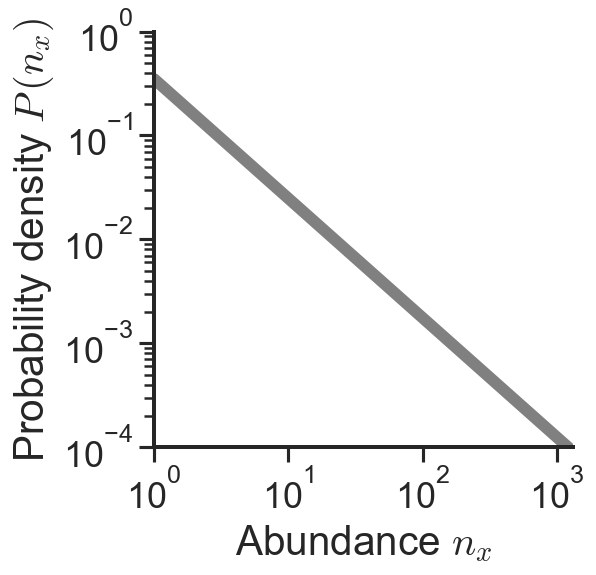

In [6]:
x = np.logspace(0., 3.7, 100)
y = 0.35*x**-1.15

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.set_xscale("log")
ax.set_yscale("log")
sns.lineplot(x=x, y=y, ax=ax, lw=7, color='grey')
ax.set(xlabel=r"Abundance $n_x$", ylabel=r"Probability density $P\,(n_x)$", title="", xlim=(1, 1300), ylim=(1e-4, 1),
       xticks=[1, 10, 100, 1000], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0])
ax.legend(title=None, frameon=False)
sns.despine(ax=ax)


saved_paths = save_figure(fig, "fig1_panelB", transparent=True)
saved_paths

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelC.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelC.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelC.svg')]

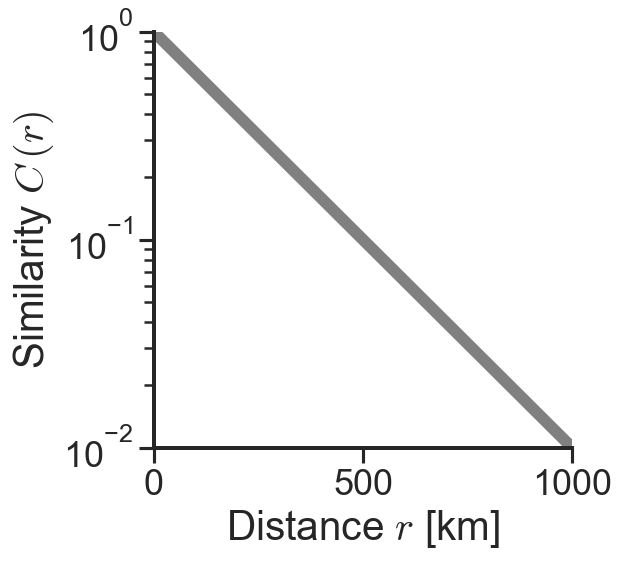

In [20]:
x = np.linspace(0., 1e3, 100)
y = np.exp(-x/217)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
# ax.set_xscale("log")
ax.set_yscale("log")
sns.lineplot(x=x, y=y, ax=ax, lw=7, color='grey')
ax.set(xlabel=r"Distance $r$ [km]", ylabel=r"Similarity $C\,(r)$", title="", xlim=(0, 1000), ylim=(1e-2, 1), yticks=[ 1e-2, 1e-1, 1e0])
ax.legend(title=None, frameon=False)
sns.despine(ax=ax)


saved_paths = save_figure(fig, "fig1_panelC", transparent=True)
saved_paths

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelD.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelD.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelD.svg')]

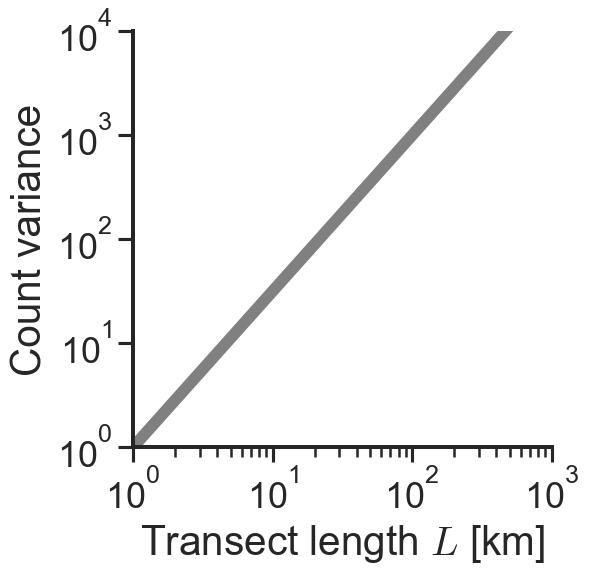

In [21]:
x = np.logspace(0., 3, 100)
y = x**1.5

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.set_xscale("log")
ax.set_yscale("log")
sns.lineplot(x=x, y=y, ax=ax, lw=7, color='grey')
ax.set(xlabel=r"Transect length $L$ [km]", ylabel = r"Count variance", title="", xlim=(1, 1000), ylim=(1, 1e4), yticks=[1, 1e1, 1e2, 1e3, 1e4])
ax.legend(title=None, frameon=False)
sns.despine(ax=ax)


saved_paths = save_figure(fig, "fig1_panelD", transparent=True)
saved_paths

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelF.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelF.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelF.svg')]

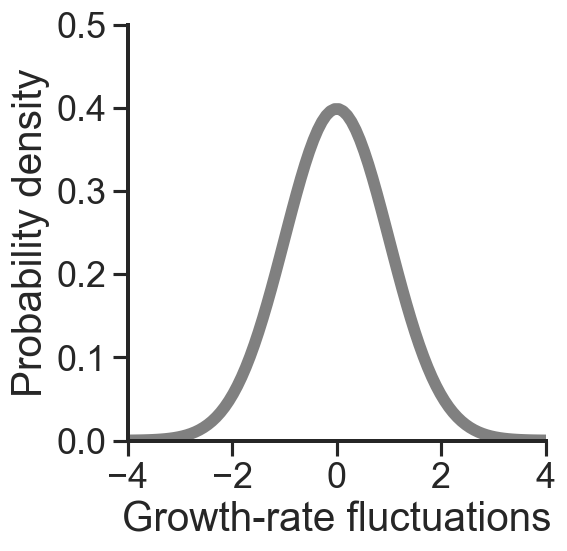

In [22]:
x = np.linspace(-4, 4, 100)
y = (1/(np.sqrt(2*np.pi)*1)) * np.exp(-0.5 * (x/1)**2)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
# ax.set_xscale("log")
# ax.set_yscale("log")
sns.lineplot(x=x, y=y, ax=ax, lw=7, color='grey')
ax.set(xlabel=r"Growth-rate fluctuations", ylabel=r"Probability density", title="", xlim=(-4, 4), ylim=(0, 0.5), xticks=[-4, -2, 0, 2, 4], yticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax.legend(title=None, frameon=False)
sns.despine(ax=ax)


saved_paths = save_figure(fig, "fig1_panelF", transparent=True)
saved_paths

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelF.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelF.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelF.svg')]

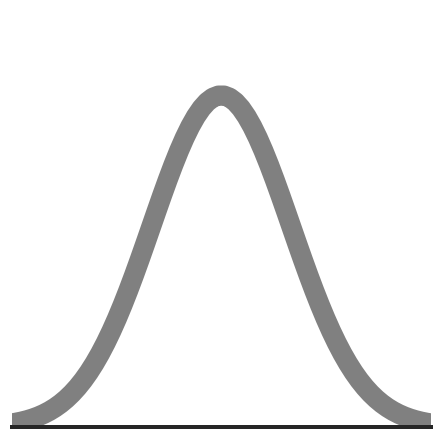

In [23]:
x = np.linspace(-4, 4, 100)
y = (1/(np.sqrt(2*np.pi)*1)) * np.exp(-0.5 * (x/1)**2)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
# ax.set_xscale("log")
# ax.set_yscale("log")
sns.lineplot(x=x, y=y, ax=ax, lw=12, color='grey')
ax.set(xlabel=r"", ylabel=r"", title="", xlim=(-3, 3), ylim=(0, 0.5), xticks=[], yticks=[])
ax.legend(title=None, frameon=False)
sns.despine(ax=ax)
# remove left spine
ax.spines['left'].set_visible(False)


saved_paths = save_figure(fig, "fig1_panelF", transparent=True)
saved_paths

[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelC.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelC.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig1_panelC.svg')]

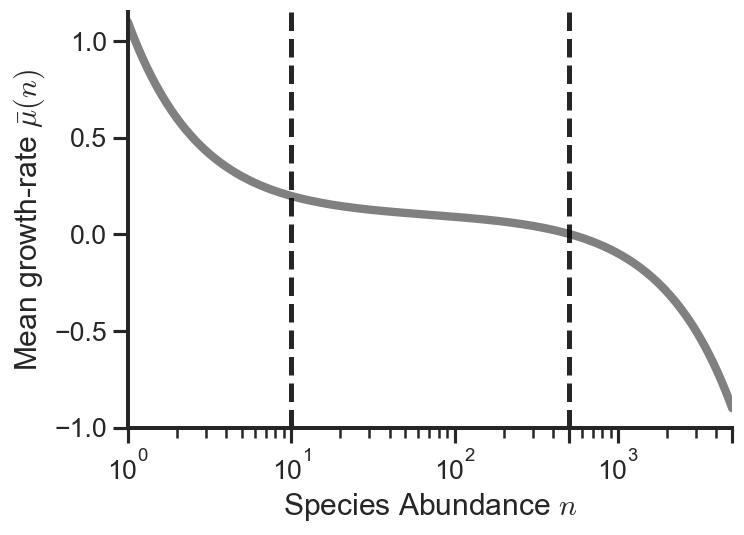

In [24]:
with mpl.rc_context({"pdf.fonttype": 3}):
    n_vals = np.logspace(0, np.log10(5000), 500)
    g_star_vals = 1 / n_vals + 0.1 - n_vals / 5000

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(n_vals, g_star_vals, lw=5, color="grey")
    for n_ref in (10, 500):
        ax.axvline(n_ref, color="black", lw=3, ls="--", alpha=0.85)
    ax.set_xscale("log")
    ax.set(
        xlabel=r"Species Abundance $n$",
        ylabel=r"Mean growth-rate $\bar{\mu}(n)$",
        title="",
        xlim=(1, 5000),
        ylim=(-1.0, 1.15),
        xticks=[1, 10, 100, 500, 1000, 5000],
        yticks=[-1.0, -0.5, 0.0, 0.5, 1.0],
    )
    style_figure2_axis(ax)
    sns.despine(ax=ax)

    saved_paths = save_figure(fig, "fig1_panelC", transparent=True)
saved_paths


In [10]:
SUPPORTED_TABLE_SUFFIXES = (".csv", ".tsv", ".txt", ".feather", ".parquet", ".xlsx", ".xls")
FIG_MC_DIR = DATA_DIR / "plot_MareChiara"
MARECHIARA_GROUP_COLORS = {
    "Diatoms": "#2F6F5E",
    "Dinoflagellates": COLORS["MareChiara"] if 'COLORS' in globals() else "#D55E00",
    "Coccolithophores": "#9DC9B4",
}
print("MareChiara group colors:")
for group, color in MARECHIARA_GROUP_COLORS.items():
    print(f"{group}: {color}")



MareChiara group colors:
Diatoms: #2F6F5E
Dinoflagellates: #63A088
Coccolithophores: #9DC9B4


Fig. 1D noise species log-log linear fits: log10(sigma_n_hat) = intercept + slope log10(n_hat)
Diatoms: slope=1.593, intercept=0.231, prefactor=1.7, R2=0.987, n=20
Dinoflagellates: slope=1.753, intercept=-0.519, prefactor=0.303, R2=0.966, n=10
Coccolithophores: slope=1.800, intercept=-0.576, prefactor=0.265, R2=0.983, n=10
Fig. 1E noise biomass log-log linear fits: log10(sigma_n) = intercept + slope log10(n)
Diatoms: slope=1.550, intercept=0.557, prefactor=3.61, R2=0.952, n=20
Dinoflagellates: slope=1.723, intercept=-0.586, prefactor=0.259, R2=0.980, n=10
Coccolithophores: slope=1.437, intercept=0.238, prefactor=1.73, R2=0.924, n=10


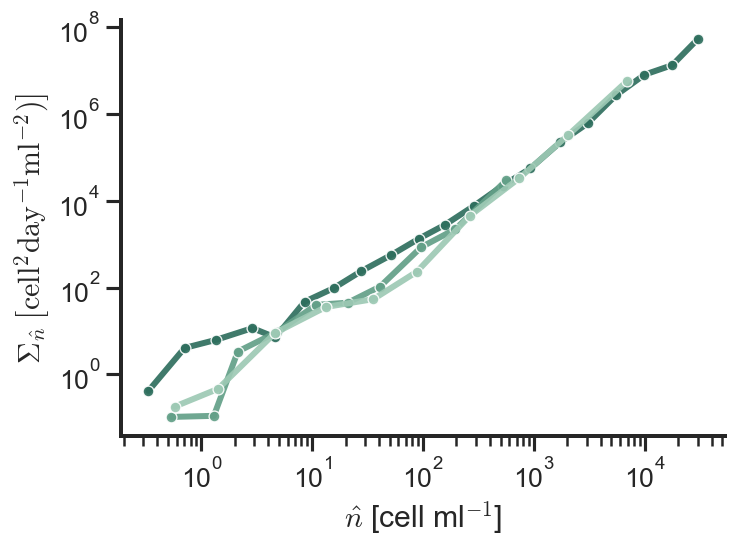

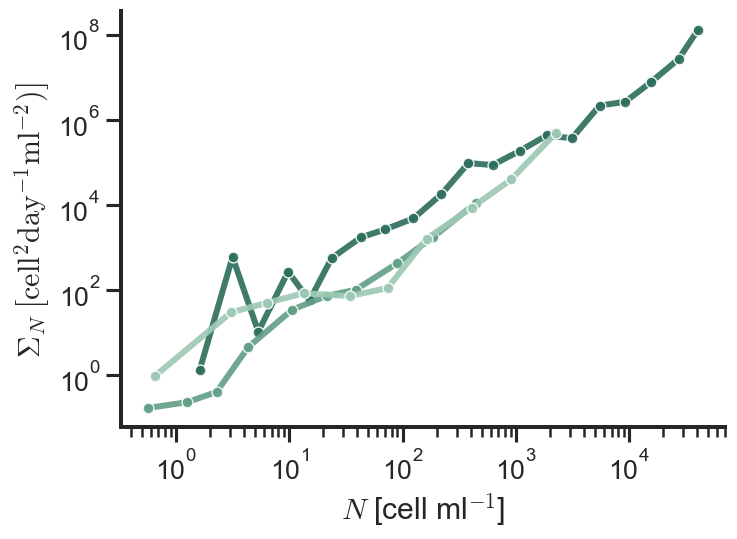

In [8]:
def find_data_file(stem, folder=DATA_DIR):
    for suffix in ("", *SUPPORTED_TABLE_SUFFIXES):
        path = folder / f"{stem}{suffix}"
        if path.exists():
            return path

    matches = sorted(
        path
        for path in folder.rglob(f"{stem}*")
        if path.is_file() and (path.suffix.lower() in SUPPORTED_TABLE_SUFFIXES or path.suffix == "")
    )
    if not matches:
        raise FileNotFoundError(f"Could not find {stem} in {folder}. Expected e.g. {folder / (stem + '.csv')}.")
    return matches[0]

def read_table(path):
    suffix = path.suffix.lower()
    if suffix == ".feather":
        return pd.read_feather(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix in (".xlsx", ".xls"):
        return pd.read_excel(path)
    if suffix in (".tsv", ".txt"):
        return pd.read_csv(path, sep=None, engine="python")
    return pd.read_csv(path)

def normalize_column_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")

def match_numeric_column(columns, candidates):
    normalized = {normalize_column_name(column): column for column in columns}
    for candidate in candidates:
        if candidate in normalized:
            return normalized[candidate]
    for candidate in candidates:
        if len(candidate) < 3:
            continue
        for normalized_name, column in normalized.items():
            if candidate in normalized_name:
                return column
    return None

def prepare_noise_panel(stem, x_candidates, y_candidates):
    path = find_data_file(stem)
    df = read_table(path)
    numeric = df.apply(pd.to_numeric, errors="coerce")
    numeric_columns = [column for column in numeric.columns if numeric[column].notna().sum() > 0]
    
    x_col = match_numeric_column(numeric_columns, x_candidates)
    y_col = match_numeric_column([column for column in numeric_columns if column != x_col], y_candidates)

    usable_columns = [column for column in numeric_columns if normalize_column_name(column) not in {"index", "id"}]
    if x_col is None and y_col is None:
        x_col, y_col = usable_columns[:2]
    elif x_col is None:
        x_col = next(column for column in usable_columns if column != y_col)
    elif y_col is None:
        y_col = next(column for column in usable_columns if column != x_col)

    data = df[[x_col, y_col]].copy()
    data[x_col] = numeric[x_col]
    data[y_col] = numeric[y_col]
    if "Group" in df.columns:
        data["Group"] = df["Group"]
    data = data.dropna(subset=[x_col, y_col]).sort_values(x_col)
    return data, x_col, y_col, path

def plot_noise_response(ax, data, x_col, y_col, group_colors, x_label, y_label):
    groups = data.groupby("Group", sort=False) if "Group" in data.columns else [(None, data)]
    fallback_color = COLORS["MareChiara"] if 'COLORS' in globals() else "#000000"
    for group, group_df in groups:
        group_df = group_df.sort_values(x_col)
        color = group_colors.get(group, fallback_color) if isinstance(group_colors, dict) else group_colors
        sns.scatterplot(data=group_df, x=x_col, y=y_col, ax=ax, color=color, s=24, alpha=0.24, edgecolor="none", rasterized=True)
        sns.lineplot(data=group_df, x=x_col, y=y_col, ax=ax, color=color, lw=3.6, marker="o", markersize=6.5, markeredgecolor="white", markeredgewidth=0.8, alpha=0.92, estimator=None)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)
    if 'style_figure2_axis' in globals():
        style_figure2_axis(ax)
    sns.despine(ax=ax)
    return ax

def print_loglog_fit(data, x_col, y_col, panel_name):
    groups = data.groupby("Group", sort=False) if "Group" in data.columns else [("all", data)]
    print(f"{panel_name} log-log linear fits: log10({y_col}) = intercept + slope log10({x_col})")
    for group, group_df in groups:
        fit_data = group_df.loc[(group_df[x_col] > 0) & (group_df[y_col] > 0), [x_col, y_col]].dropna()
        if len(fit_data) < 2:
            print(f"{group}: insufficient positive points for fit")
            continue
        log_x = np.log10(fit_data[x_col].to_numpy())
        log_y = np.log10(fit_data[y_col].to_numpy())
        slope, intercept = np.polyfit(log_x, log_y, 1)
        predicted = intercept + slope * log_x
        residual_ss = np.sum((log_y - predicted) ** 2)
        total_ss = np.sum((log_y - log_y.mean()) ** 2)
        r2 = 1 - residual_ss / total_ss if total_ss > 0 else np.nan
        prefactor = 10 ** intercept
        print(f"{group}: slope={slope:.3f}, intercept={intercept:.3f}, prefactor={prefactor:.3g}, R2={r2:.3f}, n={len(fit_data)}")

# Fig 1D: NOISE SPECIES (Sigma Species)
noise_species = pd.read_csv(FIG_MC_DIR / "Sigma_species_agg.csv")
noise_species.rename(columns={'x': 'n_hat', 'y': 'sigma_n_hat', 'Group_Name': 'Group'}, inplace=True)
noise_species_x = 'n_hat'
noise_species_y = 'sigma_n_hat'

fig1, ax1 = plt.subplots(figsize=(6.5, 4.5))
plot_noise_response(
    ax1, noise_species, noise_species_x, noise_species_y, MARECHIARA_GROUP_COLORS, 
    r"$\hat{n}$ [cell ml$^{-1}$]", 
    r"$\Sigma_{\hat{n}} \; \left[ \mathrm{cell}^{2} \mathrm{day}^{-1} \mathrm{ml}^{-2}) \right]$"
)
print_loglog_fit(noise_species, noise_species_x, noise_species_y, "Fig. 1D noise species")

if 'save_figure' in globals():
    saved_paths = save_figure(fig1, "fig1_panelD_noise_species", transparent=True)

# Fig 1E: NOISE BIOMASS (Sigma Total)
noise_biomass = pd.read_csv(FIG_MC_DIR / "Sigma_total_abundance_agg.csv")
noise_biomass.rename(columns={'x': 'n', 'y': 'sigma_n', 'Group_Name': 'Group'}, inplace=True)
noise_biomass_x = 'n'
noise_biomass_y = 'sigma_n'

fig2, ax2 = plt.subplots(figsize=(6.5, 4.5))
plot_noise_response(
    ax2, noise_biomass, noise_biomass_x, noise_biomass_y, MARECHIARA_GROUP_COLORS, 
    r"$N$ [cell ml$^{-1}$]", 
    r"$\Sigma_N \;  \left[ \mathrm{cell}^{2} \mathrm{day}^{-1} \mathrm{ml}^{-2}) \right]$"
)
print_loglog_fit(noise_biomass, noise_biomass_x, noise_biomass_y, "Fig. 1E noise biomass")

if 'save_figure' in globals():
    saved_paths = save_figure(fig2, "fig1_panelE_noise_biomass", transparent=True)
    
plt.show()

# Figure 2

In [ ]:
# Figure 2: sampling map.
# Uses GRUMP and Tara coordinates from data files, plus the LTER-MC point.

os.environ.setdefault("ARROW_USER_SIMD_LEVEL", "NONE")
warnings.filterwarnings("ignore", message="invalid value encountered in create_collection", category=RuntimeWarning)
logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False


FONT_SIZE = 12

COLORS = {
    "GRUMP": "#56203D",
    "Tara": "#386FA4",
    "MareChiara": "#63A088",
}

COLORS_LIGHT = {
    "GRUMP": "#AEA1A9",
    "Tara": "#0072B2",
    "MareChiara": "#009E73",
}
MARKERS = {"GRUMP": "v", "Tara": "s", "MareChiara": "o"}
MARKER_SIZE = {"GRUMP": 50, "Tara": 22, "MareChiara": 130}

MAP_OCEAN = "#F7FBFD"
MAP_LAND = "#D8D4CC"
MAP_COAST = "#7A7A7A"
MAP_GRID = "#B9CBD2"

FIG2_TITLE_SIZE = 18
FIG2_LABEL_SIZE = 18
FIG2_TICK_SIZE = 16
FIG2_LEGEND_SIZE = 14



In [28]:
def build_sampling_coordinates():
    grump = (
        pd.read_csv(DATA_DIR / "stations_GRUMP_coord_counts.csv")
        .rename(columns={"lon": "longitude", "lat": "latitude"})
        .assign(dataset="GRUMP")
    )
    grump = grump[["dataset", "station", "longitude", "latitude"]].drop_duplicates()

    tara = (
        pd.read_feather(DATA_DIR / "Tara_patch.feather", columns=["lon", "lat"])
        .rename(columns={"lon": "longitude", "lat": "latitude"})
        .assign(dataset="Tara", station="Tara")
    )
    tara = tara[["dataset", "station", "longitude", "latitude"]].dropna().drop_duplicates()
    for bad_lon, bad_lat in BAD_TARA_COORDS:
        bad_point = np.isclose(tara["longitude"], bad_lon, atol=BAD_TARA_ATOL) & np.isclose(tara["latitude"], bad_lat, atol=BAD_TARA_ATOL)
        tara = tara.loc[~bad_point].copy()

    marechiara = pd.DataFrame([MARECHIARA_COORDS])

    coords = pd.concat([grump, tara, marechiara], ignore_index=True)
    coords["longitude"] = pd.to_numeric(coords["longitude"], errors="coerce")
    coords["latitude"] = pd.to_numeric(coords["latitude"], errors="coerce")
    return coords.dropna(subset=["longitude", "latitude"])


def plot_sampling_map(ax, coords):
    ax.set_facecolor(MAP_OCEAN)

    if HAS_CARTOPY:
        data_crs = ccrs.PlateCarree()
        ax.set_extent([-180, 180, -75, 75], crs=data_crs)
        try:
            ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor=MAP_LAND, edgecolor="none", zorder=3)
            ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.5, edgecolor=MAP_COAST, zorder=2)
        except Exception:
            pass
        ax.set_xticks(np.arange(-120, 121, 60), crs=data_crs)
        ax.set_yticks(np.arange(-60, 61, 20), crs=data_crs)
        ax.xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f", degree_symbol="°"))
        ax.yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f", degree_symbol="°"))
        ax.tick_params(axis="x", labeltop=True, labelbottom=False, labelsize=11, colors=MAP_COAST, length=0, pad=4)
        ax.tick_params(axis="y", labelleft=True, labelright=False, labelsize=11, colors=MAP_COAST, length=0, pad=4)
        ax.grid(color=MAP_GRID, linewidth=0.25, alpha=0.55, zorder=1)
        for spine in ax.spines.values():
            spine.set_edgecolor(MAP_COAST)
            spine.set_linewidth(0.8)

        for name in ["GRUMP", "Tara", "MareChiara"]:
            df = coords.loc[coords["dataset"] == name]
            if df.empty:
                continue
            ax.scatter(
                df["longitude"],
                df["latitude"],
                transform=data_crs,
                s=MARKER_SIZE[name],
                marker=MARKERS[name],
                color=COLORS[name],
                edgecolor="black" if name == "MareChiara" else "none",
                linewidth=1.0 if name == "MareChiara" else 0,
                alpha=0.90,
                label=name,
                zorder=6,
            )
        # ax.text(27, 20, "LTER-MC", transform=data_crs, color=COLORS["MareChiara"], fontsize=FONT_SIZE, fontweight="bold")
        # ax.text(-138, -58, "GRUMP", transform=data_crs, color=COLORS["GRUMP"], fontsize=FONT_SIZE, fontweight="bold")
        # ax.text(0, -58, "TARA", transform=data_crs, color=COLORS["Tara"], fontsize=FONT_SIZE, fontweight="bold")
        ax.set_title("")
    else:
        ax.set_xlim(-180, 180)
        ax.set_ylim(-80, 85)
        ax.set_xlabel("Longitude [degrees]")
        ax.set_ylabel("Latitude [degrees]")
        ax.set_xticks(np.arange(-180, 181, 60))
        ax.set_yticks(np.arange(-60, 91, 30))
        # ax.grid(color=MAP_GRID, linewidth=0.35, alpha=0.65)
        for name in ["GRUMP", "Tara", "MareChiara"]:
            df = coords.loc[coords["dataset"] == name]
            if df.empty:
                continue
            ax.scatter(
                df["longitude"],
                df["latitude"],
                s=MARKER_SIZE[name],
                marker=MARKERS[name],
                color=COLORS[name],
                edgecolor="black" if name == "MareChiara" else "none",
                linewidth=1.0 if name == "MareChiara" else 0,
                alpha=0.90,
                label=name,
            )
        # ax.text(22, 43, "LTER-MC", color=COLORS["MareChiara"], fontsize=FONT_SIZE, fontweight="bold")
        # ax.text(-150, -47, "GRUMP", color=COLORS["GRUMP"], fontsize=FONT_SIZE, fontweight="bold")
        # ax.text(15, -47, "TARA", color=COLORS["Tara"], fontsize=FONT_SIZE, fontweight="bold")
        sns.despine(ax=ax)

    return ax

[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelA_map.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelA_map.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelA_map.svg')]

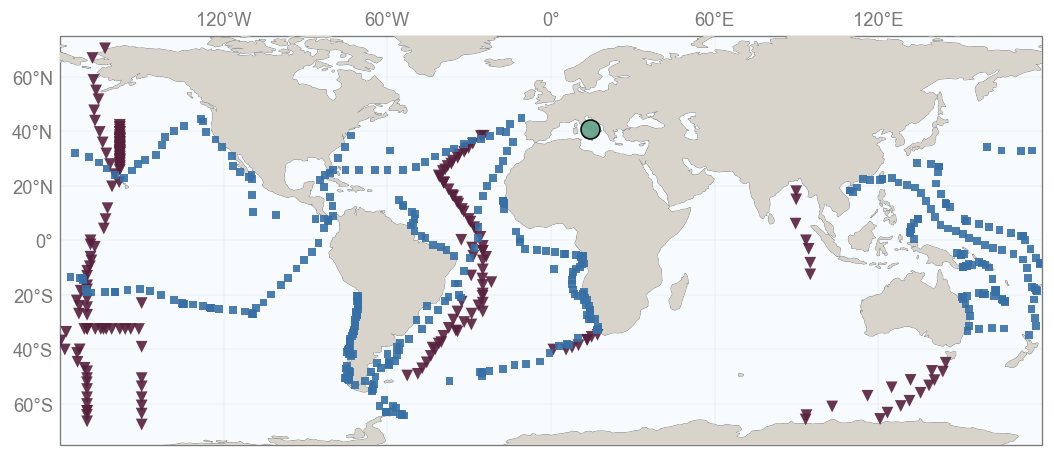

In [29]:
coords = build_sampling_coordinates()

subplot_kw = {"projection": ccrs.PlateCarree()} if HAS_CARTOPY else {}
fig, ax = plt.subplots(figsize=(8.8, 3.7), subplot_kw=subplot_kw, constrained_layout=True)
plot_sampling_map(ax, coords)

saved_paths = save_figure(fig, "fig2_panelA_map", transparent=False)
saved_paths

[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelB_marechiara_timeseries.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelB_marechiara_timeseries.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelB_marechiara_timeseries.svg')]

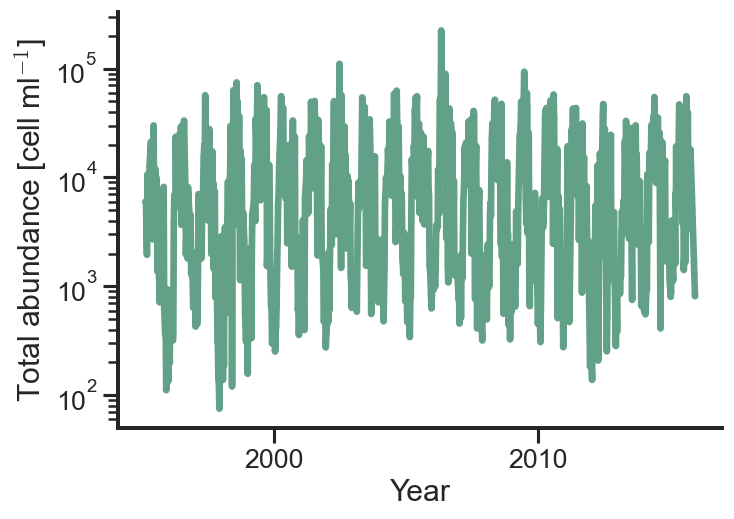

In [ ]:
marechiara_series = pd.read_csv(DATA_DIR / "samples_MareChiara_counts_date.csv")
marechiara_series["counts"] = pd.to_numeric(marechiara_series["counts"], errors="coerce")
marechiara_series["date"] = pd.to_datetime(marechiara_series["date"], errors="coerce")
marechiara_series = marechiara_series.dropna(subset=["counts", "date"]).sort_values("date")
marechiara_series = marechiara_series.loc[marechiara_series["date"] >= "1994-05-05"].copy()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.lineplot(data=marechiara_series, x="date", y="counts", ax=ax, color=COLORS["MareChiara"], lw=4.0, estimator=None)
sns.scatterplot(data=marechiara_series, x="date", y="counts", ax=ax, color=COLORS["MareChiara"], s=18, alpha=0.32, edgecolor="none")
ax.set_yscale("log")
ax.set(xlabel="Year", ylabel="Total abundance [cell ml$^{-1}$]", xticks=pd.to_datetime(["1995-01-01", "2000-01-01", "2005-01-01", "2010-01-01", "2015-01-01"]), xticklabels=["1995", "2000", "2005", "2010", "2015"])
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
style_figure2_axis(ax)
sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig2_panelB_marechiara_timeseries", transparent=True)
saved_paths

[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelC_grump_latitude.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelC_grump_latitude.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelC_grump_latitude.svg')]

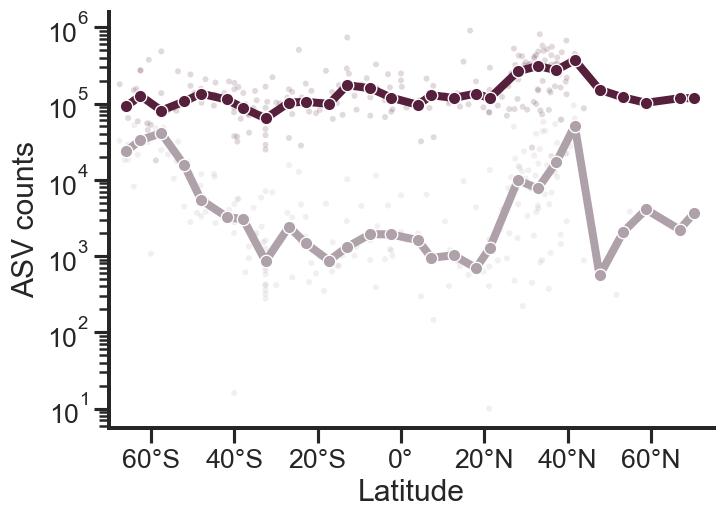

In [31]:
grump_counts = pd.read_csv(DATA_DIR / "stations_GRUMP_coord_counts.csv")
grump_counts = grump_counts.rename(columns={"lat": "latitude", "lon": "longitude"})
grump_counts["counts"] = pd.to_numeric(grump_counts["counts"], errors="coerce")
grump_counts["latitude"] = pd.to_numeric(grump_counts["latitude"], errors="coerce")
grump_counts["Group"] = grump_counts["type"].map({"16S": "16S", "18S": "18S"})
grump_counts = grump_counts.dropna(subset=["latitude", "counts", "Group"])
grump_counts = grump_counts.loc[grump_counts["counts"] > 0].copy()

lat_bins = np.arange(-70, 80, 5)
trend_frames = []
for group in ["16S", "18S"]:
    group_df = grump_counts.loc[grump_counts["Group"] == group]
    tmp = group_df.copy()
    tmp["Latitude bin"] = pd.cut(tmp["latitude"], bins=lat_bins, include_lowest=True)
    trend = (
        tmp.groupby("Latitude bin", observed=True)
        .agg(latitude=("latitude", "median"), counts=("counts", "median"), n=("counts", "size"))
        .reset_index(drop=True)
        .dropna(subset=["latitude", "counts"])
    )
    trend["Group"] = group
    trend_frames.append(trend)

latitude_trend = pd.concat(trend_frames, ignore_index=True)
group_colors = {"16S": COLORS["GRUMP"], "18S": COLORS_LIGHT["GRUMP"]}


def format_latitude_tick(x, _pos):
    if np.isclose(x, 0):
        return "0°"
    hemisphere = "N" if x > 0 else "S"
    return f"{abs(int(x))}°{hemisphere}"

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for group in ["16S", "18S"]:
    raw = grump_counts.loc[grump_counts["Group"] == group]
    ax.scatter(
        raw["latitude"],
        raw["counts"],
        s=13,
        color=group_colors[group],
        alpha=0.17,
        edgecolors="none",
        rasterized=True,
        zorder=1,
    )

for group in ["16S", "18S"]:
    df = latitude_trend.loc[latitude_trend["Group"] == group].sort_values("latitude")
    if df.empty:
        continue
    ax.plot(
        df["latitude"],
        df["counts"],
        lw=4.8,
        marker="o",
        ms=7.5,
        color=group_colors[group],
        markeredgecolor="white",
        markeredgewidth=0.8,
        label=f"{group} median",
        solid_capstyle="butt",
        zorder=4,
    )

ax.set_yscale("log")
ax.set(xlabel="Latitude", ylabel="ASV counts", xlim=(-70, 75))
ax.set_xticks(np.arange(-60, 61, 20))
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(format_latitude_tick))
style_figure2_axis(ax)
# ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=FIG2_LEGEND_SIZE, handlelength=1.8)
sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig2_panelC_grump_latitude", transparent=True)
saved_paths

[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelD_tara_chlorophyll.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelD_tara_chlorophyll.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig2_panelD_tara_chlorophyll.svg')]

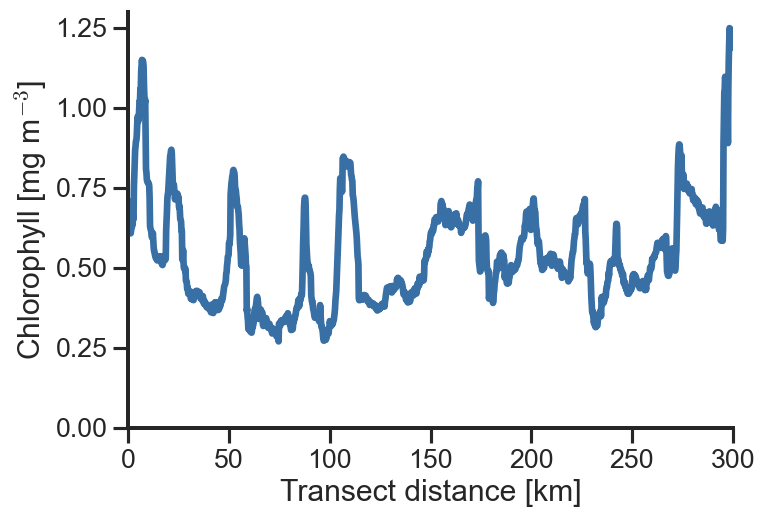

In [32]:
tara_chlorophyll = pd.read_csv(DATA_DIR / "Transetto_Chl_Dist.csv")
tara_chlorophyll["distance_km"] = pd.to_numeric(tara_chlorophyll["Asse_X_Distanza_km"], errors="coerce")
tara_chlorophyll["chlorophyll"] = pd.to_numeric(tara_chlorophyll["Asse_Y_Chl_lineheight"], errors="coerce")
tara_chlorophyll = tara_chlorophyll.dropna(subset=["distance_km", "chlorophyll"]).sort_values("distance_km")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.lineplot(data=tara_chlorophyll, x="distance_km", y="chlorophyll", ax=ax, color=COLORS["Tara"], lw=4.0, estimator=None)
ax.set(xlabel="Transect distance [km]", ylabel=r"Chlorophyll [mg m$^{-3}$]", xlim=(0, 300), ylim=(0., 1.3), yticks=[0.0, 0.25, 0.5, 0.75, 1.0, 1.25])
style_figure2_axis(ax)
sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig2_panelD_tara_chlorophyll", transparent=True)
saved_paths

## Figure 3

In [7]:
import scipy as sp

In [8]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

FIG3_DIR = DATA_DIR / "plot_Distributions"
FIG3_PARAMS = pd.read_csv(FIG3_DIR / "parametres_summary.csv")
FIG3_MODEL_LINESTYLES = {"GIG": "-", "LNM": "--"}
FIG3_MODEL_LABELS = {"GIG": "GIG", "LNM": "LGN"}
FIG3_PANEL_ORDER = {
    "a": ["16S", "18S"],
    "b": ["Diatoms", "Dinoflagellates", "Coccolithophores"],
    "d": ["Chl Data"],
    "e": ["Diatoms", "Dinoflagellates", "Coccolithophores"],
}


def fig3_log_sad_gig(n, b, c, mu):
    n = np.maximum(np.asarray(n, dtype=float), 1e-12)
    kv_val = sp.special.kv(1 - 2 * mu, 2 * np.sqrt(b / c))
    if kv_val <= 0 or not np.isfinite(kv_val):
        return -np.inf * np.ones_like(n)
    return (0.5 - mu) * np.log(b * c) - b / n - n / c - (2.0 - 2.0 * mu) * np.log(n) - np.log(2) - np.log(kv_val)


def fig3_log_lognorm(n, mu, sigma):
    n = np.maximum(np.asarray(n, dtype=float), 1e-12)
    return -np.log(n * sigma * np.sqrt(2 * np.pi)) - ((np.log(n) - mu) ** 2) / (2 * sigma**2)


def fig3_pdf(n, row):
    model = row["Model_Type"]
    if model == "GIG":
        log_pdf = fig3_log_sad_gig(n, row["Param_1 (b)"], row["Param_2 (c)"], row["Param_3 (mu)"])
    elif model == "LNM":
        log_pdf = fig3_log_lognorm(n, row["Param_1 (mu)"], row["Param_2 (sigma)"])
    else:
        raise ValueError(f"Unknown Figure 3 model: {model}")
    return np.exp(log_pdf)


def fig3_panel_rows(panel):
    rows = FIG3_PARAMS.loc[FIG3_PARAMS["Subplot"].astype(str) == panel].copy()
    order = FIG3_PANEL_ORDER.get(panel, rows["Curve_Label"].tolist())
    rows["_order"] = rows["Curve_Label"].map({label: i for i, label in enumerate(order)})
    return rows.sort_values("_order")


def fig3_scatter_path(row):
    label = str(row["Curve_Label"]).replace(" ", "_")
    model = row["Model_Type"]
    return FIG3_DIR / f"panel_{row['Subplot']}_{label}_{model}_scatter.csv"


def fig3_style(row):
    panel = row["Subplot"]
    label = row["Curve_Label"]
    if panel == "a":
        return {
            "color": COLORS["GRUMP"] if label == "16S" else COLORS_LIGHT["GRUMP"],
            "marker": MARKERS["GRUMP"],
        }
    if panel in {"b", "e"}:
        return {"color": MARECHIARA_GROUP_COLORS[label], "marker": MARKERS["MareChiara"]}
    if panel == "d":
        return {"color": COLORS["Tara"], "marker": MARKERS["Tara"]}
    raise ValueError(f"Unknown Figure 3 panel: {panel}")


def style_fig3_log_axes(ax, panel):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1.0,), numticks=7))
    ax.xaxis.set_minor_locator(mpl.ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
    ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    if panel == "d":
        ax.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0), numticks=5))
    ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1.0,), numticks=7))
    ax.yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
    ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    return ax


def plot_fig3_distribution_panel(ax, panel, xlabel, ylabel=r"Frequency $P(n)$"):
    for _, row in fig3_panel_rows(panel).iterrows():
        data = pd.read_csv(fig3_scatter_path(row))
        data = data.apply(pd.to_numeric, errors="coerce").dropna(subset=["X_hist", "Y_hist"])
        data = data.loc[(data["X_hist"] > 0) & (data["Y_hist"] > 0)].sort_values("X_hist")
        style = fig3_style(row)
        model = row["Model_Type"]

        x_fit = np.logspace(np.log10(data["X_hist"].min()), np.log10(data["X_hist"].max()), 500)
        y_fit = fig3_pdf(x_fit, row)
        ax.plot(
            x_fit,
            y_fit,
            color=style["color"],
            lw=3.4,
            ls=FIG3_MODEL_LINESTYLES[model],
            zorder=2,
        )
        ax.scatter(
            data["X_hist"],
            data["Y_hist"],
            s=85,
            marker=style["marker"],
            color=style["color"],
            alpha=1.0,
            edgecolors="black",
            linewidths=0.85,
            zorder=5,
        )

    style_fig3_log_axes(ax, panel)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.margins(x=0.03, y=0.08)
    if panel == "d":
        ax.set_xlim(left=2e-1)
        ax.set_xticks([2e-1, 5e-1, 1])
        ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: r"$2\times10^{-1}$" if np.isclose(x, 2e-1) else (r"$5\times10^{-1}$" if np.isclose(x, 5e-1) else (r"$10^0$" if np.isclose(x, 1) else ""))))
    style_figure2_axis(ax)
    sns.despine(ax=ax)
    return ax


def add_fig3_grump_inset(ax):
    inset = ax.inset_axes([0.095, 0.13, 0.481, 0.454])
    inset.set_facecolor("none")
    inset.patch.set_alpha(0)
    inset_colors = {"16S": COLORS["GRUMP"], "18S": COLORS_LIGHT["GRUMP"]}
    inset_data = []
    for group in ["16S", "18S"]:
        data = pd.read_csv(FIG3_DIR / f"panel_c_spatial_{group}.csv")
        data = data.apply(pd.to_numeric, errors="coerce").dropna(subset=["Lambda", "Delta_BIC"])
        inset_data.append(data.assign(Group=group))
        inset.scatter(
            data["Lambda"],
            data["Delta_BIC"],
            s=12,
            marker="o",
            color=inset_colors[group],
            alpha=0.6,
            edgecolors="none",
            linewidths=0,
            rasterized=True,
            zorder=5,
        )
    inset.axhspan(-5, 5, color="0.85", alpha=0.45, zorder=0)
    inset.axhline(0, color="black", lw=1.0, alpha=1.0, zorder=2)
    inset.axvline(1.5, color="black", lw=1.0, ls="--", alpha=1.0, zorder=2)
    binned = pd.concat(inset_data, ignore_index=True)
    for group in ["16S", "18S"]:
        group_binned = binned.loc[binned["Group"] == group].copy()
        group_binned["Lambda_bin"] = pd.cut(group_binned["Lambda"], bins=np.linspace(0.8, 2.9, 9), include_lowest=True)
        binned_trend = (
            group_binned.groupby("Lambda_bin", observed=True)
            .agg(Lambda=("Lambda", "median"), Delta_BIC=("Delta_BIC", "median"), n=("Delta_BIC", "size"))
            .query("n >= 4")
        )
        inset.plot(
            binned_trend["Lambda"],
            binned_trend["Delta_BIC"],
            color=inset_colors[group],
            lw=2.0,
            marker=MARKERS["GRUMP"],
            ms=7.9,
            mfc=inset_colors[group],
            mec="k",
            mew=0.75,
            zorder=7,
        )
    inset.set_yscale("symlog", linthresh=10)
    inset.set_xlim(0.5, 3.0)
    inset.set_ylim(-160, 90)
    inset.set_xticks([1, 1.5, 2, 2.5, 3])
    inset.set_yticks([-100, -10, -5, 0, 5, 10, 100])
    inset.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
    inset.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
    inset.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    inset.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    inset.set_xlabel(r"$\lambda$", fontsize=11, labelpad=0)
    inset.set_ylabel(r"$\Delta_{\mathrm{BIC}}$", fontsize=11, labelpad=-3)
    inset.tick_params(axis="both", labelsize=9, width=1.2, length=3)
    sns.despine(ax=inset)
    return inset


{'A': [WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelA_grump_sad.png'),
  WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelA_grump_sad.pdf'),
  WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelA_grump_sad.svg')],
 'B': [WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelB_lter_mc_sad.png'),
  WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelB_lter_mc_sad.pdf'),
  WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelB_lter_mc_sad.svg')],
 'D': [WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelD_tara_chlorophyll_distribution.png'),
  WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelD_tara_chlorophyll_distribution.pdf'),
  WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelD_tara_chlorophyll_distribution.svg')],
 'E': [WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig3_panelE_lter_mc_sad.png'),
  WindowsPath('f:/D

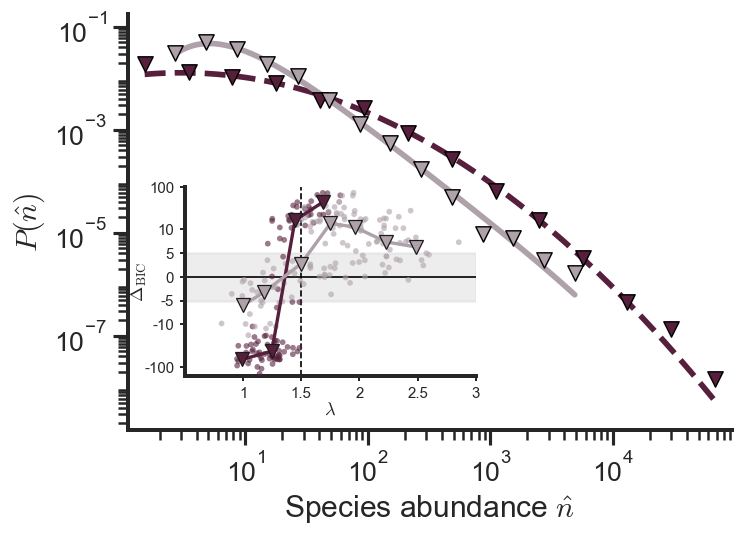

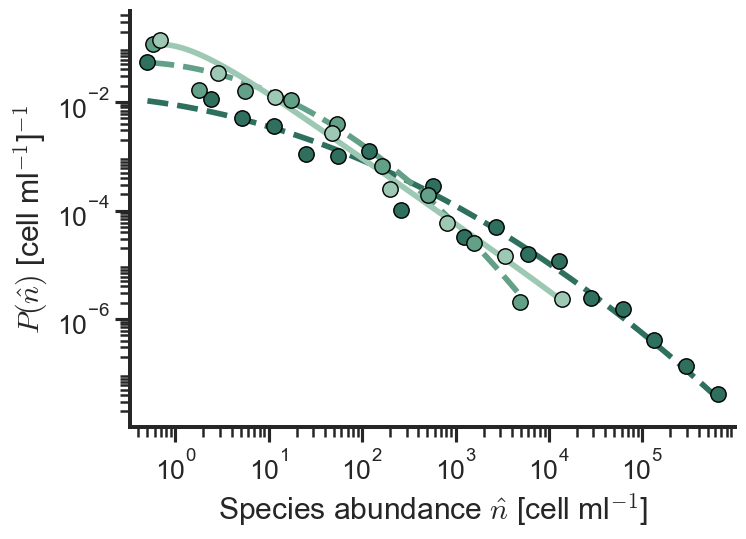

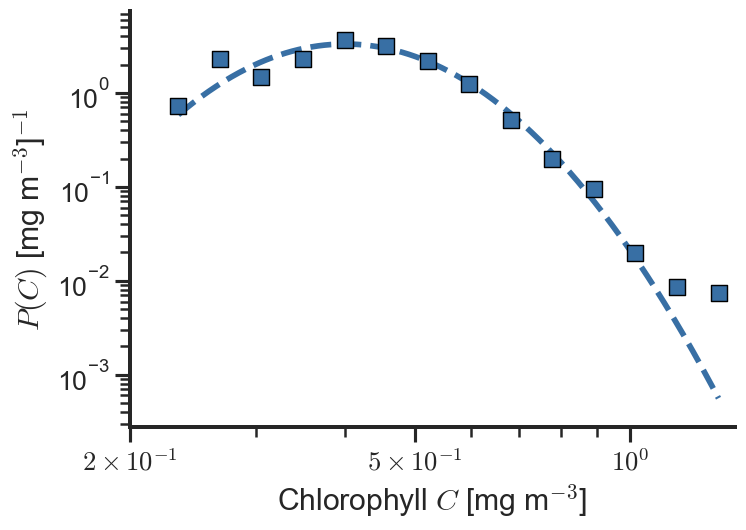

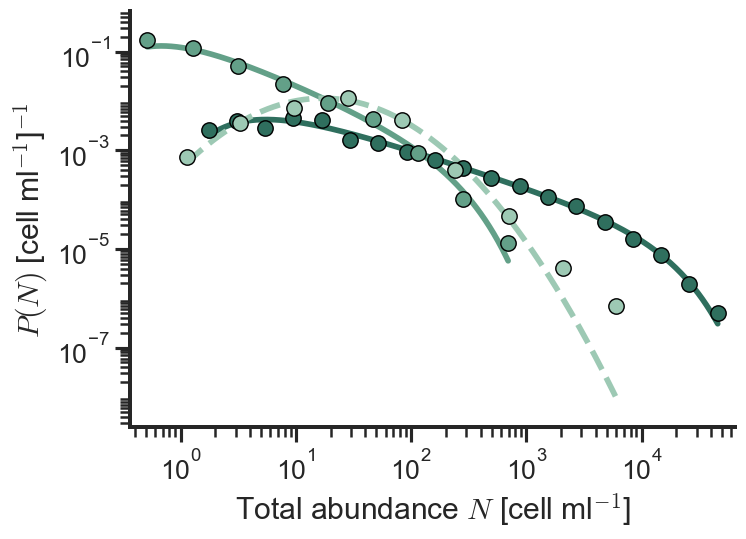

In [11]:
fig3_saved_paths = {}

with mpl.rc_context({"pdf.fonttype": 3}):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    plot_fig3_distribution_panel(ax, "a", r"Species abundance $\hat{n}$", ylabel=r"$P(\hat{n})$")
    add_fig3_grump_inset(ax)
    fig3_saved_paths["A"] = save_figure(fig, "fig3_panelA_grump_sad", transparent=True)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    plot_fig3_distribution_panel(ax, "b", r"Species abundance $\hat{n}$ [cell ml$^{-1}$]", ylabel=r"$P(\hat{n})$ [cell ml$^{-1}$]$^{-1}$")
    fig3_saved_paths["B"] = save_figure(fig, "fig3_panelB_lter_mc_sad", transparent=True)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    plot_fig3_distribution_panel(ax, "d", r"Chlorophyll $C$ [mg m$^{-3}$]", ylabel=r"$P(C)$ [mg m$^{-3}$]$^{-1}$")
    fig3_saved_paths["D"] = save_figure(fig, "fig3_panelD_tara_chlorophyll_distribution", transparent=True)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    plot_fig3_distribution_panel(ax, "e", r"Total abundance $N$ [cell ml$^{-1}$]", ylabel=r"$P(N)$ [cell ml$^{-1}$]$^{-1}$")
    fig3_saved_paths["E"] = save_figure(fig, "fig3_panelE_lter_mc_sad", transparent=True)

fig3_saved_paths


## Figure 4

In [54]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

FIG4_DIR = DATA_DIR / "plot_spatial"
FIG4_PARAMS = pd.read_csv(FIG4_DIR / "parameters_summary.csv").set_index("Panel")
FIG4_FIGSIZE = (6.5, 4.5)
FIG4_INSET_SIZE = {"width": "36%", "height": "33%"}


def fig4_read_scatter(name):
    data = pd.read_csv(FIG4_DIR / name)
    data = data.apply(pd.to_numeric, errors="coerce").dropna(subset=["X_hist", "Y_hist"])
    return data.sort_values("X_hist")


def fig4_psi(x):
    x = np.asarray(x, dtype=float)
    with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
        result = 1 - np.exp(-x) * np.sinh(x) / x
    return np.where(np.isfinite(result), result, np.nan)


def fig4_taylor_law_curve(x, gamma_km, amplitude, scale):
    x = np.asarray(x, dtype=float)
    z = x / (2 * gamma_km)
    return 2 * gamma_km * x * amplitude / scale /scale * fig4_psi(z)


def fig4_patch_model(x, gamma_km, amplitude):
    x = np.asarray(x, dtype=float)
    return amplitude * (1 - (2 * gamma_km) * fig4_psi(x / (2 * gamma_km)) / x)


def fig4_exponential_curve(x, gamma_km, amplitude=1.0):
    x = np.asarray(x, dtype=float)
    return amplitude * np.exp(-x / gamma_km)


def fig4_power_law_fit(data):
    data = data.loc[(data["X_hist"] > 0) & (data["Y_hist"] > 0)]
    slope, intercept = np.polyfit(np.log10(data["X_hist"]), np.log10(data["Y_hist"]), 1)
    return slope, 10 ** intercept


def fig4_linear_fit(data):
    slope, intercept = np.polyfit(data["X_hist"], data["Y_hist"], 1)
    return slope, intercept


def style_fig4_axis(ax, xscale=None, yscale=None):
    if xscale:
        ax.set_xscale(xscale)
    if yscale:
        ax.set_yscale(yscale)
    style_figure2_axis(ax)
    sns.despine(ax=ax)
    return ax


def style_fig4_inset(ax, xscale=None, yscale=None):
    if xscale:
        ax.set_xscale(xscale)
    if yscale:
        ax.set_yscale(yscale)
    ax.set_facecolor("none")
    ax.patch.set_alpha(0)
    ax.tick_params(axis="both", labelsize=8.8, width=1.15, length=3, pad=1)
    ax.xaxis.label.set_size(9.5)
    ax.yaxis.label.set_size(9.5)
    ax.xaxis.labelpad = 1
    ax.yaxis.labelpad = 0
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.35)
    sns.despine(ax=ax)
    return ax


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelA_species_spatial_taylor_law.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelA_species_spatial_taylor_law.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelA_species_spatial_taylor_law.svg')]

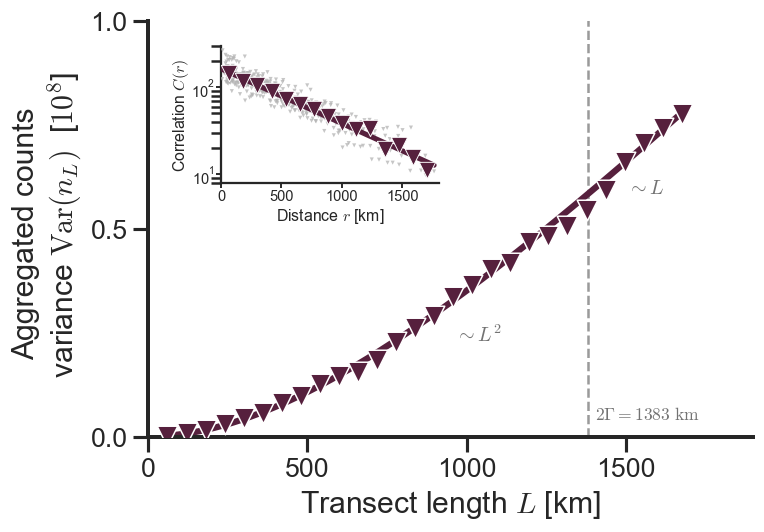

In [69]:
# Figure 4A: species spatial Taylor law.

def plot_fig4_panel_a(ax):
    data = fig4_read_scatter("panel_a_Species_Correlation_TL_scatter.csv")
    params = FIG4_PARAMS.loc["a_main"]
    gamma_km = params["Gamma_km"]
    amplitude = params["Other_Param"]
    scale = params["Scale"]
    x_fit = np.linspace(data["X_hist"].min(), data["X_hist"].max(), 500)
    y_fit = fig4_taylor_law_curve(x_fit, gamma_km, amplitude, scale)
    variance_scale = 1e8

    color = COLORS["GRUMP"]
    ax.plot(x_fit, y_fit / variance_scale, color=color, lw=3.8, zorder=2)
    guide_color = "0.45"
    crossover_km = 2 * gamma_km
    ax.vlines(crossover_km, ymin=0, ymax=1.4, color=guide_color, lw=1.5, ls="--", alpha=0.72, zorder=1)
    ax.text(0.75 * crossover_km, 0.22, r"$\sim L^2$", color=guide_color, fontsize=12.0, ha="center", va="bottom", zorder=6)
    ax.text(1.13 * crossover_km, 0.575, r"$\sim L$", color=guide_color, fontsize=12.0, ha="center", va="bottom", zorder=6)
    ax.text(crossover_km + 22, 0.035, rf"$2\Gamma={crossover_km:.0f}\ \mathrm{{km}}$", color=guide_color, fontsize=10.5, ha="left", va="bottom", zorder=6)
    ax.scatter(data["X_hist"], data["Y_hist"] / variance_scale, s=152, marker=MARKERS["GRUMP"], color=color, alpha=1.0, edgecolors="white", linewidths=0.9, zorder=5)
    ax.set(xlabel=r"Transect length $L$ [km]", ylabel="Aggregated counts \n" + r" variance $\mathrm{Var}(n_L)$  [$10^8$]", xlim=(0, 1900), ylim=(0.0, 1.), yticks=[0, 0.5, 1.0])
    style_fig4_axis(ax)

    inset = ax.inset_axes([0.12, 0.61, 0.36, 0.33])

    inset_data = fig4_read_scatter("panel_a_inset_Species_Correlation_Linear_scatter.csv")
    inset_raw = fig4_read_scatter("panel_a_inset_Species_Correlation_Linear_curve.csv")
    inset_gamma = FIG4_PARAMS.loc["a_inset", "Gamma_km"]
    inset_amp = np.exp(np.mean(np.log(inset_data["Y_hist"]) + inset_data["X_hist"] / inset_gamma))
    inset_x = np.linspace(inset_raw["X_hist"].min(), inset_raw["X_hist"].max(), 300)
    inset.plot(inset_x, fig4_exponential_curve(inset_x, inset_gamma, inset_amp), color=color, lw=3.1, zorder=4)
    inset.scatter(inset_raw["X_hist"], inset_raw["Y_hist"], s=6, marker=MARKERS["GRUMP"], color="0.70", alpha=0.75, edgecolors="none", linewidths=0, zorder=3)
    inset.scatter(inset_data["X_hist"], inset_data["Y_hist"], s=96, marker=MARKERS["GRUMP"], color=color, alpha=1.0, edgecolors="white", linewidths=0.55, zorder=5)
    inset.set(xlabel=r"Distance $r$ [km]", ylabel=r"Correlation $C(r)$", xlim=(0, 1800), ylim=(8, 300), xticks=[0, 500, 1000, 1500], yticks=[10, 20, 50, 100, 200])
    inset.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
    style_fig4_inset(inset, yscale="log")
    
    
    return ax

with mpl.rc_context({"pdf.fonttype": 3}):
    fig, ax = plt.subplots(figsize=FIG4_FIGSIZE)
    plot_fig4_panel_a(ax)
    fig4_panel_a_saved_paths = save_figure(fig, "fig4_panelA_species_spatial_taylor_law", transparent=True)

fig4_panel_a_saved_paths


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelB_taylor_law_scatter.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelB_taylor_law_scatter.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelB_taylor_law_scatter.svg')]

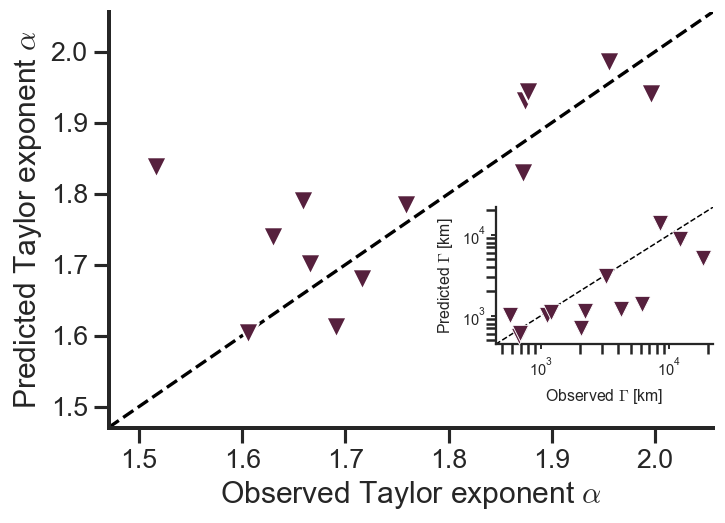

In [70]:
# Figure 4B: Taylor exponent prediction.

def plot_fig4_panel_b(ax):
    data = fig4_read_scatter("panel_b_Taylor_Law_Scatter_scatter.csv")
    color = COLORS["GRUMP"]
    lim_min = min(data["X_hist"].min(), data["Y_hist"].min()) * 0.97
    lim_max = max(data["X_hist"].max(), data["Y_hist"].max()) * 1.03
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color="black", lw=2.0, ls="--", zorder=1)
    ax.scatter(data["X_hist"], data["Y_hist"], s=153, marker=MARKERS["GRUMP"], color=color, alpha=1.0, edgecolors="white", linewidths=1.3, zorder=5)
    ax.set(xlabel=r"Observed Taylor exponent $\alpha$", ylabel=r"Predicted Taylor exponent $\alpha$", xlim=(lim_min, lim_max), ylim=(lim_min, lim_max))
    style_fig4_axis(ax)

    inset = ax.inset_axes([0.64, 0.20, 0.36, 0.33])
    inset_data = fig4_read_scatter("panel_b_inset_Taylor_Law_Gamma_Scatter_scatter.csv")
    inset_min = min(inset_data["X_hist"].min(), inset_data["Y_hist"].min()) * 0.8
    inset_max = max(inset_data["X_hist"].max(), inset_data["Y_hist"].max()) * 1.2
    inset.plot([inset_min, inset_max], [inset_min, inset_max], color="black", lw=0.9, ls="--", zorder=1)
    inset.scatter(inset_data["X_hist"], inset_data["Y_hist"], s=96, marker=MARKERS["GRUMP"], color=color, alpha=1.0, edgecolors="white", linewidths=0.55, zorder=5)
    inset.set(xlabel=r"Observed $\Gamma$ [km]", ylabel=r"Predicted $\Gamma$ [km]", xlim=(inset_min, inset_max), ylim=(inset_min, inset_max))
    inset.set_xticks([1e3, 1e4])
    inset.set_yticks([1e3, 1e4])
    inset.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    inset.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    style_fig4_inset(inset, xscale="log", yscale="log")
    inset.tick_params(axis="x", pad=4)
    inset.tick_params(axis="y", pad=3)
    inset.xaxis.labelpad = 5
    inset.yaxis.labelpad = 4
    return ax

with mpl.rc_context({"pdf.fonttype": 3}):
    fig, ax = plt.subplots(figsize=FIG4_FIGSIZE)
    plot_fig4_panel_b(ax)
    fig4_panel_b_saved_paths = save_figure(fig, "fig4_panelB_taylor_law_scatter", transparent=True)

fig4_panel_b_saved_paths


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelC_chlorophyll_patch_model.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelC_chlorophyll_patch_model.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelC_chlorophyll_patch_model.svg')]

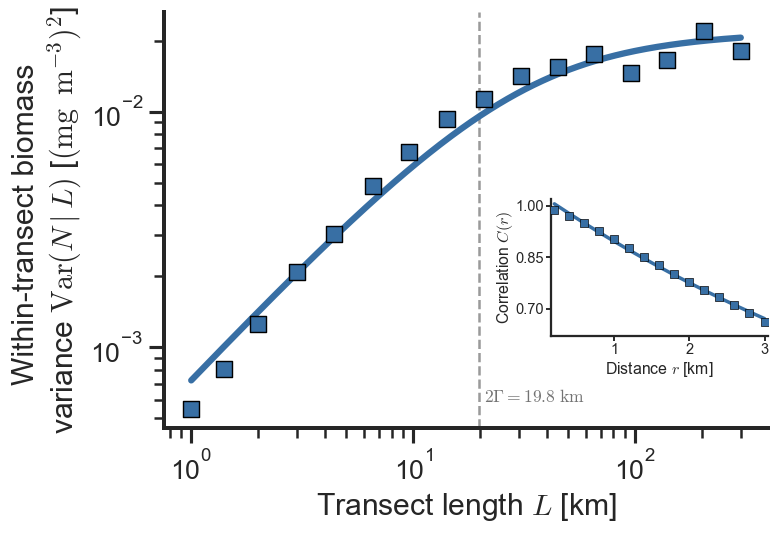

In [71]:
# Figure 4C: chlorophyll patch model.

def plot_fig4_panel_c(ax):
    data = fig4_read_scatter("panel_c_Chl_Correlation_PatchModel_scatter.csv")
    params = FIG4_PARAMS.loc["c_main"]
    gamma_km = params["Gamma_km"]
    amplitude = params["Other_Param"]
    x_data = np.exp(data["X_hist"])
    y_data = np.exp(data["Y_hist"])
    x_fit = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 500)
    y_fit = fig4_patch_model(x_fit, gamma_km, amplitude)

    color = COLORS["Tara"]
    ax.plot(x_fit, y_fit, color=color, lw=3.8, zorder=2)
    crossover_km = 2 * gamma_km
    ax.axvline(crossover_km, color="0.45", lw=1.5, ls="--", alpha=0.72, zorder=1)
    ax.text(crossover_km * 1.06, 0.055, rf"$2\Gamma={crossover_km:.1f}\ \mathrm{{km}}$", transform=ax.get_xaxis_transform(), color="0.45", fontsize=10.5, ha="left", va="bottom", zorder=6)
    ax.scatter(x_data, y_data, s=102, marker=MARKERS["Tara"], color=color, alpha=1.0, edgecolors="black", linewidths=0.85, zorder=5)
    ax.set(xlabel=r"Transect length $L$ [km]", ylabel="Within-transect biomass \n" + r"variance $\mathrm{Var}(N\mid L)$ [$(\mathrm{mg}\,\,\, \mathrm{m}^{-3})^2$]")
    style_fig4_axis(ax, xscale="log", yscale="log")

    inset = ax.inset_axes([0.64, 0.22, 0.36, 0.33])
    inset_data = fig4_read_scatter("panel_c_inset_Chl_Correlation_Linear_scatter.csv")
    inset_gamma = FIG4_PARAMS.loc["c_inset", "Gamma_km"]
    inset_amp = np.exp(np.mean(np.log(inset_data["Y_hist"]) + inset_data["X_hist"] / inset_gamma))
    inset_x = np.linspace(inset_data["X_hist"].min(), inset_data["X_hist"].max(), 300)
    inset.plot(inset_x, fig4_exponential_curve(inset_x, inset_gamma, inset_amp), color=color, lw=2.1, zorder=2)
    inset.scatter(inset_data["X_hist"], inset_data["Y_hist"], s=22, marker=MARKERS["Tara"], color=color, alpha=1.0, edgecolors="black", linewidths=0.4, zorder=5)
    inset.set(xlabel=r"Distance $r$ [km]", ylabel=r"Correlation $C(r)$", xlim=(0.15, 3.05), ylim=(0.62, 1.02), xticks=[1, 2, 3], yticks=[0.7, 0.85, 1.0])
    style_fig4_inset(inset)
    return ax

with mpl.rc_context({"pdf.fonttype": 3}):
    fig, ax = plt.subplots(figsize=FIG4_FIGSIZE)
    plot_fig4_panel_c(ax)
    fig4_panel_c_saved_paths = save_figure(fig, "fig4_panelC_chlorophyll_patch_model", transparent=True)

fig4_panel_c_saved_paths


[WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelD_chlorophyll_patchiness.png'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelD_chlorophyll_patchiness.pdf'),
 WindowsPath('f:/Downloads/MacroecologyMarine-main/figures/fig4_panelD_chlorophyll_patchiness.svg')]

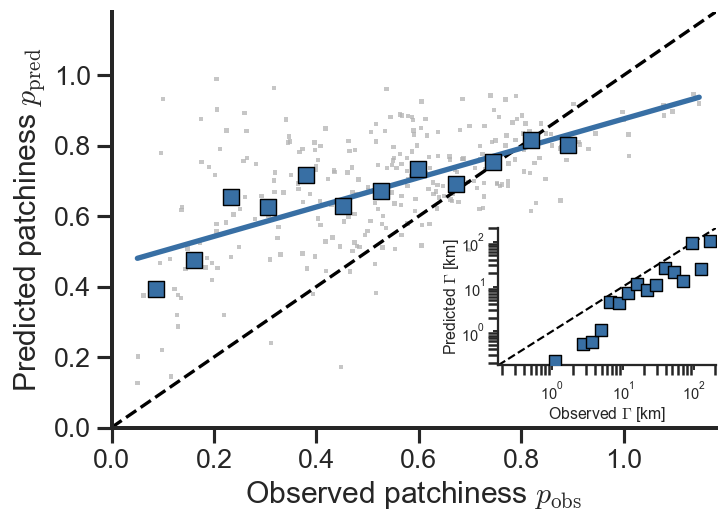

In [72]:
# Figure 4D: chlorophyll patchiness.

def plot_fig4_panel_d(ax):
    bg_data = pd.read_csv(FIG4_DIR / "panel_d_Patchiness_Linear_bg_scatter.csv")
    bg_data = bg_data.apply(pd.to_numeric, errors="coerce").dropna(subset=["X_bg", "Y_bg"])
    median_data = fig4_read_scatter("panel_d_Patchiness_Linear_scatter.csv")
    curve = pd.read_csv(FIG4_DIR / "panel_d_Patchiness_Linear_curve.csv")
    curve = curve.apply(pd.to_numeric, errors="coerce").dropna(subset=["X_axis", "Y_axis"]).sort_values("X_axis")
    color = COLORS["Tara"]
    ax.scatter(bg_data["X_bg"], bg_data["Y_bg"], s=7, marker=MARKERS["Tara"], color="0.70", alpha=0.75, edgecolors="none", linewidths=0, rasterized=True, zorder=1)
    ax.plot([0, 1.18], [0, 1.18], color="black", lw=2.0, ls="--", zorder=2)
    ax.plot(curve["X_axis"], curve["Y_axis"], color=color, lw=3.2, zorder=3)
    ax.scatter(median_data["X_hist"], median_data["Y_hist"], s=102, marker=MARKERS["Tara"], color=color, alpha=1.0, edgecolors="black", linewidths=0.85, zorder=5)
    ax.set(xlabel=r"Observed patchiness $p_{\mathrm{obs}}$", ylabel=r"Predicted patchiness $p_{\mathrm{pred}}$", xlim=(0., 1.18), ylim=(0., 1.18), xticks=[0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    style_fig4_axis(ax)

    inset = ax.inset_axes([0.64, 0.15, 0.36, 0.33])
    inset_data = fig4_read_scatter("panel_d_inset_Patchiness_Gamma_PowerLaw_scatter.csv")
    inset_min = min(inset_data["X_hist"].min(), inset_data["Y_hist"].min()) * 0.8
    inset_max = max(inset_data["X_hist"].max(), inset_data["Y_hist"].max()) * 1.2
    inset.plot([inset_min, inset_max], [inset_min, inset_max], color="black", lw=1.3, ls="--", zorder=1)
    inset.scatter(inset_data["X_hist"], inset_data["Y_hist"], s=56, marker=MARKERS["Tara"], color=color, alpha=1, edgecolors="black", linewidths=0.85, zorder=5)
    inset.set(xlabel=r"Observed $\Gamma$ [km]", ylabel=r"Predicted $\Gamma$ [km]", xlim=(inset_min, inset_max), ylim=(inset_min, inset_max), xticks=[1, 10, 100], yticks=[1, 10, 100])
    style_fig4_inset(inset, xscale="log", yscale="log")
    inset.tick_params(axis="x", pad=6)
    inset.tick_params(axis="y", pad=5)
    return ax

with mpl.rc_context({"pdf.fonttype": 3}):
    fig, ax = plt.subplots(figsize=FIG4_FIGSIZE)
    plot_fig4_panel_d(ax)
    fig4_panel_d_saved_paths = save_figure(fig, "fig4_panelD_chlorophyll_patchiness", transparent=True)

fig4_panel_d_saved_paths


# Fig SM MareChiara

In [13]:
MARECHIARA_GROUP_MARKERS = ["o", "s", "^"]


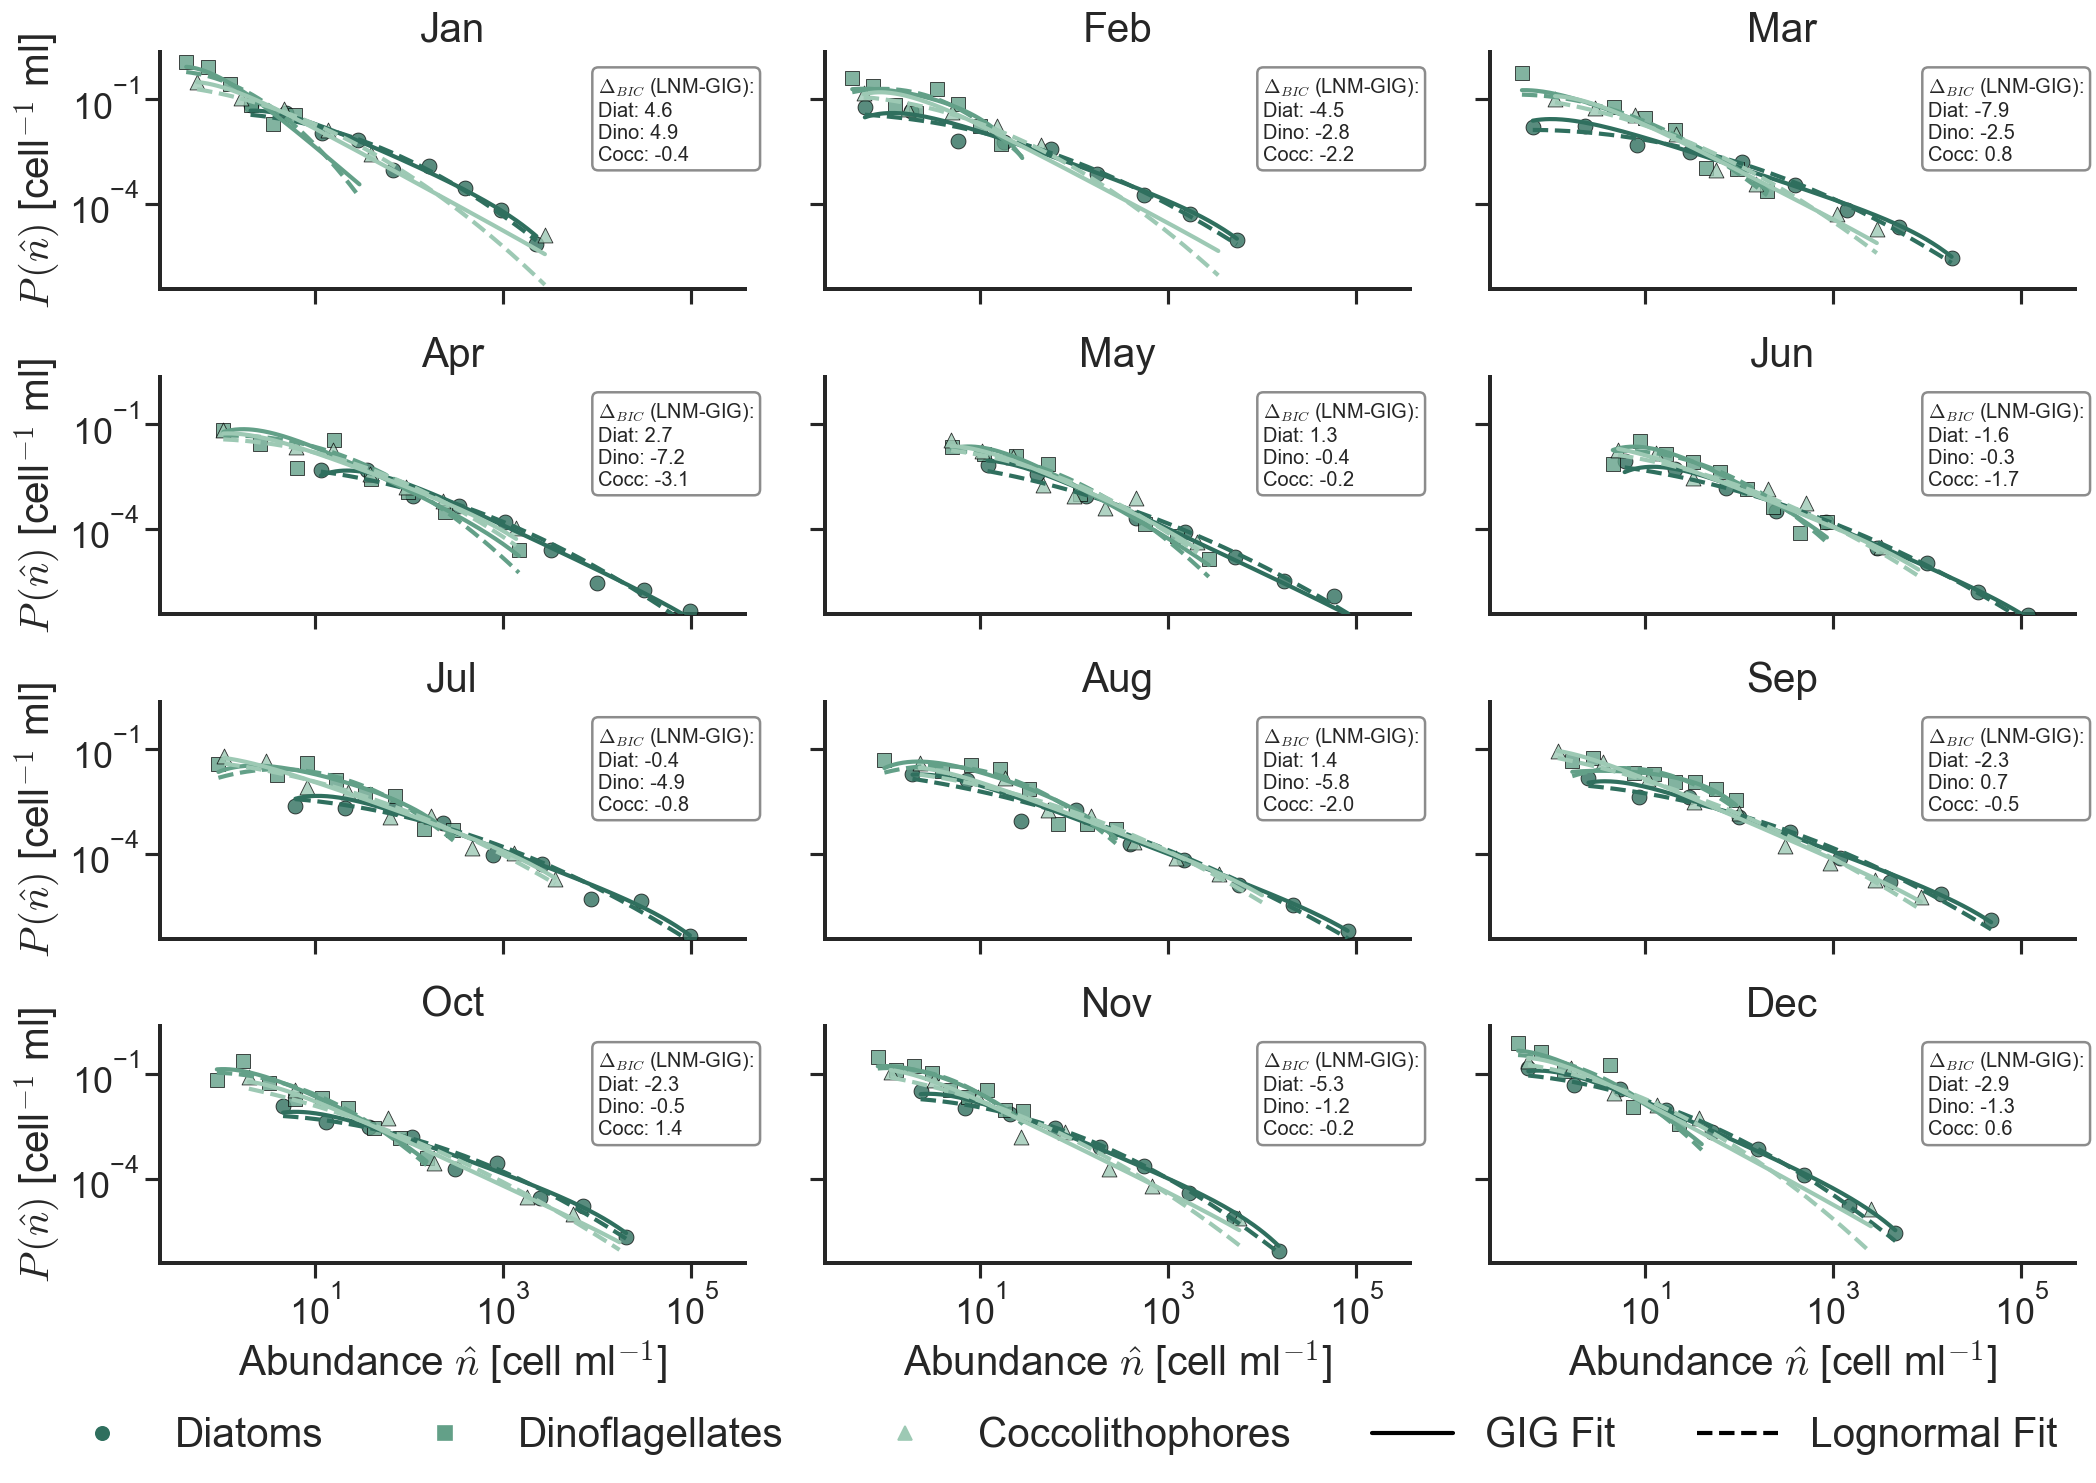

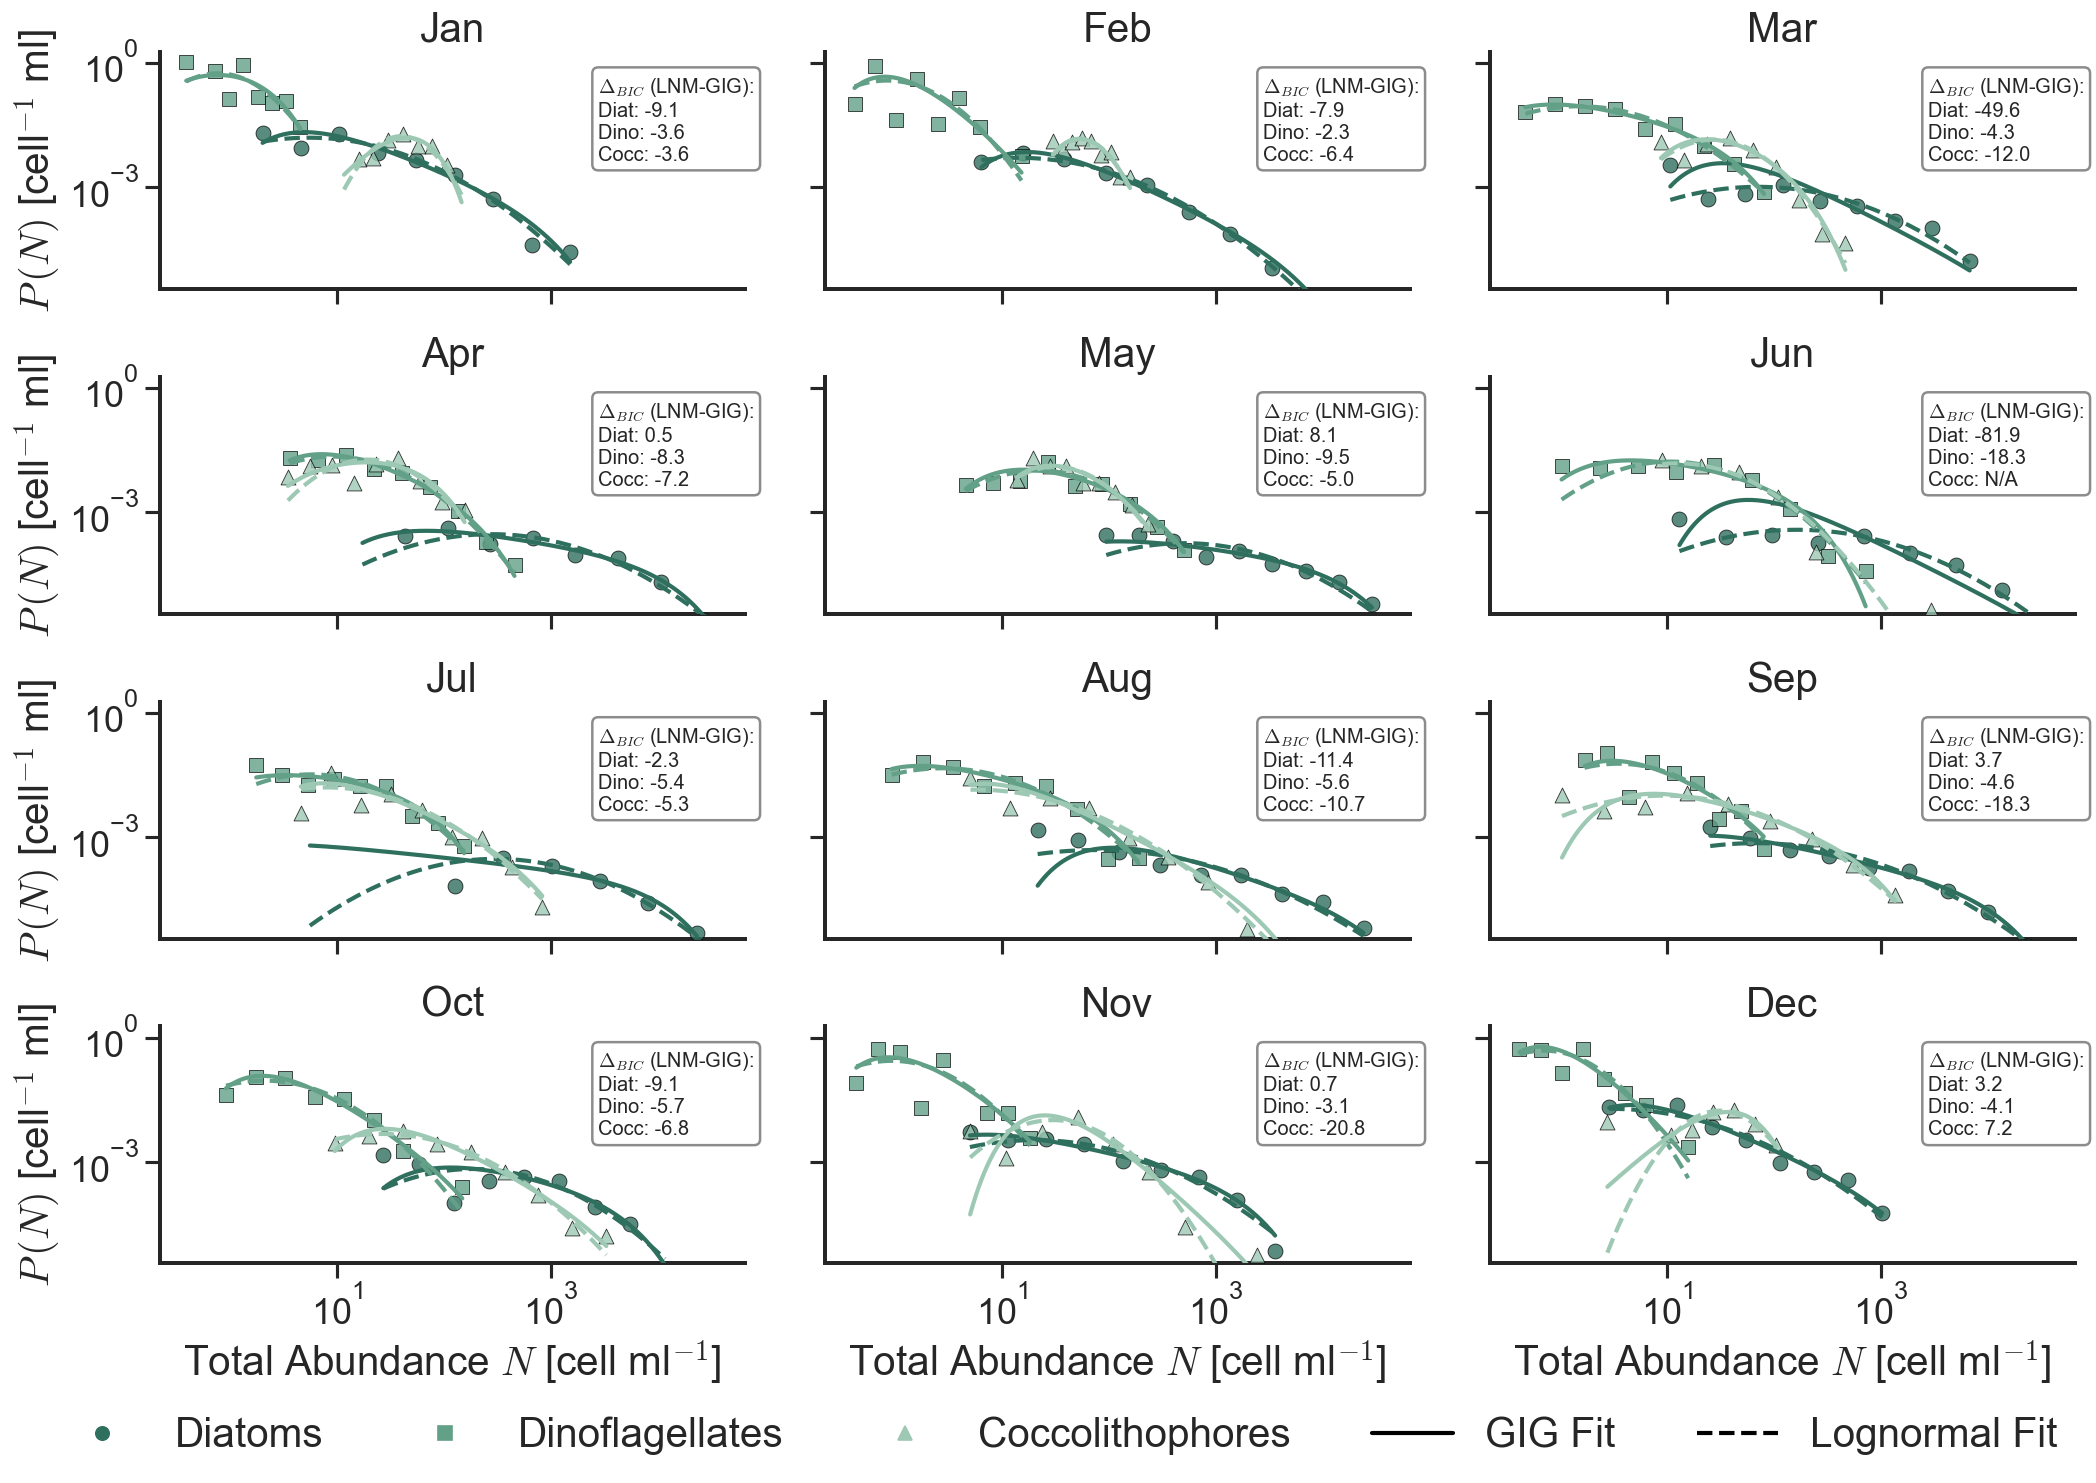

In [14]:
def logGIG(n, b, c, mu):
    n = np.maximum(n, 1e-12)
    kv_val = sp.special.kv(1 - 2 * mu, 2 * np.sqrt(b / c))
    if np.isscalar(kv_val):
        if kv_val <= 0 or not np.isfinite(kv_val):
            return -np.inf * np.ones_like(n)
    else:
        if np.any(kv_val <= 0) or not np.all(np.isfinite(kv_val)):
            return -np.inf * np.ones_like(n)
    return ((0.5 - mu) * np.log(b * c) - b / n - n / c - (2.0 - 2.0 * mu) * np.log(n) - np.log(2) - np.log(kv_val))

def logLognorm(n, mu, sigma):
    n = np.maximum(n, 1e-12)
    return -np.log(n * sigma * np.sqrt(2 * np.pi)) - ((np.log(n) - mu)**2) / (2 * sigma**2)

df_sad_points = pd.read_csv(FIG_MC_DIR / "SAD_season.csv")
df_tad_points = pd.read_csv(FIG_MC_DIR / "TAD_season.csv")
df_sad_params = pd.read_csv(FIG_MC_DIR / "parameters_distribution_SAD.csv")
df_tad_params = pd.read_csv(FIG_MC_DIR / "parameters_distribution_TAD.csv")

for df in [df_sad_points, df_tad_points, df_sad_params, df_tad_params]:
    df['Month_ID'] = pd.to_numeric(df['Month_ID'], errors='coerce')
    df['Group_ID'] = pd.to_numeric(df['Group_ID'], errors='coerce')

n_rows, n_cols = 4, 3
marker_size = 80
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

group_names = ["Diatoms", "Dinoflagellates", "Coccolithophores"]
n_groups = len(group_names)


with mpl.rc_context({"pdf.fonttype": 3}):
    fig_sad, axes_sad = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True, sharey=True)
    fig_tad, axes_tad = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True, sharey=True)

    for m in range(12):
        row, col = divmod(m, n_cols)

        ax_sad = axes_sad[row, col]
        bic_text_lines_sad = [r"$\Delta_{BIC}$ (LNM-GIG):"]
        
        for j in range(n_groups):
            pts = df_sad_points[(df_sad_points['Month_ID'] == m) & (df_sad_points['Group_ID'] == j)]
            if not pts.empty:
                color = list(MARECHIARA_GROUP_COLORS.values())[j]
                marker = MARECHIARA_GROUP_MARKERS[j]
                
                ax_sad.scatter(pts['x'], pts['y'], alpha=0.8, s=marker_size, color=color, marker=marker, edgecolors="black", linewidths=0.5, zorder=3)
                x_fit = np.logspace(np.log10(pts['x'].min()), np.log10(pts['x'].max()), 200)
                
                params = df_sad_params[(df_sad_params['Month_ID'] == m) & (df_sad_params['Group_ID'] == j)]
                if not params.empty:
                    b0 = params['GIG_b0'].values[0]
                    c_val = params['GIG_c'].values[0]
                    mu = params['GIG_mu'].values[0]
                    
                    mu_ln = params['LogNorm_mu'].values[0]
                    sigma_ln = params['LogNorm_sigma'].values[0]
                    
                    bic_gig = params['BIC_GIG'].values[0]
                    bic_ln = params['BIC_LogNorm'].values[0]
                    
                    if not pd.isna(b0) and not pd.isna(c_val) and not pd.isna(mu):
                        y_gig = np.exp(logGIG(x_fit, b0, c_val, mu))
                        ax_sad.plot(x_fit, y_gig, lw=2.5, color=color, linestyle='-', zorder=4)
                    
                    if not pd.isna(mu_ln) and not pd.isna(sigma_ln):
                        y_ln = np.exp(logLognorm(x_fit, mu_ln, sigma_ln))
                        ax_sad.plot(x_fit, y_ln, lw=2.5, color=color, linestyle='--', zorder=4)

                    if not pd.isna(bic_gig) and not pd.isna(bic_ln):
                        delta_bic = bic_ln - bic_gig
                        bic_text_lines_sad.append(f"{group_names[j][:4]}: {delta_bic:.1f}")
                    else:
                        bic_text_lines_sad.append(f"{group_names[j][:4]}: N/A")

        if len(bic_text_lines_sad) > 1:
            ax_sad.text(0.75, 0.90, "\n".join(bic_text_lines_sad), transform=ax_sad.transAxes, 
                        fontsize=12, verticalalignment='top', zorder=10,
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.9))

        ax_sad.set_xscale('log')
        ax_sad.set_yscale('log')
        ax_sad.set_title(f"{month_names[m]}")
        sns.despine(ax=ax_sad)

        ax_tad = axes_tad[row, col]
        bic_text_lines_tad = [r"$\Delta_{BIC}$ (LNM-GIG):"]

        for j in range(n_groups):
            pts = df_tad_points[(df_tad_points['Month_ID'] == m) & (df_tad_points['Group_ID'] == j)]
            if not pts.empty:
                color = list(MARECHIARA_GROUP_COLORS.values())[j]
                marker = MARECHIARA_GROUP_MARKERS[j]
                
                ax_tad.scatter(pts['x'], pts['y'], alpha=0.8, s=marker_size, color=color, marker=marker, edgecolors="black", linewidths=0.5, zorder=3)
                x_fit = np.logspace(np.log10(pts['x'].min()), np.log10(pts['x'].max()), 200)
                
                params = df_tad_params[(df_tad_params['Month_ID'] == m) & (df_tad_params['Group_ID'] == j)]
                if not params.empty:
                    b0 = params['GIG_b0'].values[0]
                    c_val = params['GIG_c'].values[0]
                    mu = params['GIG_mu'].values[0]
                    
                    mu_ln = params['LogNorm_mu'].values[0]
                    sigma_ln = params['LogNorm_sigma'].values[0]
                    
                    bic_gig = params['BIC_GIG'].values[0]
                    bic_ln = params['BIC_LogNorm'].values[0]
                    
                    if not pd.isna(b0) and not pd.isna(c_val) and not pd.isna(mu):
                        y_gig = np.exp(logGIG(x_fit, b0, c_val, mu))
                        ax_tad.plot(x_fit, y_gig, lw=2.5, color=color, linestyle='-', zorder=4)
                    
                    if not pd.isna(mu_ln) and not pd.isna(sigma_ln):
                        y_ln = np.exp(logLognorm(x_fit, mu_ln, sigma_ln))
                        ax_tad.plot(x_fit, y_ln, lw=2.5, color=color, linestyle='--', zorder=4)

                    if not pd.isna(bic_gig) and not pd.isna(bic_ln):
                        delta_bic = bic_ln - bic_gig
                        bic_text_lines_tad.append(f"{group_names[j][:4]}: {delta_bic:.1f}")
                    else:
                        bic_text_lines_tad.append(f"{group_names[j][:4]}: N/A")

        if len(bic_text_lines_tad) > 1:
            ax_tad.text(0.75, 0.90, "\n".join(bic_text_lines_tad), transform=ax_tad.transAxes, 
                        fontsize=12, verticalalignment='top', zorder=10,
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.9))

        ax_tad.set_xscale('log')
        ax_tad.set_yscale('log')
        ax_tad.set_title(f"{month_names[m]}")
        sns.despine(ax=ax_tad)

    for axes, xlabel, ylabel in zip([axes_sad, axes_tad], [r"Abundance $\hat{n}$ [cell ml$^{-1}$]", r"Total Abundance $N$ [cell ml$^{-1}$]"], [r"$P\,(\hat{n})$ [cell$^{-1}$ ml]", r"$P\,(N)$ [cell$^{-1}$ ml]"]):
        for i in range(n_cols):
            axes[n_rows-1, i].set_xlabel(xlabel)
        for i in range(n_rows):
            axes[i, 0].set_ylabel(ylabel)

    legend_groups = [mlines.Line2D([], [], color=list(MARECHIARA_GROUP_COLORS.values())[j], marker=MARECHIARA_GROUP_MARKERS[j], linestyle='None', 
                                    markersize=8, label=group_names[j]) for j in range(n_groups)]
    legend_fits = [
        mlines.Line2D([], [], color='black', lw=2.5, linestyle='-', label='GIG Fit'),
        mlines.Line2D([], [], color='black', lw=2.5, linestyle='--', label='Lognormal Fit')
    ]
    all_legend_handles = legend_groups + legend_fits
    
    fig_sad.legend(handles=all_legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=5, frameon=False)
    fig_tad.legend(handles=all_legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=5, frameon=False)

    fig_sad.tight_layout()
    fig_tad.tight_layout()
    
    save_figure(fig_sad, "fig_SAD_MC_distributions", transparent=True)
    save_figure(fig_tad, "fig_TAD_MC_distributions", transparent=True)

    plt.show()

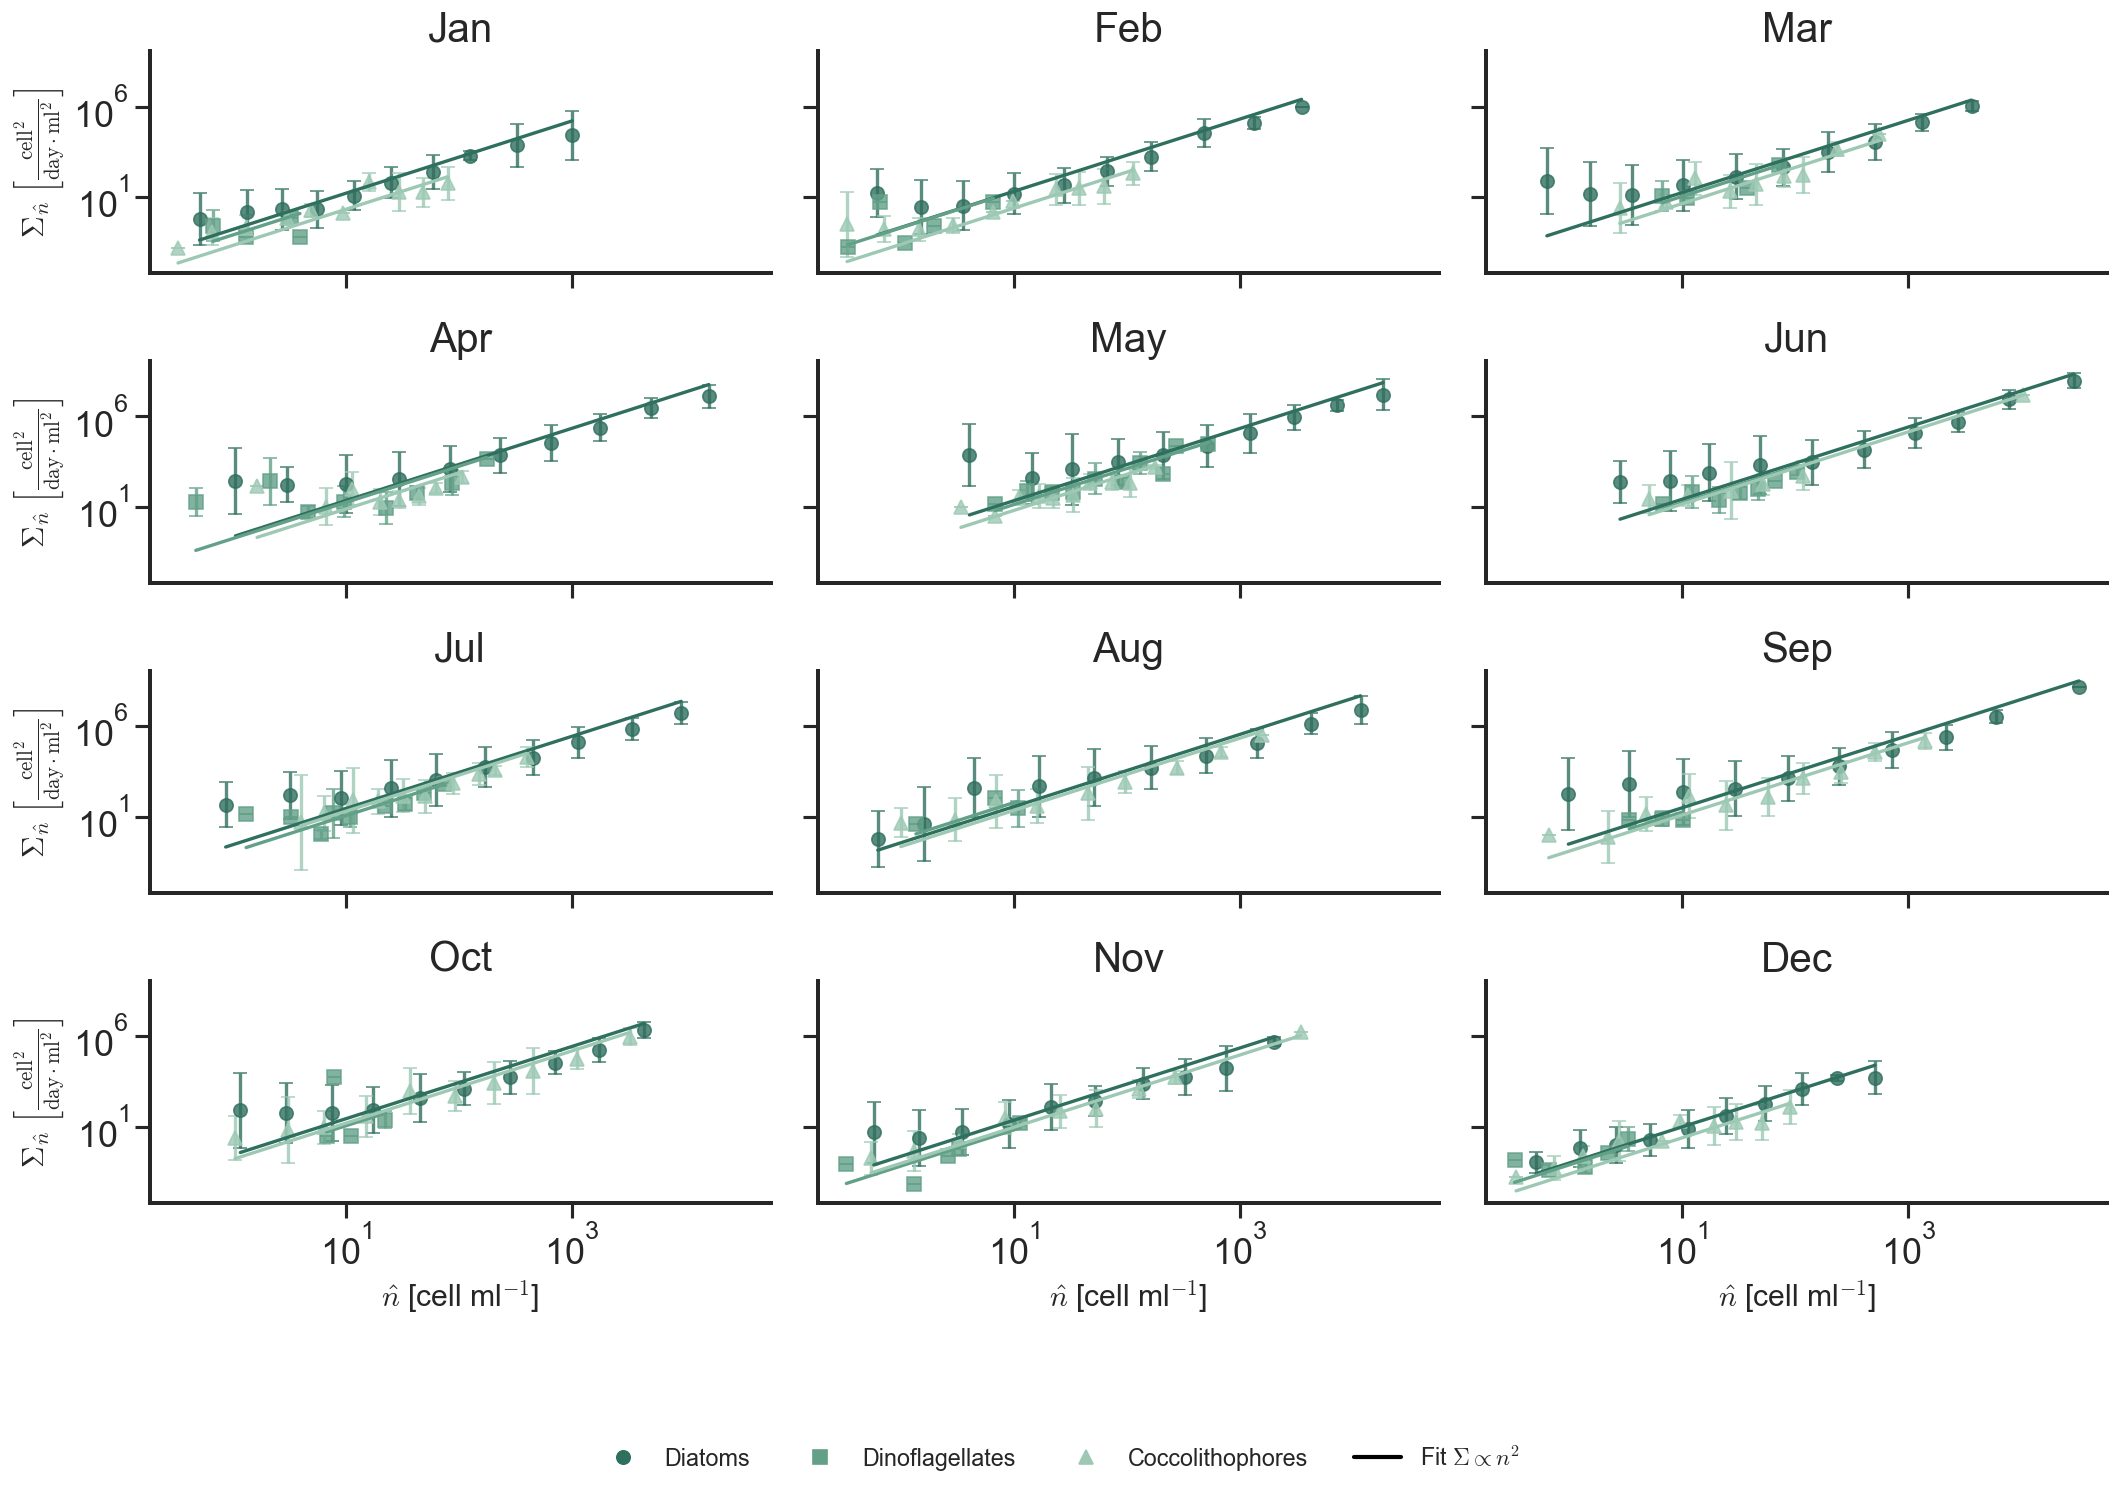

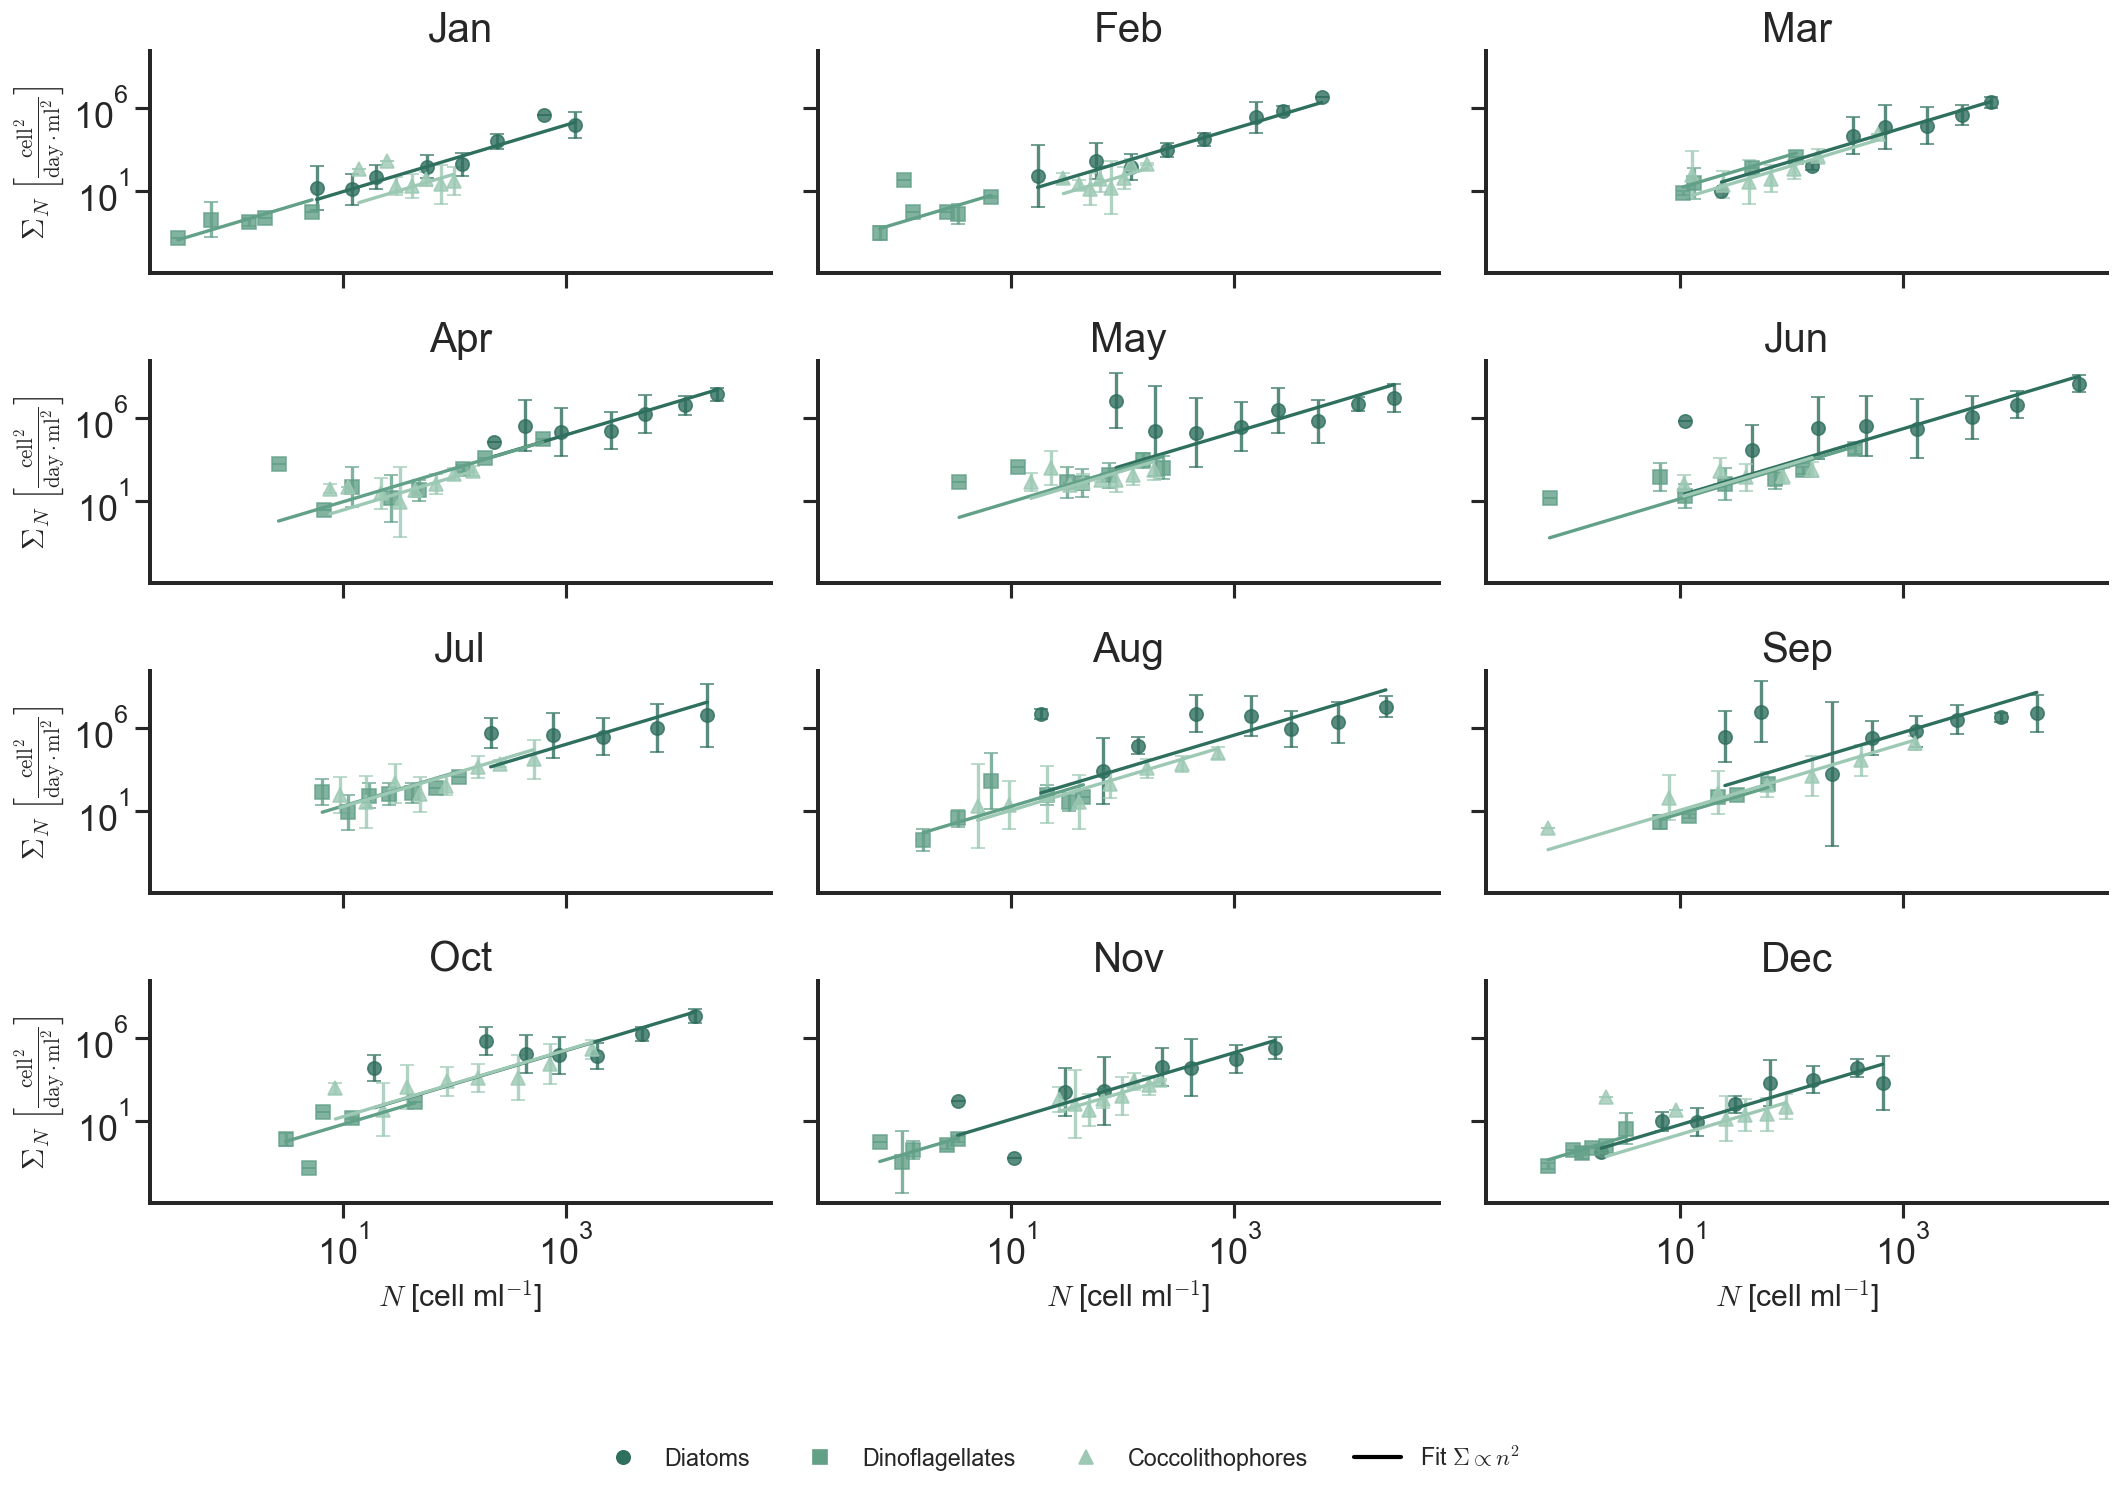

In [15]:
FIG_MC_DIR = DATA_DIR / "plot_MareChiara"

df_sigma_sp = pd.read_csv(FIG_MC_DIR / "Sigma_species.csv")
df_sigma_tot = pd.read_csv(FIG_MC_DIR / "Sigma_total_abundance.csv")

for df in [df_sigma_sp, df_sigma_tot]:
    df['Month_ID'] = pd.to_numeric(df['Month_ID'], errors='coerce')
    df['Group_ID'] = pd.to_numeric(df['Group_ID'], errors='coerce')

n_rows, n_cols = 4, 3
marker_size = 80
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
group_names = ["Diatoms", "Dinoflagellates", "Coccolithophores"]
n_groups = len(group_names)
MARECHIARA_GROUP_MARKERS = ["o", "s", "^"]

with mpl.rc_context({"pdf.fonttype": 3}):
    fig_sigma_sp, axes_sigma_sp = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True, sharey=True)
    fig_sigma_tot, axes_sigma_tot = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True, sharey=True)

    for m in range(12):
        row, col = divmod(m, n_cols)

        ax_sp = axes_sigma_sp[row, col]
        for j in range(n_groups):
            pts = df_sigma_sp[(df_sigma_sp['Month_ID'] == m) & (df_sigma_sp['Group_ID'] == j)]
            if not pts.empty:
                color = list(MARECHIARA_GROUP_COLORS.values())[j]
                marker = MARECHIARA_GROUP_MARKERS[j]
                
                x_vals = pts['x'].to_numpy()
                y_vals = pts['y'].to_numpy()
                y_low = pts['y_low'].to_numpy()
                y_high = pts['y_high'].to_numpy()
                
                yerr_low = y_vals - y_low
                yerr_high = y_high - y_vals
                
                ax_sp.errorbar(x_vals, y_vals, yerr=[yerr_low, yerr_high], fmt=marker, color=color, alpha=0.8, ecolor=color, capsize=4, markersize=8, zorder=3,elinewidth=2)
                
                intercept = pts['intercept'].values[0]
                if not pd.isna(intercept) and len(x_vals) >= 2:
                    x_fit = np.logspace(np.log10(x_vals.min()), np.log10(x_vals.max()), 200)
                    y_fit = intercept * x_fit**2
                    ax_sp.plot(x_fit, y_fit, color=color, lw=2, zorder=4)

        ax_sp.set_xscale('log')
        ax_sp.set_yscale('log')
        #ax_sp.grid(True, alpha=0.3)
        ax_sp.set_title(f"{month_names[m]}")
        sns.despine(ax=ax_sp)

        ax_tot = axes_sigma_tot[row, col]
        for j in range(n_groups):
            pts = df_sigma_tot[(df_sigma_tot['Month_ID'] == m) & (df_sigma_tot['Group_ID'] == j)]
            if not pts.empty:
                color = list(MARECHIARA_GROUP_COLORS.values())[j]
                marker = MARECHIARA_GROUP_MARKERS[j]
                
                x_vals = pts['x'].to_numpy()
                y_vals = pts['y'].to_numpy()
                y_low = pts['y_low'].to_numpy()
                y_high = pts['y_high'].to_numpy()
                
                yerr_low = y_vals - y_low
                yerr_high = y_high - y_vals
                
                ax_tot.errorbar(x_vals, y_vals, yerr=[yerr_low, yerr_high], fmt=marker, color=color, alpha=0.8, ecolor=color, capsize=4, markersize=8, zorder=3, elinewidth=2)
                
                intercept = pts['intercept'].values[0]
                if not pd.isna(intercept) and len(x_vals) >= 2:
                    x_fit = np.logspace(np.log10(x_vals.min()), np.log10(x_vals.max()), 200)
                    y_fit = intercept * x_fit**2
                    ax_tot.plot(x_fit, y_fit, color=color, lw=2, zorder=4)

        ax_tot.set_xscale('log')
        ax_tot.set_yscale('log')
        #ax_tot.grid(True, alpha=0.3)
        ax_tot.set_title(f"{month_names[m]}")
        sns.despine(ax=ax_tot)

    for axes, xlabel, ylabel in zip(
        [axes_sigma_sp, axes_sigma_tot], 
        [r"$\hat{n}$ [cell ml$^{-1}$]", r"$N$ [cell ml$^{-1}$]"], 
        [
            r"$\Sigma_{\hat{n}} \; \left[ \frac{\mathrm{cell}^{2}}{\mathrm{day} \cdot \mathrm{ml}^{2}} \right]$", 
            r"$\Sigma_N \; \left[ \frac{\mathrm{cell}^{2}}{\mathrm{day} \cdot \mathrm{ml}^{2}} \right]$"
        ]
    ):
        for i in range(n_cols):
            axes[n_rows-1, i].set_xlabel(xlabel, fontsize=18)
        for i in range(n_rows):
            axes[i, 0].set_ylabel(ylabel, fontsize=18)

    legend_groups = [mlines.Line2D([], [], color=list(MARECHIARA_GROUP_COLORS.values())[j], marker=MARECHIARA_GROUP_MARKERS[j], linestyle='None', 
                                    markersize=8, label=group_names[j]) for j in range(n_groups)]
    legend_fits = [
        mlines.Line2D([], [], color='black', lw=2.5, linestyle='-', label=r"Fit $\Sigma \propto n^{2}$")
    ]
    all_legend_handles = legend_groups + legend_fits
    
    fig_sigma_sp.legend(handles=all_legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, fontsize=14)
    fig_sigma_tot.legend(handles=all_legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, fontsize=14)

    fig_sigma_sp.tight_layout(rect=[0, 0.05, 1, 1])
    fig_sigma_tot.tight_layout(rect=[0, 0.05, 1, 1])
    
    if 'save_figure' in globals():
        save_figure(fig_sigma_sp, "figSM_season_species", transparent=True)
        save_figure(fig_sigma_tot, "figSM_senason_total", transparent=True)

    plt.show()

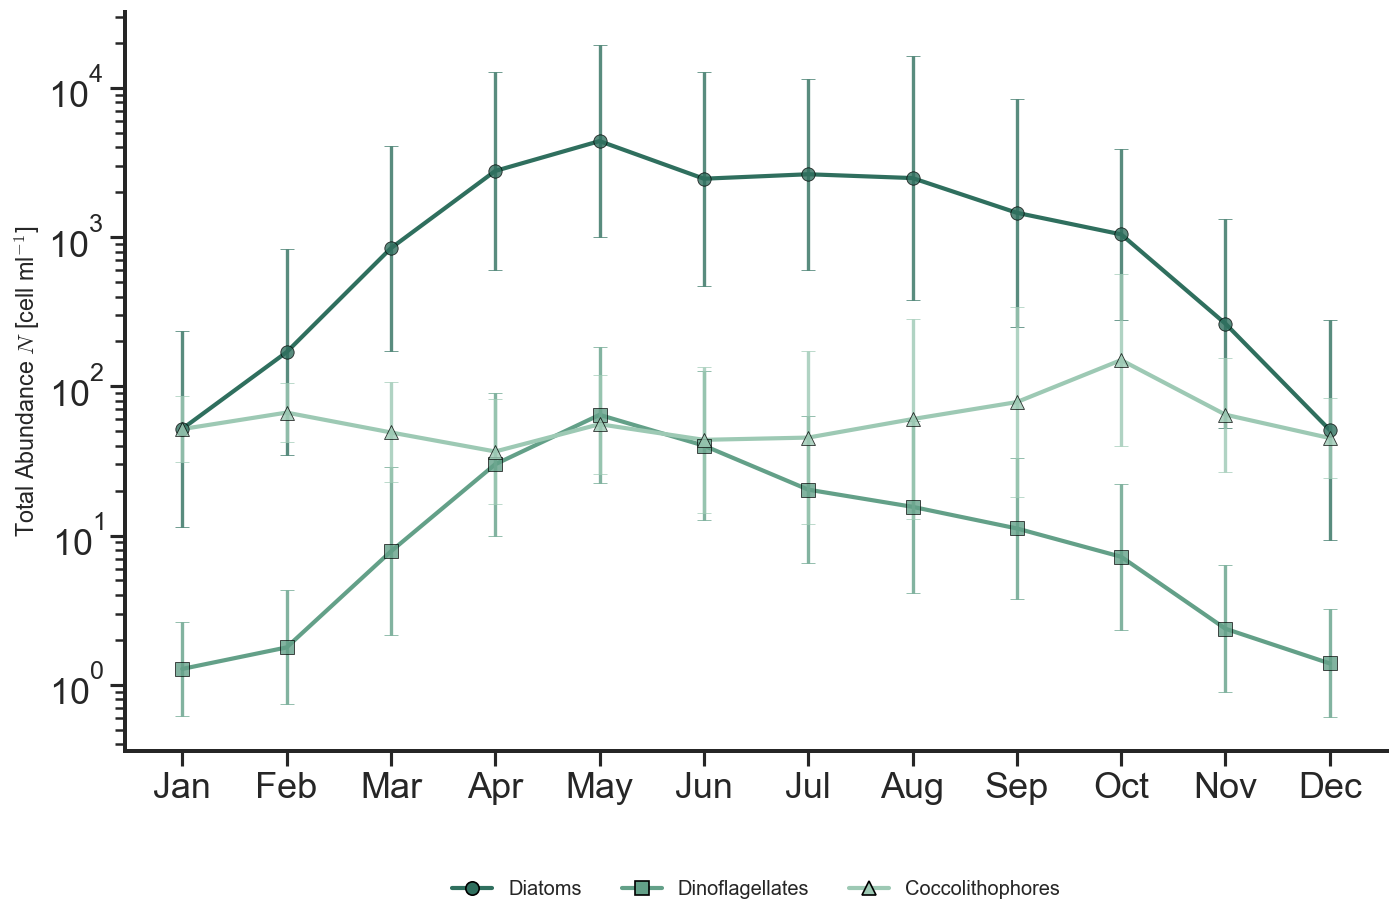

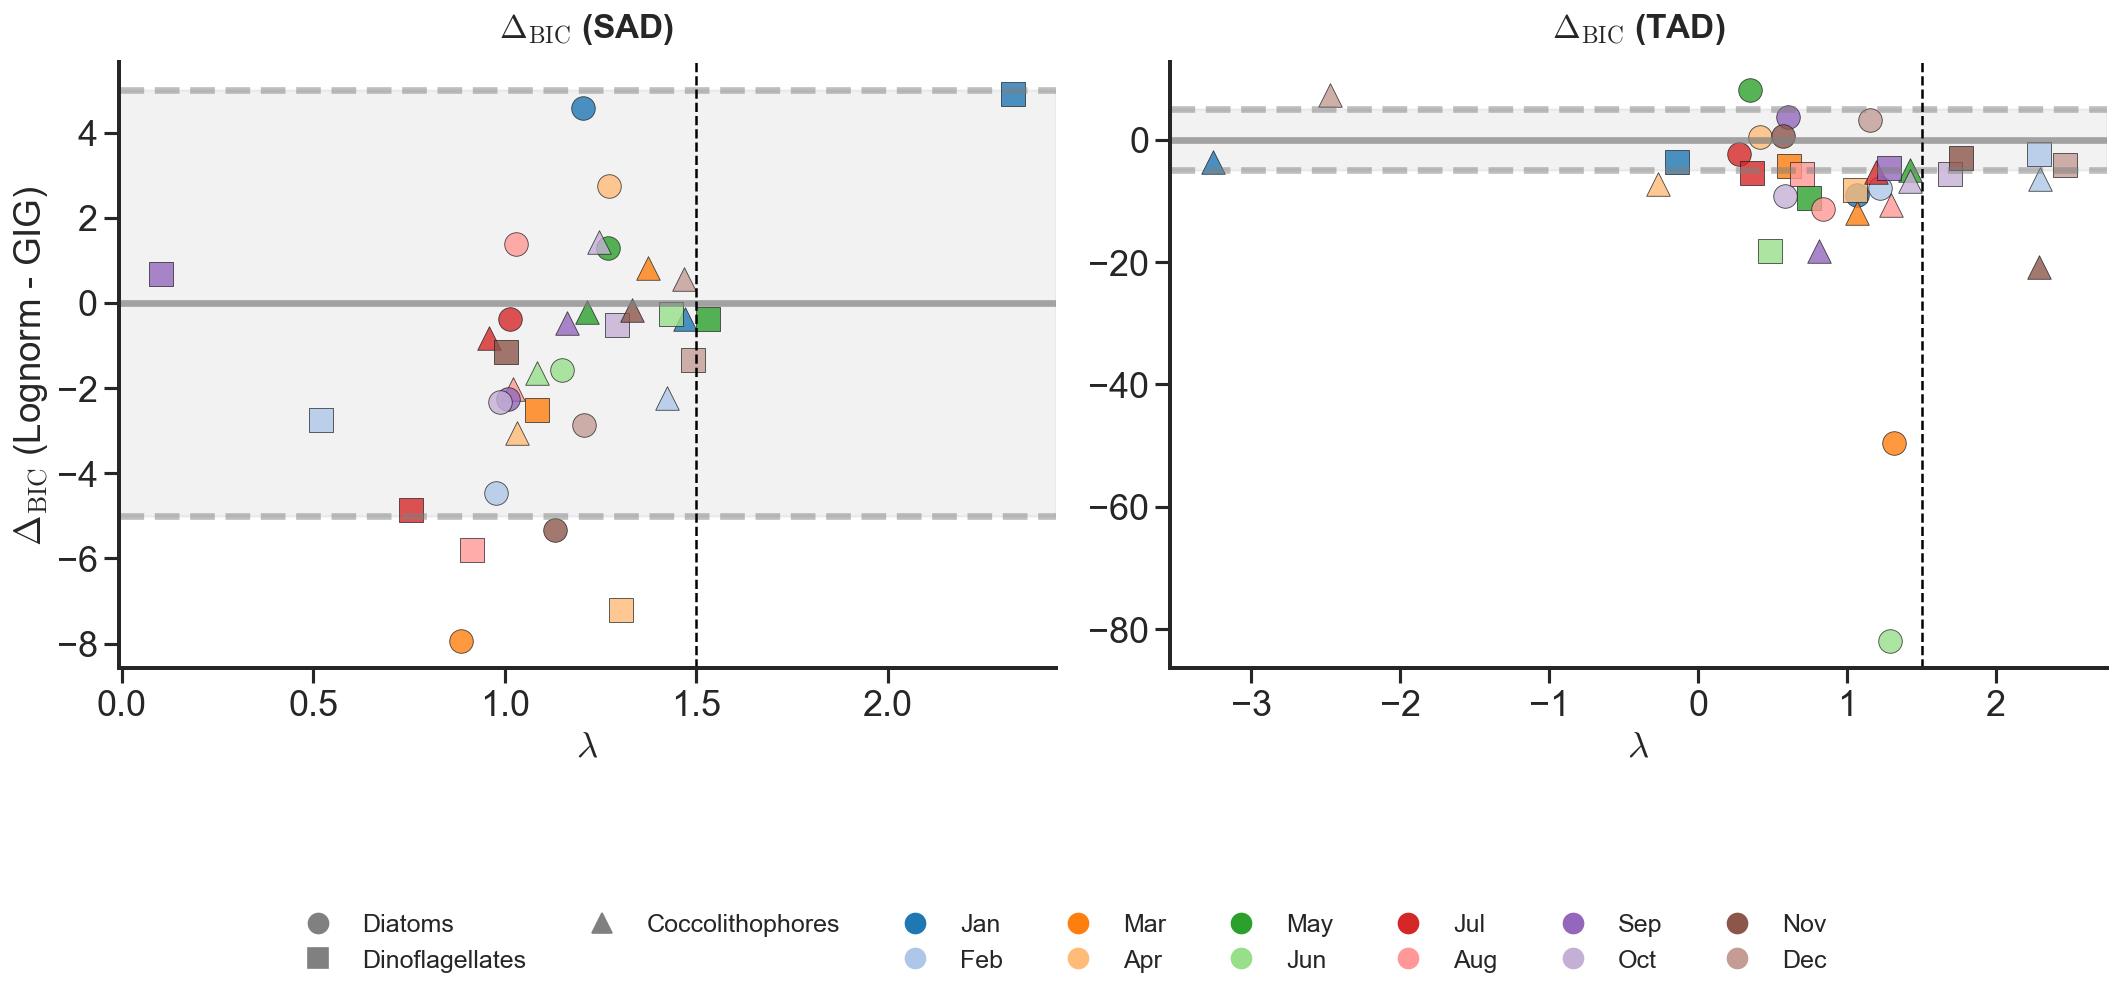

In [16]:
path_trend = r"F:\Downloads\MacroecologyMarine-main\data\plot_MareChiara\Season_total_abundance.csv"
path_sad_params = r"F:\Downloads\MacroecologyMarine-main\data\plot_MareChiara\parameters_distribution_SAD.csv"
path_tad_params = r"F:\Downloads\MacroecologyMarine-main\data\plot_MareChiara\parameters_distribution_TAD.csv"

df_points = pd.read_csv(path_trend)
df_points['Plot_Type'] = 'Seasonality_TAD'

df_sad = pd.read_csv(path_sad_params)
df_tad = pd.read_csv(path_tad_params)

df_params = pd.merge(
    df_sad[['Month_ID', 'Group_ID', 'GIG_mu', 'Delta_BIC']],
    df_tad[['Month_ID', 'Group_ID', 'GIG_mu', 'Delta_BIC']],
    on=['Month_ID', 'Group_ID'],
    suffixes=('_SAD', '_TAD')
)

df_params['lambda_SAD_gig'] = 2 - 2 * df_params['GIG_mu_SAD']
df_params['lambda_TAD_gig'] = 2 - 2 * df_params['GIG_mu_TAD']

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
group_names = ["Diatoms", "Dinoflagellates", "Coccolithophores"]
n_groups = len(group_names)

cmap = plt.colormaps.get_cmap('tab20') if hasattr(plt, 'colormaps') else plt.cm.get_cmap('tab20')
month_colors = [cmap(i) for i in range(12)]
group_markers = ['o', 's', '^']

group_colors_list = list(MARECHIARA_GROUP_COLORS.values()) if 'MARECHIARA_GROUP_COLORS' in globals() else ["#1f77b4", "#ff7f0e", "#2ca02c"]

with mpl.rc_context({"pdf.fonttype": 3}):
    
    fig_trend, ax_trend = plt.subplots(figsize=(12, 8))
    for j in range(n_groups):
        pts = df_points[(df_points['Group_ID'] == j) & (df_points['Plot_Type'] == 'Seasonality_TAD')].copy()
        if not pts.empty:
            pts = pts.sort_values('Month_ID')
            x_vals, y_med = pts['x'].to_numpy(), pts['y'].to_numpy()
            yerr = [y_med - pts['y_low'].to_numpy(), pts['y_high'].to_numpy() - y_med]
            color = group_colors_list[j]
            marker = group_markers[j]
            ax_trend.plot(x_vals, y_med, lw=2.5, color=color, zorder=4)
            ax_trend.errorbar(x_vals, y_med, yerr=yerr, fmt=marker, color=color, ecolor=color, alpha=0.8, capsize=4, elinewidth=2, markersize=8, markeredgecolor='black', markeredgewidth=0.5, zorder=5)

    ax_trend.set_xticks(range(1, 13))
    ax_trend.set_xticklabels(month_names)
    ax_trend.set_yscale('log')
    ax_trend.set_ylabel(r"Total Abundance $N$ [cell ml$^{-1}$]", fontsize=14)
    #ax_trend.grid(True, alpha=0.3)
    sns.despine(ax=ax_trend)
    handles_trend = [mlines.Line2D([], [], color=group_colors_list[j], marker=group_markers[j], linestyle='-', lw=2.5, markersize=8, markeredgecolor='black', label=group_names[j]) for j in range(n_groups)]
    ax_trend.legend(handles=handles_trend, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=n_groups, frameon=False, fontsize=12)
    fig_trend.tight_layout()
    if 'save_figure' in globals():
        save_figure(fig_trend, "fig_Monthly_Trend_TAD", transparent=True)

    fig_bic, axes_bic = plt.subplots(1, 2, figsize=(18, 8))
    ax_bic_sad, ax_bic_tad = axes_bic
    
    df_params_monthly = df_params[df_params['Month_ID'].notna()].copy()

    for m in range(12):
        for j in range(n_groups):
            row = df_params_monthly[(df_params_monthly['Month_ID'] == m) & (df_params_monthly['Group_ID'] == j)]
            if row.empty: continue
            
            c, mk, s = month_colors[m], group_markers[j], 200
            if pd.notna(row['Delta_BIC_SAD'].values[0]):
                ax_bic_sad.scatter(row['lambda_SAD_gig'].values[0], row['Delta_BIC_SAD'].values[0], color=c, marker=mk, s=s, alpha=0.8, edgecolors='k', linewidths=0.5)
            if pd.notna(row['Delta_BIC_TAD'].values[0]):
                ax_bic_tad.scatter(row['lambda_TAD_gig'].values[0], row['Delta_BIC_TAD'].values[0], color=c, marker=mk, s=s, alpha=0.8, edgecolors='k', linewidths=0.5)

    for ax, title in zip([ax_bic_sad, ax_bic_tad], [r"$\Delta_{\mathrm{BIC}}$ (SAD)", r"$\Delta_{\mathrm{BIC}}$ (TAD)"]):
        ax.axhspan(-5, 5, color='gray', alpha=0.1, zorder=0)
        ax.axhline(5, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(0, color='gray', linestyle='-', alpha=0.7)
        ax.axhline(-5, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(1.5, color='black', linestyle='--', linewidth=1.5)
        ax.set_xlabel(r"$\lambda$", fontsize=22)
        ax.set_title(title, fontsize=20, fontweight='bold', pad=15)
        #ax.grid(True, alpha=0.3)
        sns.despine(ax=ax)

    ax_bic_sad.set_ylabel(r"$\Delta_{\mathrm{BIC}}$ (Lognorm - GIG)", fontsize=22)
    
    handles_g = [mlines.Line2D([], [], color='gray', marker=group_markers[j], linestyle='None', markersize=12, label=group_names[j]) for j in range(n_groups)]
    handles_m = [mlines.Line2D([], [], color=month_colors[m], marker='o', linestyle='None', markersize=12, label=month_names[m]) for m in range(12)]
    
    dummy = mlines.Line2D([], [], linestyle='none', marker='none', label=' ')
    handles_combined = [
        handles_g[0], handles_g[1], handles_g[2],   dummy,  handles_m[0], handles_m[1], handles_m[2], handles_m[3], handles_m[4], handles_m[5],
     handles_m[6], handles_m[7], handles_m[8], handles_m[9], handles_m[10], handles_m[11]
    ]
    
    fig_bic.legend(handles=handles_combined, title_fontsize=16, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=8, frameon=False, fontsize=15)

    fig_bic.tight_layout(rect=[0, 0.15, 1, 1]) 
    if 'save_figure' in globals():
        save_figure(fig_bic, "fig_DeltaBIC_Combined", transparent=True)
    plt.show()

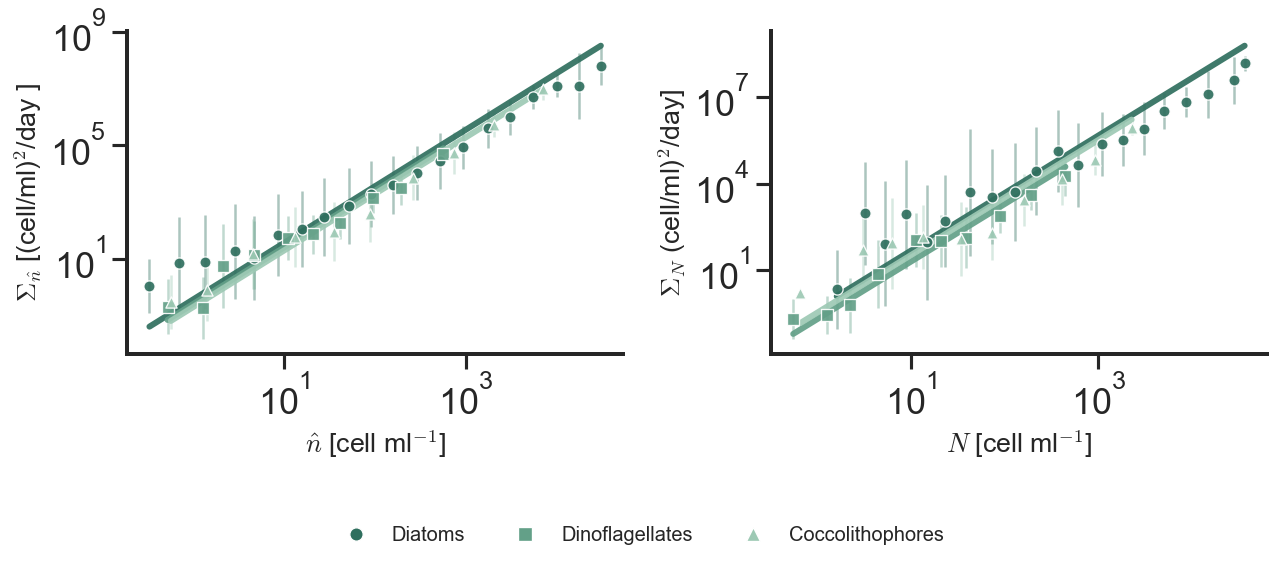

In [ ]:
df_sigma_sp_agg = pd.read_csv(FIG_MC_DIR / "Sigma_species_agg.csv")
df_sigma_tot_agg = pd.read_csv(FIG_MC_DIR / "Sigma_total_abundance_agg.csv")

group_names_mc = ["Diatoms", "Dinoflagellates", "Coccolithophores"]
MARECHIARA_GROUP_MARKERS = ["o", "s", "^"]

fig, (ax_sp, ax_tot) = plt.subplots(1, 2, figsize=(11, 4.5))

for j, group in enumerate(group_names_mc):
    color = MARECHIARA_GROUP_COLORS[group]
    marker = MARECHIARA_GROUP_MARKERS[j]
    
    df_sp = df_sigma_sp_agg[df_sigma_sp_agg['Group_Name'] == group]
    if not df_sp.empty:
        yerr_lower_sp = np.maximum(0, df_sp['y'] - df_sp['y_low'])
        yerr_upper_sp = np.maximum(0, df_sp['y_high'] - df_sp['y'])
        
        ax_sp.errorbar(df_sp['x'], df_sp['y'], yerr=[yerr_lower_sp, yerr_upper_sp], 
                       fmt='none', ecolor=color, alpha=0.4, elinewidth=1.5, zorder=1)
        
        ax_sp.scatter(df_sp['x'], df_sp['y'], color=color, marker=marker,
                      s=45, edgecolor="white", linewidth=0.8, alpha=0.92, zorder=3)
        
        intercepts = df_sp['intercept'].dropna().values
        if len(intercepts) > 0:
            intercept = intercepts[0]
            x_vals = np.logspace(np.log10(df_sp['x'].min()), np.log10(df_sp['x'].max()), 100)
            ax_sp.plot(x_vals, intercept * (x_vals**2), lw=3.6, color=color, alpha=0.92, zorder=2)

    df_tot = df_sigma_tot_agg[df_sigma_tot_agg['Group_Name'] == group]
    if not df_tot.empty:
        yerr_lower_tot = np.maximum(0, df_tot['y'] - df_tot['y_low'])
        yerr_upper_tot = np.maximum(0, df_tot['y_high'] - df_tot['y'])
        
        ax_tot.errorbar(df_tot['x'], df_tot['y'], yerr=[yerr_lower_tot, yerr_upper_tot], 
                        fmt='none', ecolor=color, alpha=0.4, elinewidth=1.5, zorder=1)
        
        ax_tot.scatter(df_tot['x'], df_tot['y'], color=color, marker=marker,
                       s=45, edgecolor="white", linewidth=0.8, alpha=0.92, zorder=3)
        
        intercepts = df_tot['intercept'].dropna().values
        if len(intercepts) > 0:
            intercept = intercepts[0]
            x_vals = np.logspace(np.log10(df_tot['x'].min()), np.log10(df_tot['x'].max()), 100)
            ax_tot.plot(x_vals, intercept * (x_vals**2), lw=3.6, color=color, alpha=0.92, zorder=2)

for ax, xlabel, ylabel in zip([ax_sp, ax_tot], 
                            [r"$\hat{n}$ [cell ml$^{-1}$]", r"$N$ [cell ml$^{-1}$]"], 
                            [r"$\Sigma_{\hat{n}}$ [(cell/ml)$^{2}$/day ]", r"$\Sigma_N$ (cell/ml)$^{2}$/day]"]):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    #ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

handles_g = [mlines.Line2D([], [], color=MARECHIARA_GROUP_COLORS[g], marker=MARECHIARA_GROUP_MARKERS[i], 
                          linestyle='None', markersize=8, markeredgecolor="white", markeredgewidth=0.8, label=g) for i, g in enumerate(group_names_mc)]

fig.legend(handles=handles_g, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=12)

fig.tight_layout(rect=[0, 0.05, 1, 1])

save_figure(fig, "Sigma_Species_Total_Aggregated_Panel", transparent=True)

plt.show()

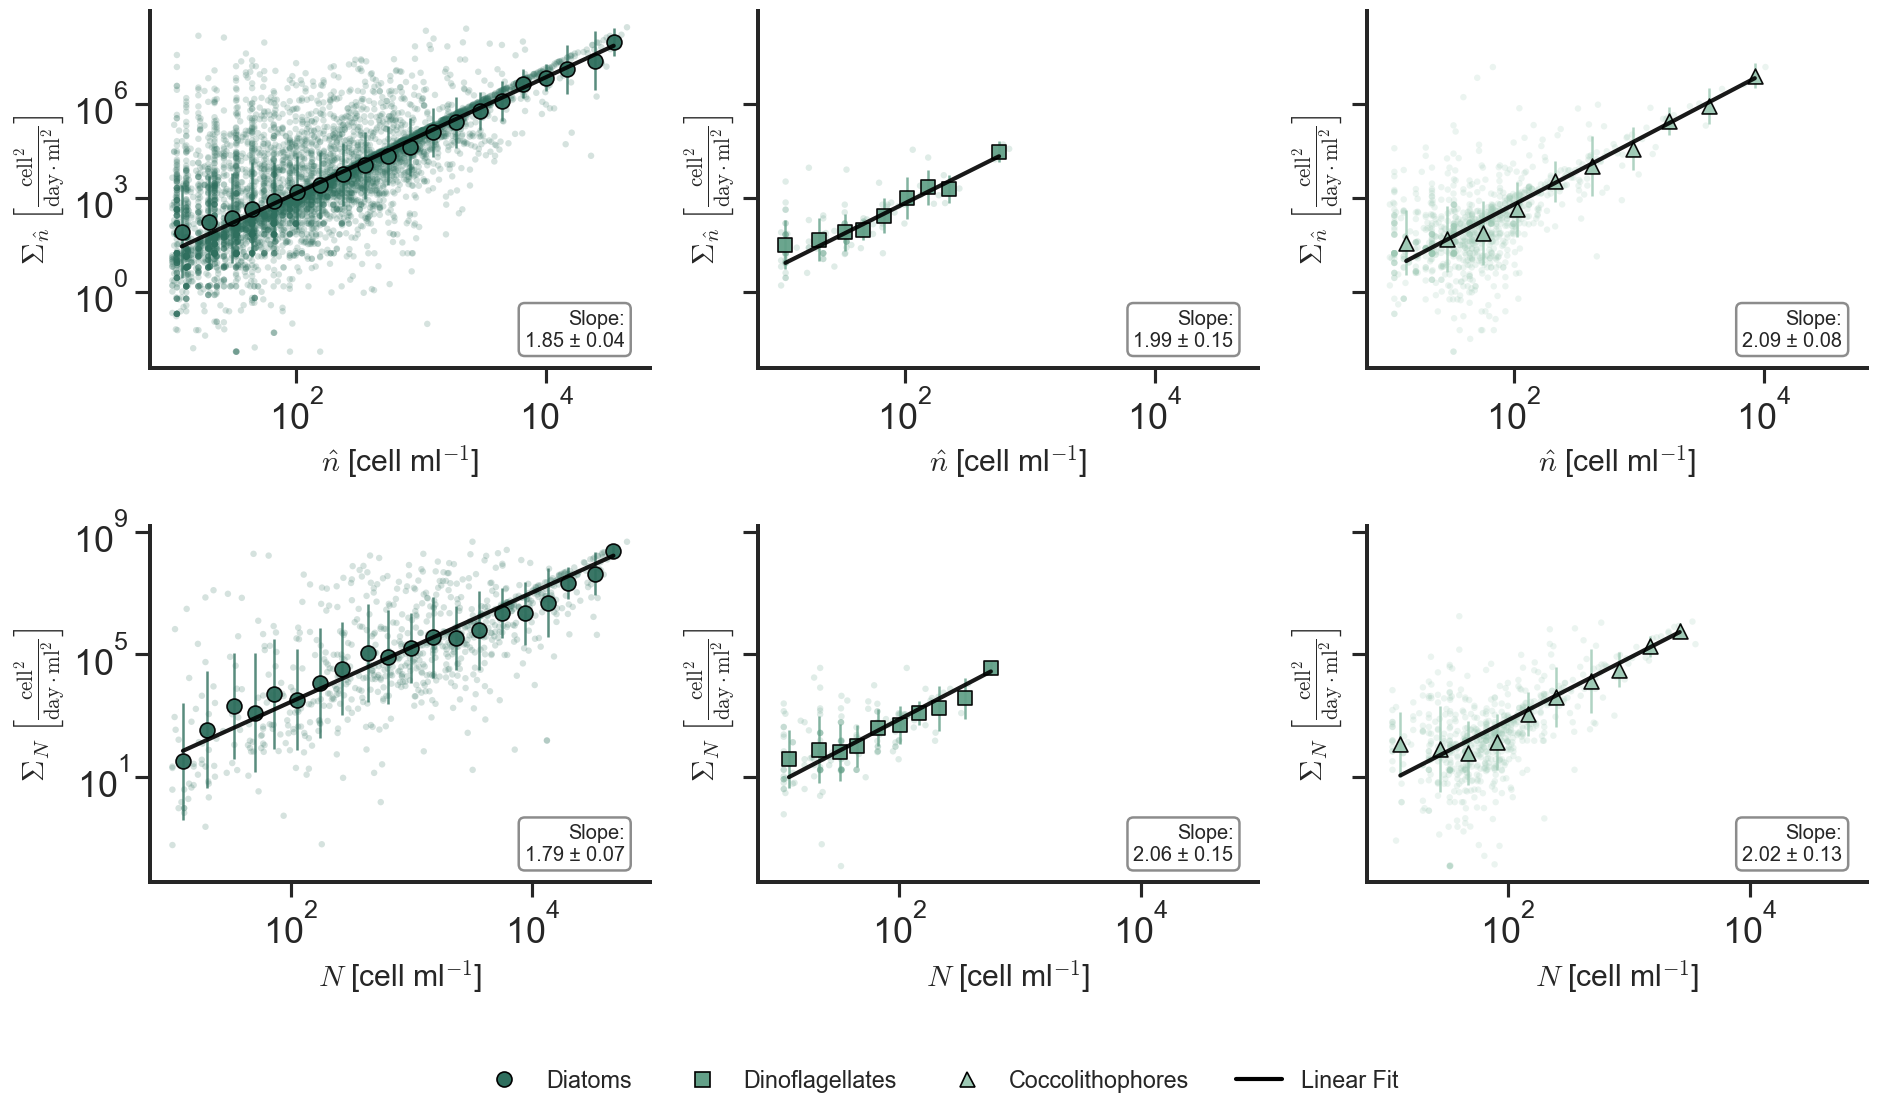

In [17]:
FIG_MC_DIR = DATA_DIR / "plot_MareChiara"

df_sp_raw = pd.read_csv(FIG_MC_DIR / "Sigma_species_raw.csv")
df_sp_binned = pd.read_csv(FIG_MC_DIR / "Sigma_species_binned.csv")
df_tot_raw = pd.read_csv(FIG_MC_DIR / "Sigma_total_raw.csv")
df_tot_binned = pd.read_csv(FIG_MC_DIR / "Sigma_total_binned.csv")
df_params = pd.read_csv(FIG_MC_DIR / "Sigma_fit_parameters.csv")

group_names_mc = ["Diatoms", "Dinoflagellates", "Coccolithophores"]
MARECHIARA_GROUP_MARKERS = ["o", "s", "^"]

with mpl.rc_context({"pdf.fonttype": 3}):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex='row', sharey='row')

    for j, group in enumerate(group_names_mc):
        color = MARECHIARA_GROUP_COLORS[group]
        marker = MARECHIARA_GROUP_MARKERS[j]
        
        ax_sp = axes[0, j]
        fit_text_sp = ["Slope:"]
        
        raw_sp = df_sp_raw[df_sp_raw['Group_Name'] == group]
        if not raw_sp.empty:
            ax_sp.scatter(raw_sp['x'], raw_sp['y'], color=color, alpha=0.2, s=15, edgecolor='none', zorder=1)
            
        bin_sp = df_sp_binned[df_sp_binned['Group_Name'] == group]
        if not bin_sp.empty:
            yerr_lower = np.maximum(0, bin_sp['y'] - bin_sp['y_low'])
            yerr_upper = np.maximum(0, bin_sp['y_high'] - bin_sp['y'])
            
            ax_sp.errorbar(bin_sp['x'], bin_sp['y'], yerr=[yerr_lower, yerr_upper], 
                           fmt='none', ecolor=color, alpha=0.8, elinewidth=1.5, zorder=2)
            
            ax_sp.scatter(bin_sp['x'], bin_sp['y'], color=color, marker=marker,
                          s=80, edgecolor="black", linewidth=1.0, alpha=0.95, zorder=3)
            
            param_row = df_params[(df_params['Group_Name'] == group) & (df_params['Type'] == 'Species')]
            if not param_row.empty:
                slope = param_row['slope'].values[0]
                slope_err = param_row['slope_err'].values[0]
                intercept = param_row['intercept'].values[0]
                
                if not np.isnan(slope) and not np.isnan(intercept):
                    x_vals = np.logspace(np.log10(bin_sp['x'].min()), np.log10(bin_sp['x'].max()), 100)
                    ax_sp.plot(x_vals, (10**intercept) * (x_vals**slope), lw=2.5, color='black', alpha=0.9, zorder=4)
                
                if not np.isnan(slope):
                    fit_text_sp.append(f"{slope:.2f} ± {slope_err:.2f}")
                else:
                    fit_text_sp.append("N/A")

        if len(fit_text_sp) > 1:
            ax_sp.text(0.95, 0.05, "\n".join(fit_text_sp), transform=ax_sp.transAxes, 
                       fontsize=12, verticalalignment='bottom', horizontalalignment='right', zorder=10,
                       bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.9))

        ax_sp.set_xscale('log')
        ax_sp.set_yscale('log')
        #ax_sp.grid(True, alpha=0.3)
        sns.despine(ax=ax_sp)

        ax_tot = axes[1, j]
        fit_text_tot = ["Slope:"]
        
        raw_tot = df_tot_raw[df_tot_raw['Group_Name'] == group]
        if not raw_tot.empty:
            ax_tot.scatter(raw_tot['x'], raw_tot['y'], color=color, alpha=0.2, s=15, edgecolor='none', zorder=1)
            
        bin_tot = df_tot_binned[df_tot_binned['Group_Name'] == group]
        if not bin_tot.empty:
            yerr_lower_tot = np.maximum(0, bin_tot['y'] - bin_tot['y_low'])
            yerr_upper_tot = np.maximum(0, bin_tot['y_high'] - bin_tot['y'])
            
            ax_tot.errorbar(bin_tot['x'], bin_tot['y'], yerr=[yerr_lower_tot, yerr_upper_tot], 
                            fmt='none', ecolor=color, alpha=0.8, elinewidth=1.5, zorder=2)
            
            ax_tot.scatter(bin_tot['x'], bin_tot['y'], color=color, marker=marker,
                           s=80, edgecolor="black", linewidth=1.0, alpha=0.95, zorder=3)
            
            param_row_tot = df_params[(df_params['Group_Name'] == group) & (df_params['Type'] == 'Total')]
            if not param_row_tot.empty:
                slope = param_row_tot['slope'].values[0]
                slope_err = param_row_tot['slope_err'].values[0]
                intercept = param_row_tot['intercept'].values[0]
                
                if not np.isnan(slope) and not np.isnan(intercept):
                    x_vals = np.logspace(np.log10(bin_tot['x'].min()), np.log10(bin_tot['x'].max()), 100)
                    ax_tot.plot(x_vals, (10**intercept) * (x_vals**slope), lw=2.5, color='black', alpha=0.9, zorder=4)
                
                if not np.isnan(slope):
                    fit_text_tot.append(f"{slope:.2f} ± {slope_err:.2f}")
                else:
                    fit_text_tot.append("N/A")

        if len(fit_text_tot) > 1:
            ax_tot.text(0.95, 0.05, "\n".join(fit_text_tot), transform=ax_tot.transAxes, 
                        fontsize=12, verticalalignment='bottom', horizontalalignment='right', zorder=10,
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.9))

        ax_tot.set_xscale('log')
        ax_tot.set_yscale('log')
        #ax_tot.grid(True, alpha=0.3)
        sns.despine(ax=ax_tot)

    for i in range(3):
        axes[0, i].set_xlabel(r"$\hat{n}$ [cell ml$^{-1}$]", fontsize=18)
        axes[1, i].set_xlabel(r"$N$ [cell ml$^{-1}$]", fontsize=18)
        axes[0, i].set_ylabel(r"$\Sigma_{\hat{n}} \; \left[ \frac{\mathrm{cell}^{2}}{\mathrm{day} \cdot \mathrm{ml}^{2}} \right]$", fontsize=18)
        axes[1, i].set_ylabel(r"$\Sigma_N \; \left[ \frac{\mathrm{cell}^{2}}{\mathrm{day} \cdot \mathrm{ml}^{2}} \right]$", fontsize=18)

    handles_g = [mlines.Line2D([], [], color=MARECHIARA_GROUP_COLORS[g], marker=MARECHIARA_GROUP_MARKERS[i], 
                               linestyle='None', markersize=9, markeredgecolor="black", markeredgewidth=1.0, label=g) for i, g in enumerate(group_names_mc)]
    handles_fit = [mlines.Line2D([], [], color='black', lw=2.5, linestyle='-', label='Linear Fit')]
    
    fig.legend(handles=handles_g + handles_fit, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, fontsize=14)

    fig.tight_layout(rect=[0, 0.03, 1, 1])

    save_figure(fig, "Sigma_Species_Total_Macroplot_Panel", transparent=True)

    plt.show()

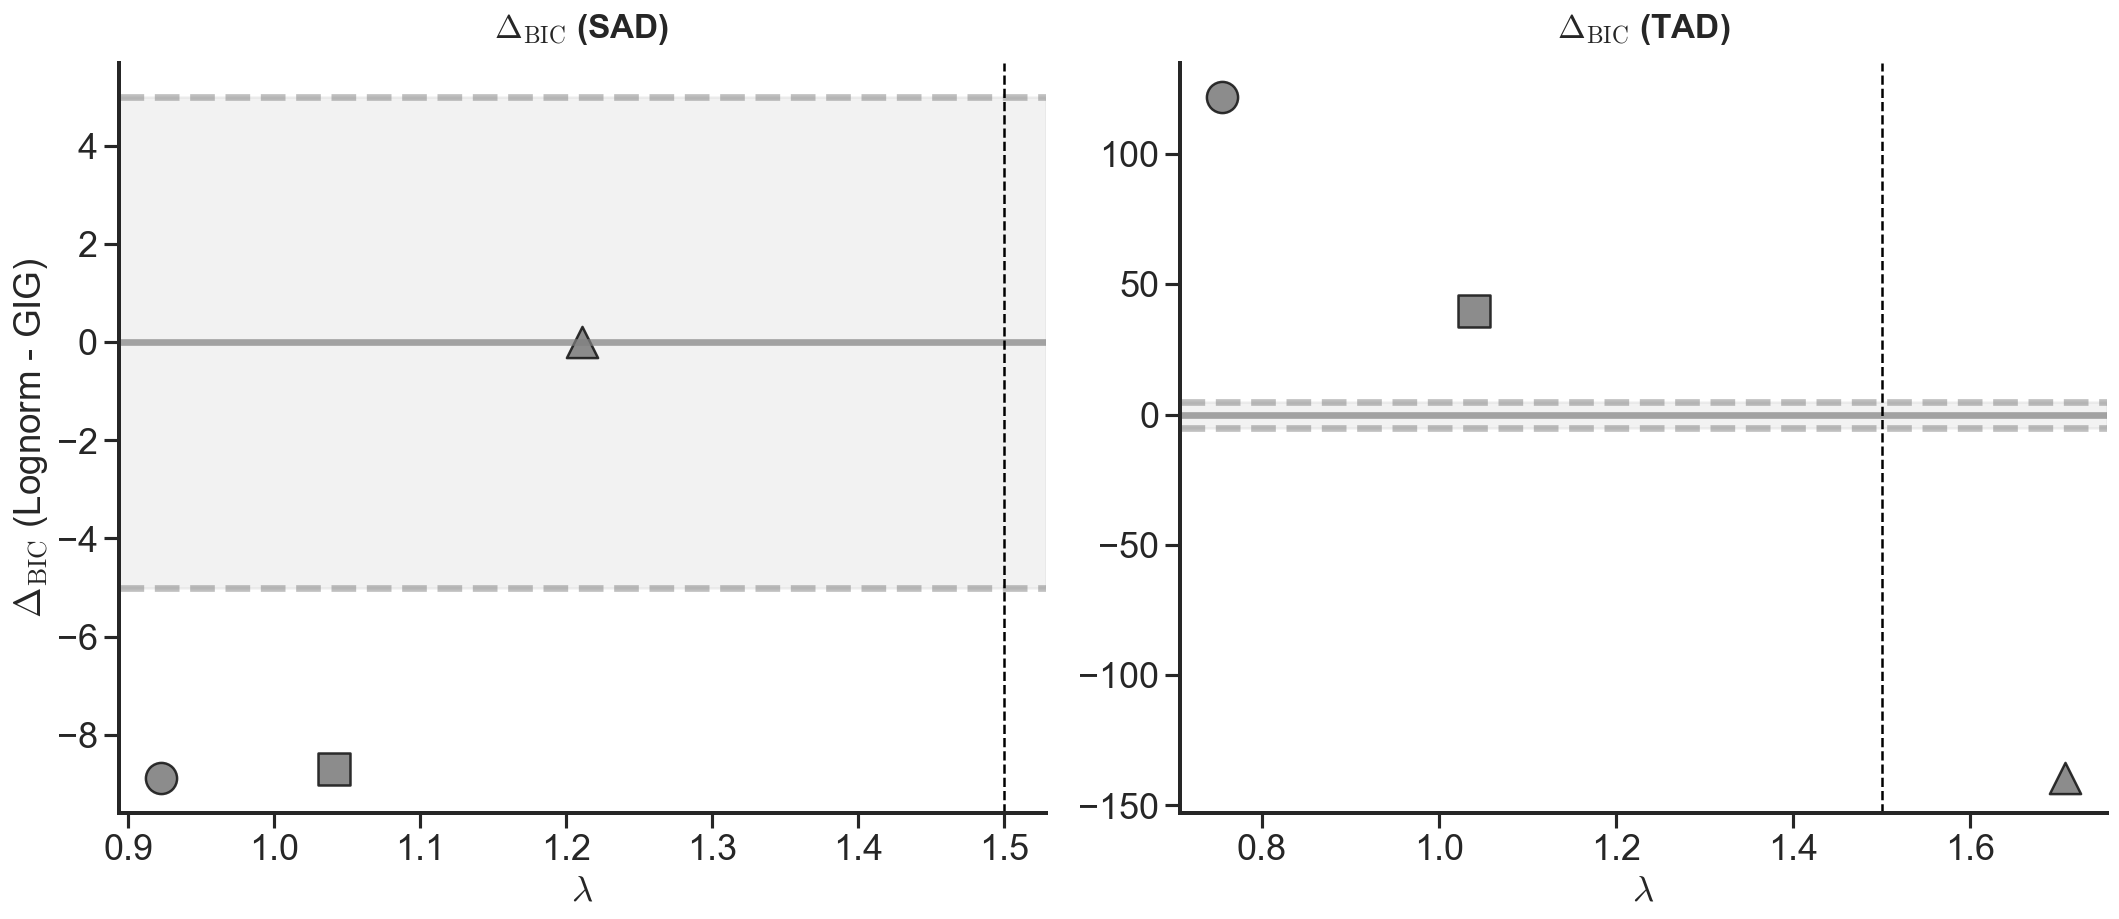

In [ ]:
df_params_agg = pd.read_csv(FIG_MC_DIR / "paramateres_Marechiara_agg.csv")

if 'group_markers' not in globals():
    group_markers = ["o", "s", "^", "D", "v"]

with mpl.rc_context({"pdf.fonttype": 3}):
    fig_bic_agg, axes_bic_agg = plt.subplots(1, 2, figsize=(18, 8))
    ax_bic_sad_agg, ax_bic_tad_agg = axes_bic_agg
    
    for _, row in df_params_agg.iterrows():
        j = int(row['Group_ID'])
        mk = group_markers[j % len(group_markers)]
        s = 350
        
        if pd.notna(row['bic_SAD_lognorm']) and pd.notna(row['bic_SAD_gig']):
            delta_sad = row['bic_SAD_lognorm'] - row['bic_SAD_gig']
            ax_bic_sad_agg.scatter(row['lambda_SAD_gig'], delta_sad, color='gray', marker=mk, s=s, alpha=0.9, edgecolors='k', linewidths=1.5)
            
        if pd.notna(row['bic_TAD_lognorm']) and pd.notna(row['bic_TAD_gig']):
            delta_tad = row['bic_TAD_lognorm'] - row['bic_TAD_gig']
            ax_bic_tad_agg.scatter(row['lambda_TAD_gig'], delta_tad, color='gray', marker=mk, s=s, alpha=0.9, edgecolors='k', linewidths=1.5)

    for ax, title in zip([ax_bic_sad_agg, ax_bic_tad_agg], [r"$\Delta_{\mathrm{BIC}}$ (SAD)", r"$\Delta_{\mathrm{BIC}}$ (TAD)"]):
        ax.axhspan(-5, 5, color='gray', alpha=0.1, zorder=0)
        ax.axhline(5, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(0, color='gray', linestyle='-', alpha=0.7)
        ax.axhline(-5, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(1.5, color='black', linestyle='--', linewidth=1.5)
        ax.set_xlabel(r"$\lambda$", fontsize=22)
        ax.set_title(title, fontsize=20, fontweight='bold', pad=15)
        #ax.grid(True, alpha=0.3)
        sns.despine(ax=ax)

    ax_bic_sad_agg.set_ylabel(r"$\Delta_{\mathrm{BIC}}$ (Lognorm - GIG)", fontsize=22)
    
    fig_bic_agg.tight_layout() 
    
    save_figure(fig_bic_agg, "fig_DeltaBIC_Aggregated", transparent=True)
        
    plt.show()

# Fig SM Tara

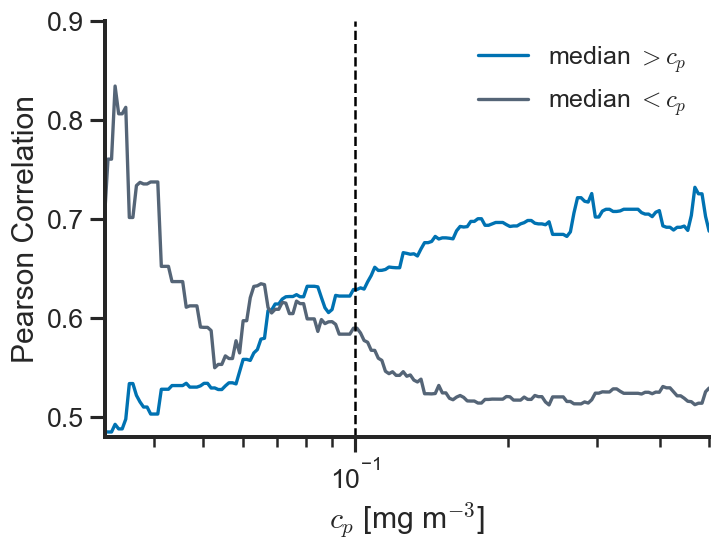

In [ ]:
FIG_T_DIR = DATA_DIR / "plot_Tara"

df_valid = pd.read_feather(FIG_T_DIR / "patch.feather")

c_main = '#0072B2'
c_second = '#556577'

cuts = np.logspace(np.log10(1/50), np.log10(1/2), 200)

valid_cuts_greater = []
corr_greater = []

valid_cuts_lesser = []
corr_lesser = []

for cut in cuts:
    mask_finite = np.isfinite(df_valid['p_slope']) & np.isfinite(np.log10(df_valid['xi_acf']))
    
    subset_g = df_valid[(df_valid['median'] > cut) & mask_finite]
    if len(subset_g) >= 5:
        corr_g, _ = pearsonr(subset_g['p_slope'], np.log10(subset_g['xi_acf']))
        valid_cuts_greater.append(cut)
        corr_greater.append(corr_g)
        
    subset_l = df_valid[(df_valid['median'] < cut) & mask_finite]
    if len(subset_l) >= 5:
        corr_l, _ = pearsonr(subset_l['p_slope'], np.log10(subset_l['xi_acf']))
        valid_cuts_lesser.append(cut)
        corr_lesser.append(corr_l)


fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.plot(valid_cuts_greater, corr_greater, color=c_main, lw=2, label=r'median $> c_p$')
ax.plot(valid_cuts_lesser, corr_lesser, color=c_second, lw=2, label=r'median $< c_p$')

ax.set_xscale('log')
ax.set(
    xlabel=r'$c_p$ [mg m$^{-3}$]', 
    ylabel='Pearson Correlation'
)

ax.axvline(x=0.1, color='black', linestyle='--', linewidth=1.5)
ax.set_ylim([0.48, 0.9])
ax.set_xlim([0.032, 0.5])

style_figure2_axis(ax)

ax.grid(False)
sns.despine(ax=ax)

ax.legend(frameon=False, loc='best', fontsize=15, markerscale=0.9)

save_figure(fig, "fig_tara_C", folder=FIGURE_DIR)

plt.show()

In [29]:
thr = 10 / 100  

df_valid['group'] = np.where(df_valid['median'] > thr, 'Main (> cut)', 'Minor (<= cut)')

df_main = df_valid[df_valid['median'] > thr].copy()
df_minor = df_valid[df_valid['median'] <= thr].copy()

print(f"MAIN (median > cut):  {len(df_main)}")
print(f"MINOR (median <= cut): {len(df_minor)}")
print(f"Total: {len(df_valid)}")


MAIN (median > cut):  187
MINOR (median <= cut): 95
Total: 282


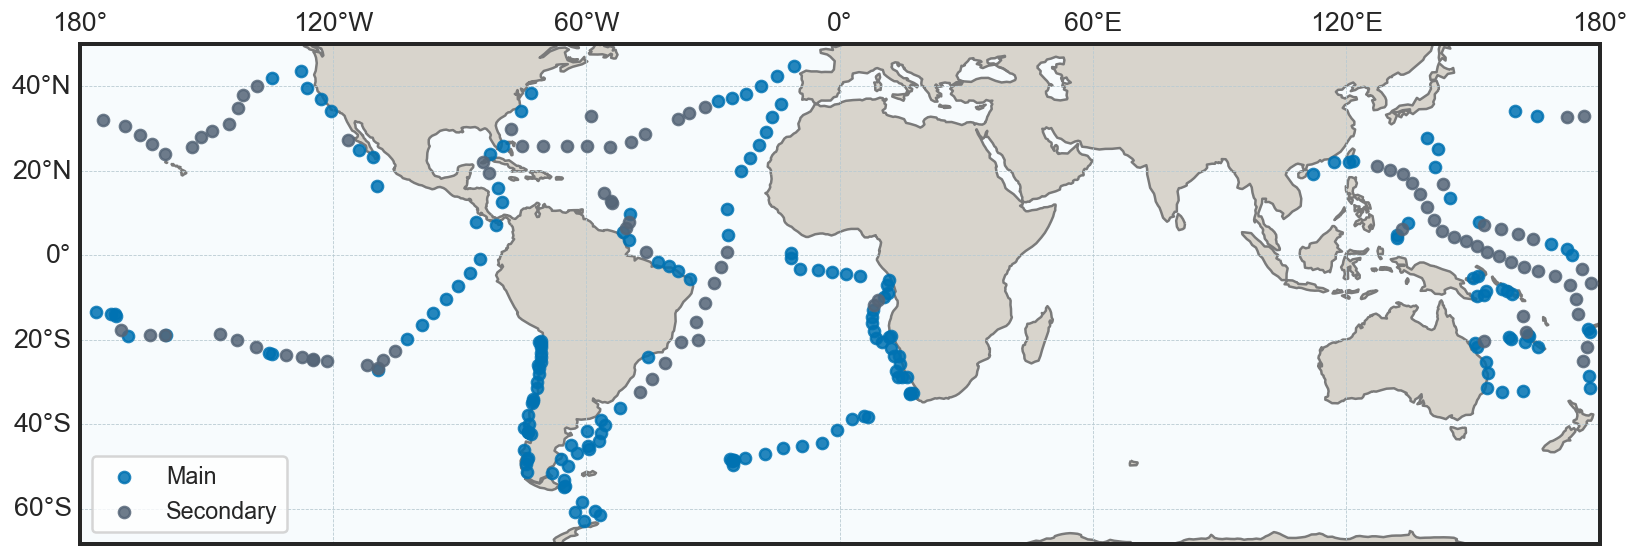

In [38]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


c_main = '#0072B2'
c_second = '#556577'

projection = ccrs.PlateCarree(central_longitude=0)
fig, ax = plt.subplots(figsize=(14, 6), subplot_kw=dict(projection=projection))
ax.set_facecolor(MAP_OCEAN)
ax.add_feature(cfeature.LAND, facecolor=MAP_LAND)
ax.add_feature(cfeature.COASTLINE, edgecolor=MAP_COAST)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=0.5, color=MAP_GRID, linestyle='--'
)

gl.top_labels = True
gl.bottom_labels = False
gl.left_labels = True
gl.right_labels = False 


gl.xlabel_style = {'size': FIG2_TICK_SIZE}
gl.ylabel_style = {'size': FIG2_TICK_SIZE}

ax.scatter(
    df_main['lon'], df_main['lat'], 
    transform=ccrs.PlateCarree(),
    color=c_main, s=45, alpha=0.85, label='Main',
    zorder=5  # Forza i punti in primo piano rispetto alla mappa
)

ax.scatter(
    df_minor['lon'], df_minor['lat'], 
    transform=ccrs.PlateCarree(),
    color=c_second, s=45, alpha=0.85, label='Secondary',
    zorder=5
)


style_figure2_axis(ax)


ax.legend(loc='lower left', frameon=True, fontsize=FIG2_LEGEND_SIZE)

plt.tight_layout()

save_figure(fig, "fig_tara_A", folder=FIGURE_DIR)

plt.show()

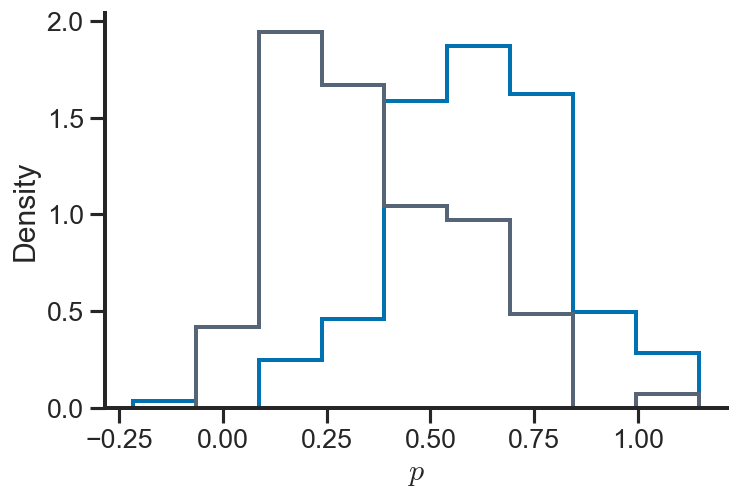

In [69]:
min_val = min(df_main['p_slope'].min(), df_minor['p_slope'].min())
max_val = max(df_main['p_slope'].max(), df_minor['p_slope'].max())
bins = np.linspace(min_val, max_val, 10)

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.hist(
    df_main['p_slope'], 
    bins=bins, 
    density=True, 
    histtype='step',
    color=c_main, 
    label='Main', 
    linewidth=2.4
)

ax.hist(
    df_minor['p_slope'], 
    bins=bins, 
    density=True, 
    histtype='step',
    color=c_second, 
    label='Secondary', 
    linewidth=2.4
)

ax.set(xlabel="$p$", ylabel="Density")

style_figure2_axis(ax) 

sns.despine(ax=ax)
ax.grid(False)

#ax.legend(frameon=False, loc='best', fontsize=FIG2_LEGEND_SIZE)

plt.tight_layout()

save_figure(fig, "fig_tara_E", folder=FIGURE_DIR)

plt.show()

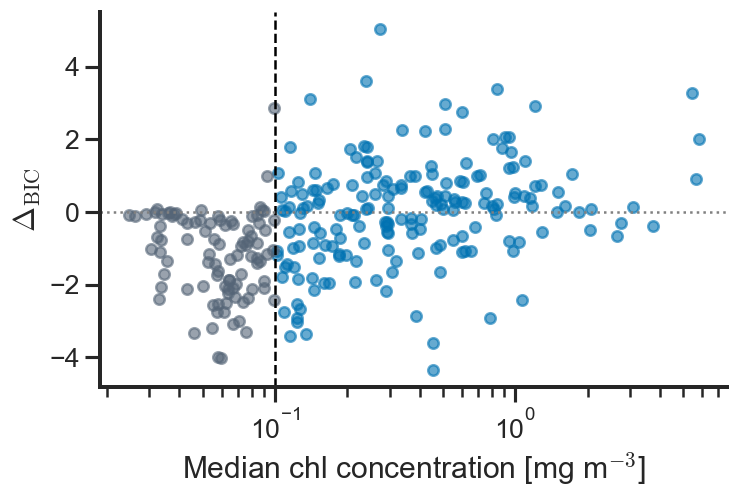

In [45]:

df_main["Delta_ll"] = df_main["ll_pat"] - df_main["ll_linear"]
df_minor["Delta_ll"] = df_minor["ll_pat"] - df_minor["ll_linear"]

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    df_main["median"], 2 * df_main["Delta_ll"], 
    color=c_main, alpha=0.6, s=40, label='Main'
)

ax.scatter(
    df_minor["median"], 2 * df_minor["Delta_ll"], 
    color=c_second, alpha=0.6, s=40, label='Secondary'
)

ax.set_xscale('log')

ax.axvline(x=0.1, color='black', linestyle='--', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle=':', linewidth=1.5)

ax.set(
    xlabel=r"Median chl concentration [mg m$^{-3}$]", 
    ylabel=r"$\Delta_{\mathrm{BIC}}$"
)

style_figure2_axis(ax)
ax.grid(False)
sns.despine(ax=ax)

plt.tight_layout()

save_figure(fig, "fig_tara_B", folder=FIGURE_DIR)

plt.show()

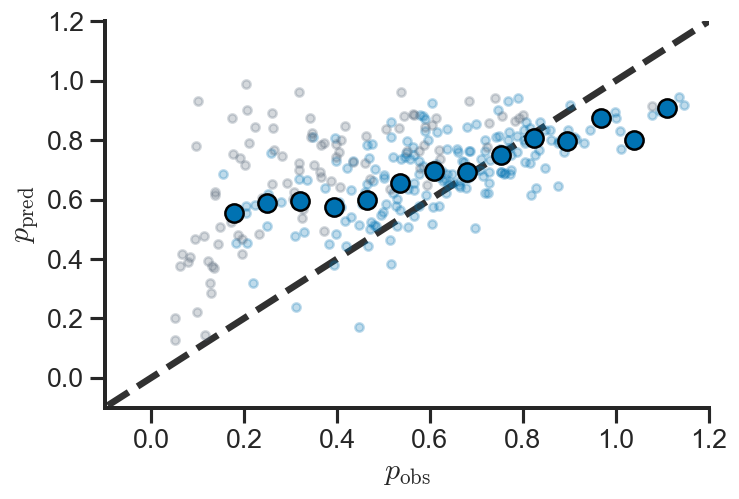

In [46]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
from scipy.stats import binned_statistic


ax.scatter(
    df_main["p_slope"], df_main["p_theoretical"], 
    color=c_main, alpha=0.25, s=25
)
ax.scatter(
    df_minor["p_slope"], df_minor["p_theoretical"], 
    color=c_second, alpha=0.25, s=25
)

bins = np.linspace(np.min(df_main["p_slope"]), np.max(df_main["p_slope"]), 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

med_main, _, _ = binned_statistic(
    df_main["p_slope"], df_main["p_theoretical"], 
    statistic='median', bins=bins
)

ax.scatter(
    bin_centers, med_main, 
    color=c_main, s=120, edgecolors='black', zorder=10
)

lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
ax.plot(lims, lims, 'k--', alpha=0.9, zorder=0)

ax.set(xlabel=r"$p_{\mathrm{obs}}$", ylabel=r"$p_{\mathrm{pred}}$")
ax.set_xlim([-0.1, 1.2])
ax.set_ylim([-0.1, 1.2])

style_figure2_axis(ax)
ax.grid(False)
sns.despine(ax=ax)

plt.tight_layout()

save_figure(fig, "fig_tara_D", folder=FIGURE_DIR)

plt.show()

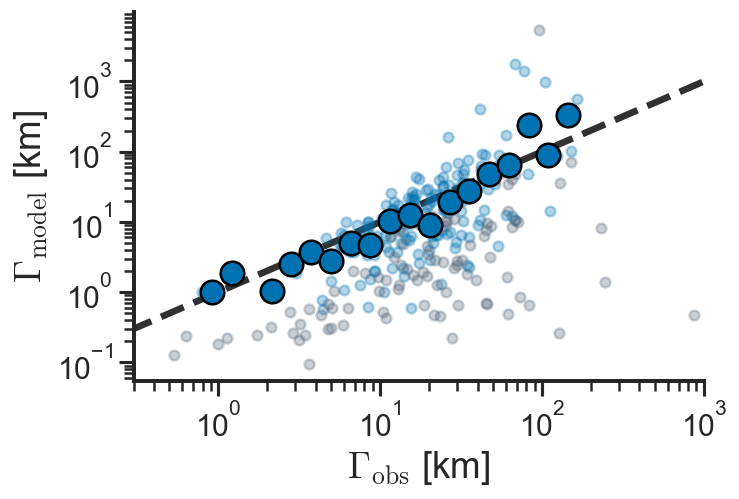

In [42]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    df_main["xi_acf"] * 0.2, df_main["gamma_hat"] * 0.2, 
    color=c_main, alpha=0.3, s=35
)
ax.scatter(
    df_minor["xi_acf"] * 0.2, df_minor["gamma_hat"] * 0.2, 
    color=c_second, alpha=0.3, s=35
)
bins = np.logspace(
    np.log10(np.min(df_main["xi_acf"] * 0.2)), 
    np.log10(np.max(df_main["xi_acf"] * 0.2)), 
    20
)
bin_centers = (bins[:-1] + bins[1:]) / 2

med_main, _, _ = binned_statistic(
    df_main["xi_acf"] * 0.2, df_main["gamma_hat"] * 0.2, 
    statistic='median', bins=bins
)
med_minor, _, _ = binned_statistic(
    df_minor["xi_acf"] * 0.2, df_minor["gamma_hat"] * 0.2, 
    statistic='median', bins=bins
)
ax.scatter(bin_centers, med_main, color=c_main, s=200, edgecolors='black', zorder=10)

lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
ax.plot(lims, lims, 'k--', alpha=0.9, zorder=0)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([3/10, 1000])

ax.set(xlabel=r"$\Gamma_{\mathrm{obs}}$ [km]", ylabel=r"$\Gamma_{\mathrm{model}}$ [km]")

style_figure2_axis(ax)

ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)
ax.tick_params(axis="both", labelsize=18)

ax.grid(False)
sns.despine(ax=ax)

plt.tight_layout()

save_figure(fig, "fig_tara_subD", folder=FIGURE_DIR)

plt.show()

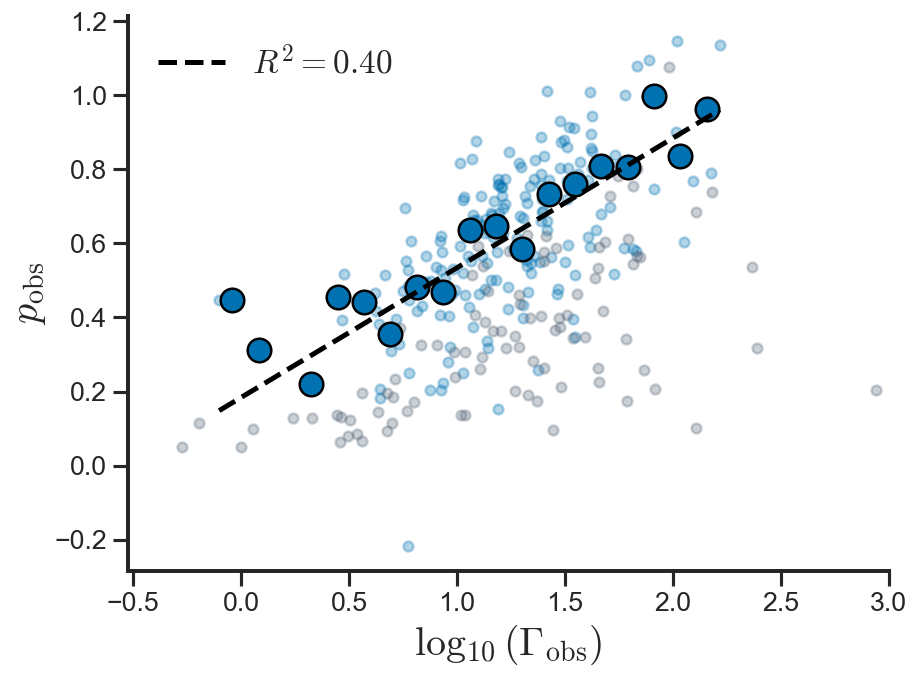

In [67]:
fig, ax = plt.subplots(figsize=(8, 6))

log_gamma_main = np.log10(df_main["xi_acf"] * 0.2)
log_gamma_minor = np.log10(df_minor["xi_acf"] * 0.2)

ax.scatter(
    log_gamma_main, df_main["p_slope"], 
    color=c_main, alpha=0.3, s=35
)
ax.scatter(
    log_gamma_minor, df_minor["p_slope"], 
    color=c_second, alpha=0.3, s=35
)

bins = np.linspace(np.min(log_gamma_main), np.max(log_gamma_main), 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
med_main, _, _ = binned_statistic(
    log_gamma_main, df_main["p_slope"], 
    statistic='median', bins=bins
)
slope, intercept, r_value, p_value, std_err = linregress(log_gamma_main, df_main["p_slope"])

x_fit = np.linspace(log_gamma_main.min(), log_gamma_main.max(), 100)
y_fit = intercept + slope * x_fit

ax.plot(
    x_fit, y_fit, 
    color='black', linestyle='--', linewidth=3, zorder=15, 
    label=rf'$R^2={r_value**2:.2f}$'
)

ax.scatter(bin_centers, med_main, color=c_main, s=200, edgecolors='black', zorder=10)
ax.set(xlabel=r"$\log_{10}(\Gamma_{\mathrm{obs}})$", ylabel=r"$p_{\mathrm{obs}}$")
ax.set_xlim([np.log10(3/10), np.log10(1000)])
style_figure2_axis(ax)
ax.legend(frameon=False, loc='best', fontsize=20)
ax.xaxis.label.set_size(24)
ax.yaxis.label.set_size(24)
ax.grid(False)
sns.despine(ax=ax)

plt.tight_layout()

save_figure(fig, "fig_tara_corr", folder=FIGURE_DIR)

plt.show()

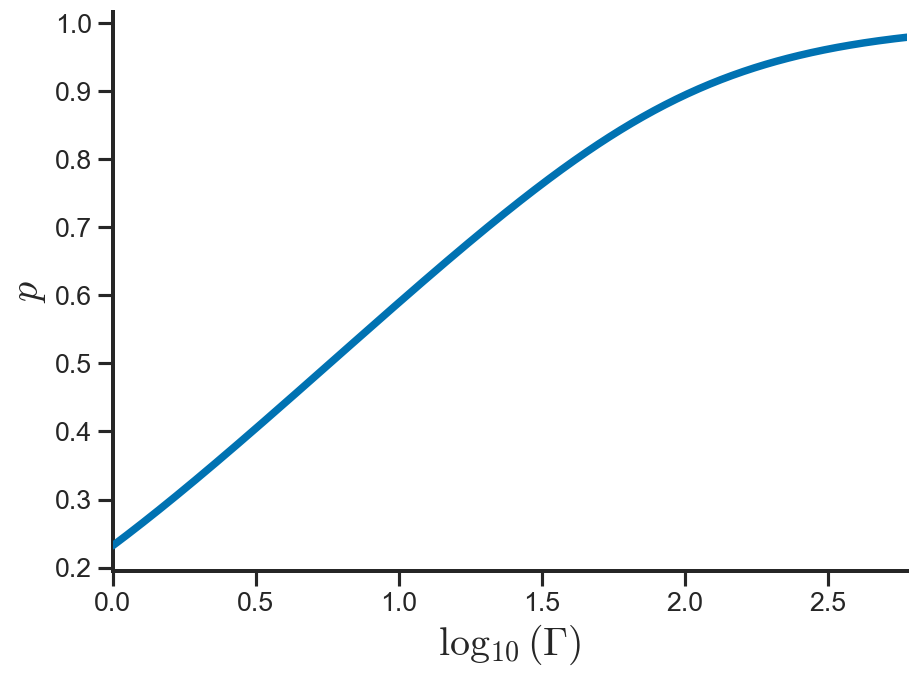

In [66]:
def V_func(Gamma, L):
    z = L / Gamma
    return 1 - (2 / z) * (1 - (1 - np.exp(-z)) / z)

def p_theoretical(Gamma, L):
    return (np.log10(V_func(Gamma, L)) - np.log10(V_func(Gamma, 1))) / np.log10(L)

L_val = 300
y_min = 0
y_max = np.log10(600)

y = np.linspace(y_min, y_max, 500)

Gamma_array = 10**y
p_vals = p_theoretical(Gamma_array, L_val)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    y, p_vals, 
    color=c_main, 
    linewidth=4.5, 
    zorder=10
)

ax.set(xlabel=r"$\log_{10}(\Gamma)$", ylabel=r"$p$")
ax.set_xlim([y_min, y_max])

style_figure2_axis(ax)
ax.xaxis.label.set_size(24)
ax.yaxis.label.set_size(24)
ax.grid(False)
sns.despine(ax=ax)

plt.tight_layout()

save_figure(fig, "theoretical_p_curve", folder=FIGURE_DIR)

plt.show()

SM transition GIG - Lognormal

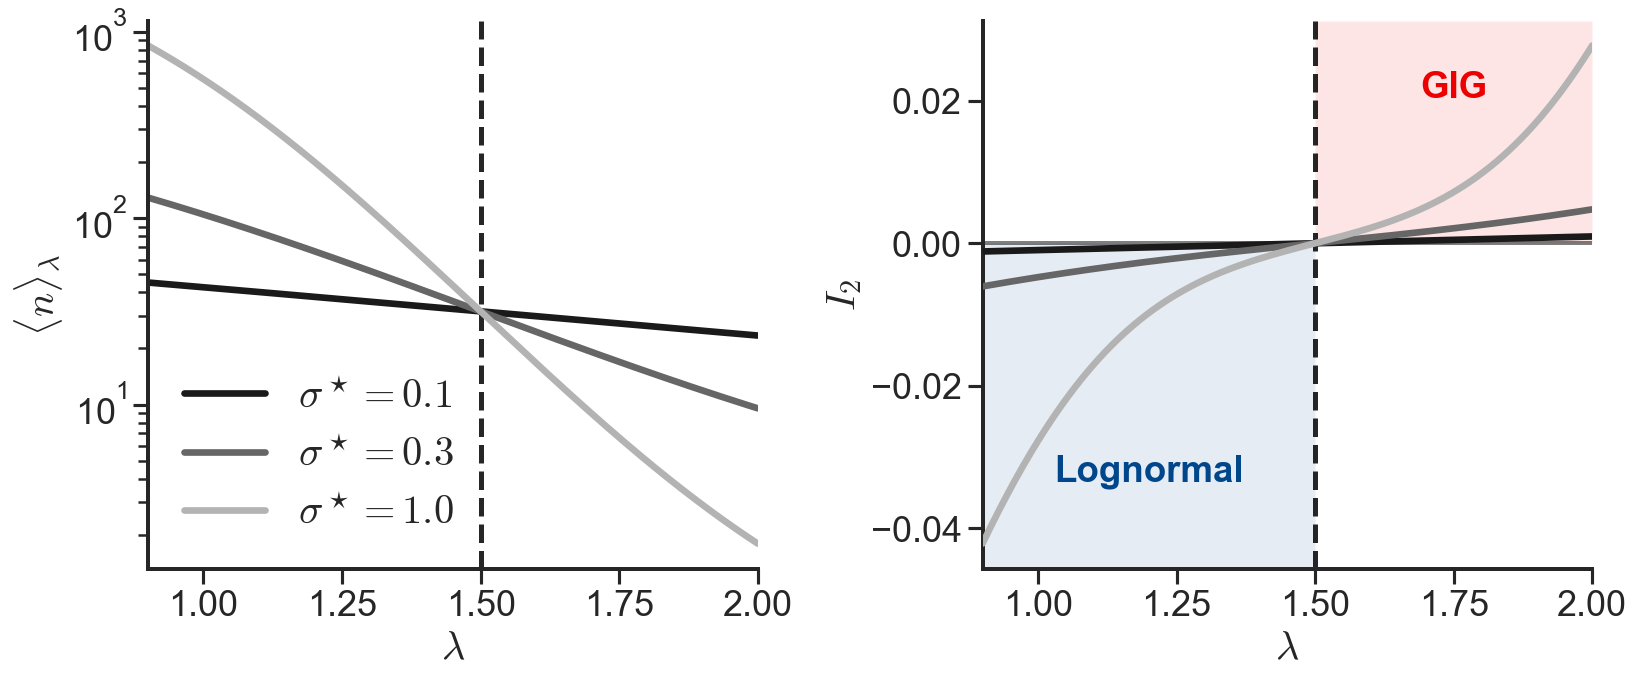

In [12]:
from scipy.special import kv

def M1(b0, k, s, lam):
    z = (4 * np.sqrt(b0 * k)) / (s**2)
    num = b0 * kv(lam - 2, z)
    den = np.sqrt(b0 * k) * kv(lam - 1, z)
    return num / den

def R(b0, k, s, lam):
    m1_val = M1(b0, k, s, lam)
    return (b0 - k * m1_val**2) / (2 * m1_val)

b0 = 0.1
k = 1/10000
s_values = [0.1, 0.3, 1.0]

gray_colors = ['#1A1A1A', '#666666', '#B3B3B3']

color_lognormal = '#00468B'
color_gig = '#ED0000'

lam = np.linspace(0.9, 2.0, 300)

with mpl.rc_context({"pdf.fonttype": 3}):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    for s, color in zip(s_values, gray_colors):
        ax1.plot(lam, M1(b0, k, s, lam), color=color, label=fr'$\sigma^\star = {s}$')

    ax1.axvline(x=1.5, color="black", lw=3, ls="--", alpha=0.85, zorder=0)

    ax1.set_yscale('log')
    ax1.set(xlabel=r'$\lambda$', ylabel=r'$\langle n \rangle_{\lambda}$', xlim=(0.9, 2.0))
    
    ax1.legend(loc='lower left', frameon=False)

    for s, color in zip(s_values, gray_colors):
        ax2.plot(lam, R(b0, k, s, lam), color=color, zorder=3)

    ymin, ymax = ax2.get_ylim()

    ax2.fill_between([1.5, 2.0], 0, ymax, facecolor=color_gig, alpha=0.1, zorder=-1)
    ax2.fill_between([0.9, 1.5], ymin, 0, facecolor=color_lognormal, alpha=0.1, zorder=-1)

    ax2.text(1.75, ymax * 0.7, 'GIG', color=color_gig, fontsize=22, fontweight='bold', ha='center', va='center', zorder=2)
    ax2.text(1.2, ymin * 0.7, 'Lognormal', color=color_lognormal, fontsize=22, fontweight='bold', ha='center', va='center', zorder=2)

    ax2.set_ylim(ymin, ymax)
    ax2.set_xlim(0.9, 2.0)

    ax2.axhline(0, color="black", lw=2.4, ls="-", alpha=0.5, zorder=1) 
    ax2.axvline(x=1.5, color="black", lw=3, ls="--", alpha=0.85, zorder=0)

    ax2.set(xlabel=r'$\lambda$', ylabel=r'$I_2$')

    sns.despine(ax=ax1)
    sns.despine(ax=ax2)

    plt.tight_layout()
    
    saved_paths = save_figure(fig, "transition_lambda", folder=FIGURE_DIR)


# Simulation plots

In [20]:
FIG_METHODS = DATA_DIR / "plot_Simulations"

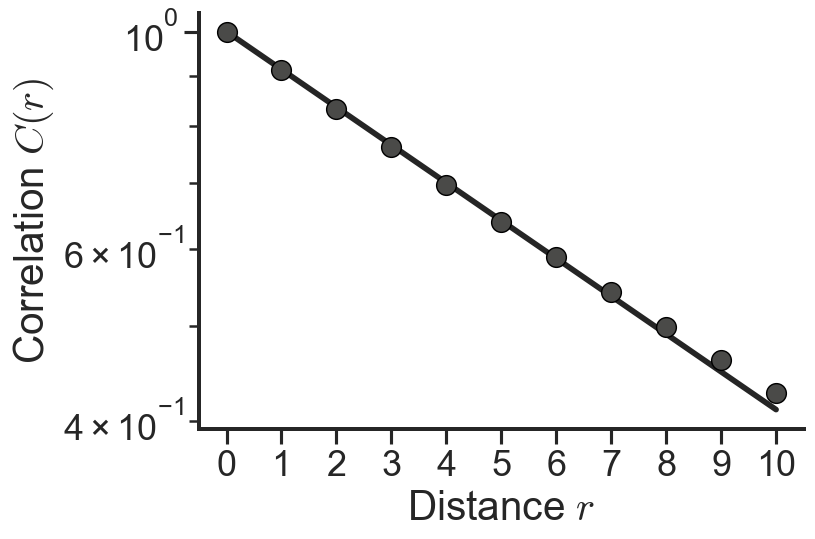

In [41]:
df_coords = pd.read_csv(FIG_METHODS / "acf_coordinates.csv")

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.plot(
    df_coords["Lag_X"],
    df_coords["ACF_Theoretical_Y"],
    color="#252525",
    lw=3.4,
    zorder=2,
    label="Theory"
)

ax.scatter(
    df_coords["Lag_X"],
    df_coords["ACF_Empirical_Y"],
    s=140,
    marker="o",
    color="#4a4a48",
    alpha=1.0,
    edgecolors="black",
    linewidths=0.85,
    zorder=5,
    label="Simulations"
)

ax.set_yscale("log")
ax.set_xlabel(r"Distance $r$")
ax.set_ylabel(r"Correlation $C(r)$")
ax.set_xticks(df_coords["Lag_X"].dropna().unique())

sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig5_panelA", folder=FIGURE_DIR, transparent=True)

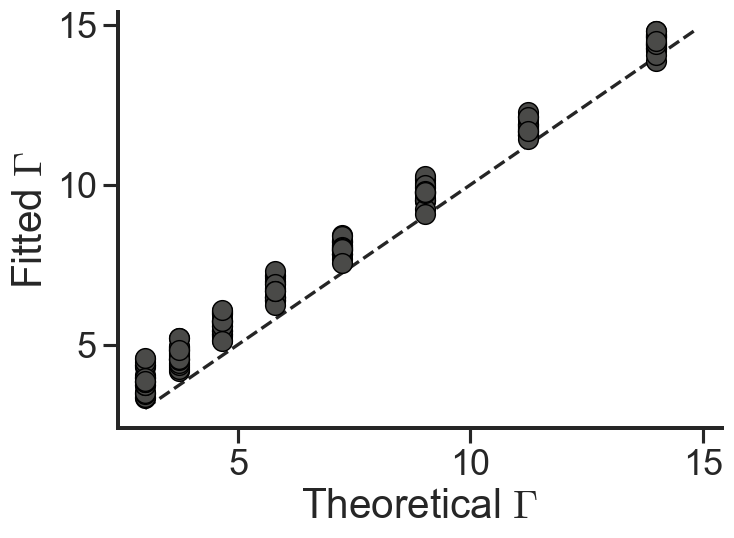

In [ ]:


df = pd.read_pickle(FIG_METHODS / "analysis_results.pkl")

mask_gamma = df["gamma_theoretical"].notna() & df["gamma_fit"].notna()
data = df.loc[mask_gamma].copy()

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    data["gamma_theoretical"],
    data["gamma_fit"],
    s=140,
    marker="o",
    color="#4a4a48",
    alpha=1.0,
    edgecolors="black",
    linewidths=0.85,
    zorder=5,
    label="Fitted vs Theoretical"
)

if not data.empty:
    min_val = min(data["gamma_theoretical"].min(), data["gamma_fit"].min())
    max_val = max(data["gamma_theoretical"].max(), data["gamma_fit"].max())
    
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="#252525",
        linestyle="--",
        lw=2.0,
        zorder=2,
        label="y = x"
    )

ax.set_xlabel(r"Theoretical $\Gamma$")
ax.set_ylabel(r"Fitted $\Gamma$")

sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig5_panelB", folder=FIGURE_DIR, transparent=True)

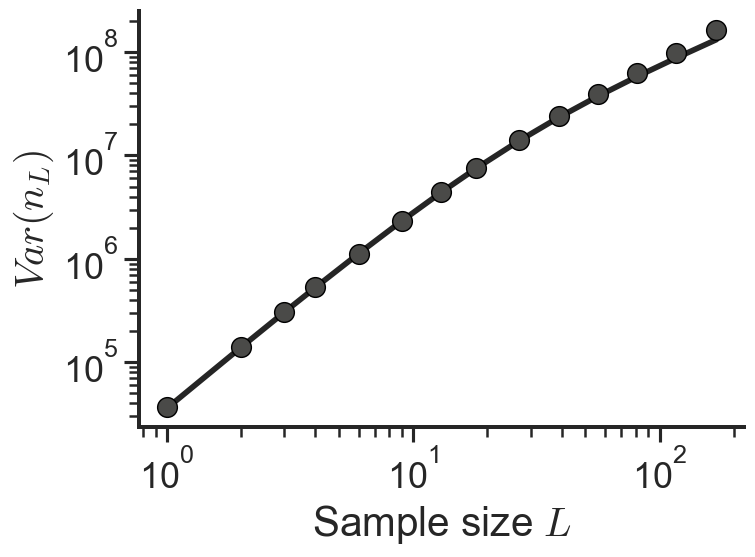

In [29]:
df_taylor = pd.read_csv(FIG_METHODS / "taylor_coordinates.csv")

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.plot(
    df_taylor["Size_L"],
    df_taylor["Taylor_Theoretical_Y"],
    color="#252525",
    lw=3.4,
    zorder=2,
    label="Theory"
)

ax.scatter(
    df_taylor["Size_L"],
    df_taylor["Taylor_Empirical_Y"],
    s=140,
    marker="o",
    color="#4a4a48",
    alpha=1.0,
    edgecolors="black",
    linewidths=0.85,
    zorder=5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Sample size $L$")
ax.set_ylabel(r"$Var(n_L)$")

sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig5_panelC", folder=FIGURE_DIR, transparent=True)

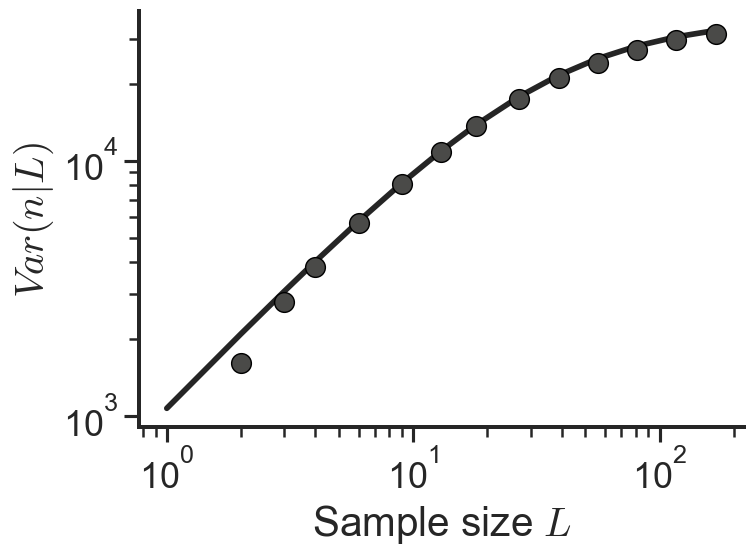

In [32]:
df_patch = pd.read_csv(FIG_METHODS / "patchiness_coordinates.csv")

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.plot(
    df_patch["Size_L"],
    df_patch["Patchiness_Theoretical_Y"],
    color="#252525",
    lw=3.4,
    zorder=2,
    label="Theory"
)

ax.scatter(
    df_patch["Size_L"],
    df_patch["Patchiness_Empirical_Y"],
    s=140,
    marker="o",
    color="#4a4a48",
    alpha=1.0,
    edgecolors="black",
    linewidths=0.85,
    zorder=5,
    label="Simulations"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Sample size $L$")
ax.set_ylabel(r"$Var(n | L)$")

sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig5_panelD", folder=FIGURE_DIR, transparent=True)

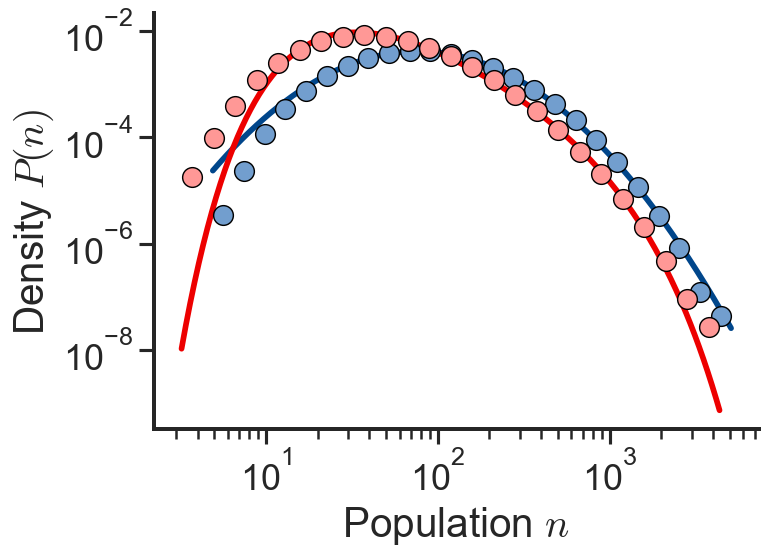

In [21]:

df_log = pd.read_csv(FIG_METHODS / "dist_log_coordinates.csv")
df_gig = pd.read_csv(FIG_METHODS / "dist_gig_coordinates.csv")

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.plot(
    df_log["Theoretical_X"].dropna(),
    df_log["Theoretical_Y_Lognorm"].dropna(),
    color="#00468B",
    lw=3.4,
    zorder=3,
    label="Analytic Lognormal"
)

ax.plot(
    df_gig["Theoretical_X"].dropna(),
    df_gig["Theoretical_Y_GIG"].dropna(),
    color="#ED0000",
    lw=3.4,
    zorder=4,
    label="Analytic GIG"
)

ax.scatter(
    df_log["Empirical_X"].dropna(),
    df_log["Empirical_Y"].dropna(),
    s=140,
    marker="o",
    color="#729ECE",
    alpha=1.0,
    edgecolors="black",
    linewidths=0.85,
    zorder=5,
    label=r"Simulations ($\lambda \approx 1.15$)"
)

ax.scatter(
    df_gig["Empirical_X"].dropna(),
    df_gig["Empirical_Y"].dropna(),
    s=140,
    marker="o",
    color="#FF9896",
    alpha=1.0,
    edgecolors="black",
    linewidths=0.85,
    zorder=6,
    label=r"Simulations ($\lambda \approx 1.84$)"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Population $n$")
ax.set_ylabel(r"Density $P(n)$")

sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig5_panelE", folder=FIGURE_DIR, transparent=True)

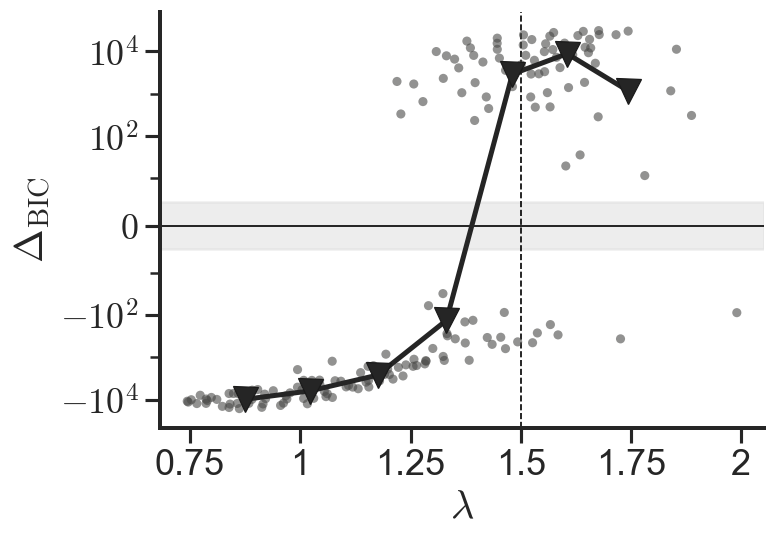

In [44]:
df = pd.read_pickle(FIG_METHODS/ "analysis_results.pkl")

mask_bic = df["lambda_fit"].notna() & df["delta_bic"].notna()
data = df.loc[mask_bic].copy()

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    data["lambda_fit"],
    data["delta_bic"],
    s=30,
    marker="o",
    color="#4a4a48",
    alpha=0.6,
    edgecolors="none",
    linewidths=0,
    rasterized=True,
    zorder=5,
)

ax.axhspan(-5, 5, color="0.85", alpha=0.45, zorder=0)
ax.axhline(0, color="black", lw=1.0, alpha=1.0, zorder=2)
ax.axvline(1.5, color="black", lw=1.0, ls="--", alpha=1.0, zorder=2)

data["Lambda_bin"] = pd.cut(data["lambda_fit"], bins=np.linspace(0.8, 2.9, 15), include_lowest=True)
binned_trend = (
    data.groupby("Lambda_bin", observed=True)
    .agg(lambda_fit=("lambda_fit", "median"), delta_bic=("delta_bic", "median"), n=("delta_bic", "size"))
    .query("n >= 4")
)

ax.plot(
    binned_trend["lambda_fit"],
    binned_trend["delta_bic"],
    color="#252525",
    lw=3.0,
    marker="v",
    ms=15,
    mfc="#252525",
    mec="k",
    mew=0.75,
    zorder=7,
)

ax.set_yscale("symlog", linthresh=10)

ax.set_xticks([0.75, 1, 1.25, 1.5, 1.75, 2])
ax.set_yticks([-10**4, -10**2, 0, 10**2, 10**4])

def sci_notation_fmt(x, pos):
    if x == 0:
        return "$0$"
    sign = "-" if x < 0 else ""
    exponent = int(np.log10(abs(x)))
    return rf"${sign}10^{{{exponent}}}$"

ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(sci_notation_fmt)) # <-- Modifica qui

ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\Delta_{\mathrm{BIC}}$")

sns.despine(ax=ax)

saved_paths = save_figure(fig, "fig5_panelF", folder=FIGURE_DIR, transparent=True)

Theroretical expression for Gamma

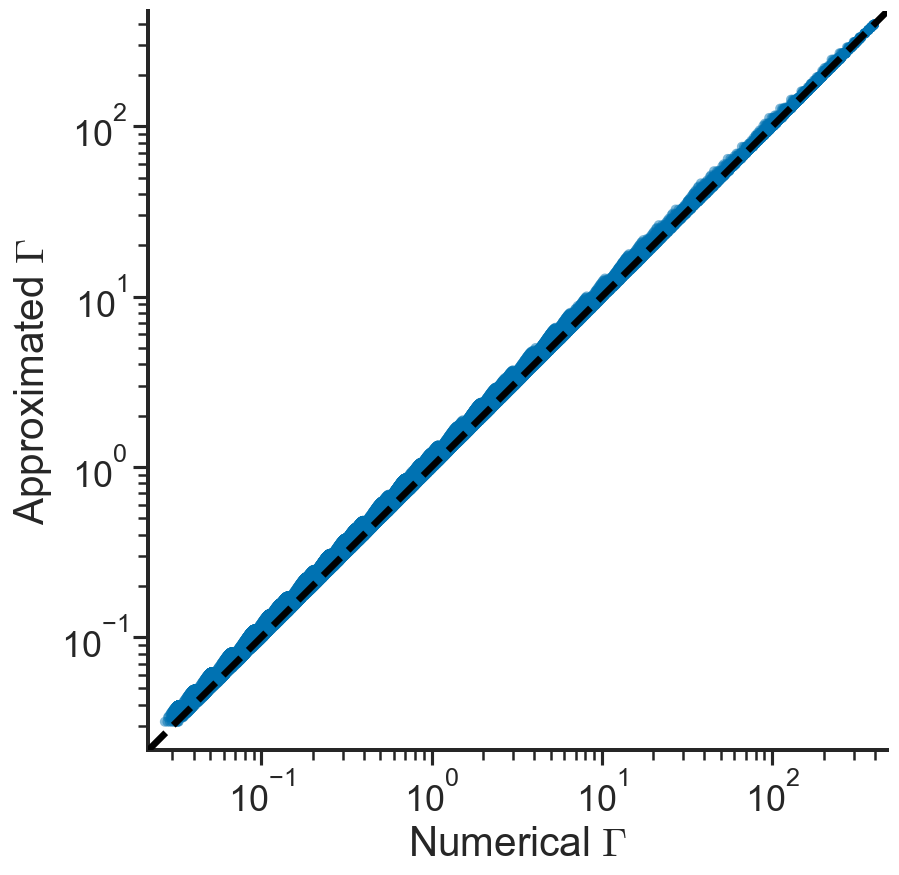

In [24]:
df = pd.read_csv(FIG_METHODS / "points.CSV", header=None, names=["Numerical_Gamma", "Approximated_Gamma"])

x_val = df.iloc[:, 0]
y_val = df.iloc[:, 1]


fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(x_val, y_val, color="#0072B2", alpha=0.5, s=35, edgecolor="none")

ax.set_xscale("log")
ax.set_yscale("log")

lim_min = min(x_val.min(), y_val.min()) * 0.8
lim_max = max(x_val.max(), y_val.max()) * 1.2

ax.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", zorder=3)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Numerical $\Gamma$")
ax.set_ylabel(r"Approximated $\Gamma$")

save_figure(fig, "gamma_comparison_scatter", folder=FIGURE_DIR)

plt.show()

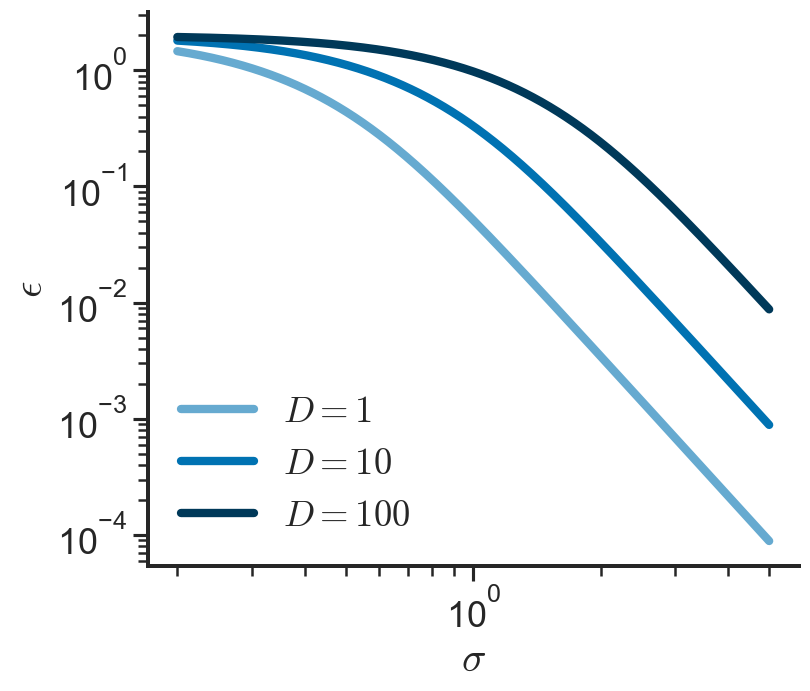

In [7]:
c_val = 10**5
beta_val = 0.3
d_vals = [1.0, 10.0, 100.0]


col_shades = ["#66AAD0", "#0072B2", "#003959"]

def g_app(d, beta, c, sigma):
    return (-np.sqrt(c) * sigma**2 + np.sqrt(128 * np.sqrt(c) * d * np.sqrt(beta) + c * sigma**4)) / (16 * np.sqrt(beta))

def g_const(d, sigma):
    return 4.0 * d / (sigma**2)

sigma_vals = np.logspace(np.log10(0.2), np.log10(5.0), 1000)

fig, ax = plt.subplots(figsize=(7, 6))

for d, color in zip(d_vals, col_shades):
    g_val = g_app(d, beta_val, c_val, sigma_vals)
    const_val = g_const(d, sigma_vals)
    
    epsilon = np.abs(g_val - const_val) * 2.0 / (g_val + const_val)
    
    ax.plot(sigma_vals, epsilon, color=color, lw=5.0, label=f"$D = {int(d)}$")

ax.set_xscale("log")
ax.set_yscale("log") 

ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\epsilon$")

ax.legend(frameon=False, fontsize=22)
save_figure(fig, "gapp_loglinear_plot", folder=FIGURE_DIR)

plt.show()